
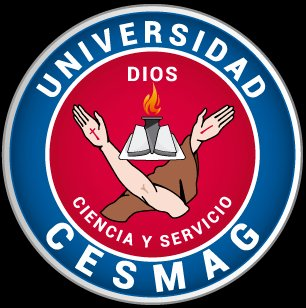

In [5]:
#@title  Notebook 01 — Modelos Tradicionales ECG
#@markdown (portada — no modificar)
from IPython.display import display, HTML
display(HTML("""
  <!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<style>
  @import url('https://fonts.googleapis.com/css2?family=Crimson+Pro:ital,wght@0,300;0,400;0,600;1,300&family=JetBrains+Mono:wght@400;600&family=Barlow+Condensed:wght@300;400;700;900&display=swap');

  :root {
    --azul-cesmag: #003b7a;
    --rojo-cesmag: #c0002a;
    --dorado: #c9a84c;
    --crema: #f7f4ee;
    --gris-oscuro: #1a1a2e;
    --gris-medio: #4a4a6a;
    --blanco: #ffffff;
    --verde-ok: #2d9c5a;
    --pulso: #e8325a;
  }

  * { margin: 0; padding: 0; box-sizing: border-box; }

  body {
    font-family: 'Barlow Condensed', sans-serif;
    background: transparent;
  }

  .wrapper {
    width: 100%;
    background: var(--gris-oscuro);
    border-radius: 16px;
    overflow: hidden;
    position: relative;
    box-shadow: 0 24px 80px rgba(0,0,0,0.5);
  }

  /* ── ECG animado de fondo ── */
  .ecg-bg {
    position: absolute;
    top: 0; left: 0; right: 0; bottom: 0;
    opacity: 0.04;
    pointer-events: none;
    overflow: hidden;
  }
  .ecg-bg svg { width: 200%; height: 100%; animation: scrollECG 18s linear infinite; }
  @keyframes scrollECG {
    from { transform: translateX(0); }
    to   { transform: translateX(-50%); }
  }

  /* ── HEADER ── */
  .header {
    background: linear-gradient(135deg, var(--azul-cesmag) 0%, #001f4d 60%, #0a0a2a 100%);
    padding: 36px 48px 28px;
    display: grid;
    grid-template-columns: 110px 1fr;
    gap: 32px;
    align-items: center;
    position: relative;
    border-bottom: 3px solid var(--dorado);
  }

  .header::after {
    content: '';
    position: absolute;
    bottom: -3px; left: 0; right: 0;
    height: 1px;
    background: linear-gradient(90deg, transparent, var(--dorado), transparent);
  }

  .logo-ring {
    width: 110px; height: 110px;
    border-radius: 50%;
    padding: 4px;
    background: conic-gradient(var(--dorado), var(--rojo-cesmag), var(--dorado));
    animation: rotatering 8s linear infinite;
    flex-shrink: 0;
  }
  @keyframes rotatering {
    to { filter: hue-rotate(30deg); }
  }
  .logo-inner {
    width: 100%; height: 100%;
    border-radius: 50%;
    overflow: hidden;
    border: 3px solid var(--gris-oscuro);
  }
  .logo-inner img { width: 100%; height: 100%; object-fit: cover; }

  .header-text {}
  .univ-label {
    font-family: 'Barlow Condensed', sans-serif;
    font-weight: 300;
    font-size: 11px;
    letter-spacing: 4px;
    color: var(--dorado);
    text-transform: uppercase;
    margin-bottom: 4px;
  }
  .univ-name {
    font-family: 'Barlow Condensed', sans-serif;
    font-weight: 900;
    font-size: 28px;
    color: var(--blanco);
    letter-spacing: 1px;
    line-height: 1;
  }
  .dept {
    font-size: 13px;
    font-weight: 400;
    color: rgba(255,255,255,0.6);
    letter-spacing: 2px;
    margin-top: 6px;
  }

  .notebook-badge {
    display: inline-flex;
    align-items: center;
    gap: 8px;
    background: var(--rojo-cesmag);
    color: white;
    font-family: 'JetBrains Mono', monospace;
    font-size: 11px;
    font-weight: 600;
    padding: 5px 14px;
    border-radius: 4px;
    margin-top: 12px;
    letter-spacing: 1px;
  }
  .notebook-badge::before {
    content: '▶';
    font-size: 8px;
  }

  /* ── TÍTULO PRINCIPAL ── */
  .title-section {
    padding: 32px 48px 24px;
    background: #111128;
    position: relative;
  }
  .title-label {
    font-size: 10px;
    letter-spacing: 5px;
    color: var(--pulso);
    text-transform: uppercase;
    margin-bottom: 10px;
    font-weight: 400;
  }
  .main-title {
    font-family: 'Crimson Pro', serif;
    font-size: 34px;
    font-weight: 600;
    color: var(--blanco);
    line-height: 1.25;
    max-width: 820px;
  }
  .main-title em {
    font-style: italic;
    color: var(--dorado);
  }
  .subtitle {
    font-family: 'Barlow Condensed', sans-serif;
    font-size: 14px;
    color: rgba(255,255,255,0.45);
    margin-top: 10px;
    letter-spacing: 1px;
    font-weight: 300;
  }

  /* ── GRID DE STATS ── */
  .stats-band {
    display: grid;
    grid-template-columns: repeat(4, 1fr);
    background: #0c0c22;
    border-top: 1px solid rgba(201,168,76,0.2);
    border-bottom: 1px solid rgba(201,168,76,0.2);
  }
  .stat-box {
    padding: 18px 20px;
    text-align: center;
    border-right: 1px solid rgba(255,255,255,0.06);
    position: relative;
    transition: background 0.3s;
  }
  .stat-box:last-child { border-right: none; }
  .stat-box:hover { background: rgba(201,168,76,0.05); }
  .stat-num {
    font-family: 'JetBrains Mono', monospace;
    font-size: 28px;
    font-weight: 600;
    color: var(--dorado);
    line-height: 1;
  }
  .stat-num span { font-size: 14px; color: rgba(201,168,76,0.6); }
  .stat-desc {
    font-size: 10px;
    letter-spacing: 2px;
    color: rgba(255,255,255,0.4);
    text-transform: uppercase;
    margin-top: 5px;
  }

  /* ── CUERPO PRINCIPAL ── */
  .body-grid {
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 0;
    background: #12122a;
  }

  .section {
    padding: 28px 32px;
    border-right: 1px solid rgba(255,255,255,0.05);
    border-bottom: 1px solid rgba(255,255,255,0.05);
  }
  .section:nth-child(even) { border-right: none; }

  .sec-title {
    font-size: 9px;
    letter-spacing: 4px;
    text-transform: uppercase;
    color: var(--pulso);
    margin-bottom: 14px;
    display: flex;
    align-items: center;
    gap: 8px;
  }
  .sec-title::after {
    content: '';
    flex: 1;
    height: 1px;
    background: rgba(232,50,90,0.3);
  }

  /* Modelos */
  .model-list { display: flex; flex-direction: column; gap: 7px; }
  .model-item {
    display: flex;
    align-items: center;
    gap: 10px;
    padding: 8px 12px;
    background: rgba(255,255,255,0.03);
    border-radius: 6px;
    border-left: 3px solid transparent;
    transition: border-color 0.2s, background 0.2s;
  }
  .model-item:hover { background: rgba(255,255,255,0.07); }
  .model-item.winner { border-left-color: var(--dorado); }
  .model-item.good { border-left-color: var(--verde-ok); }
  .model-item.bad { border-left-color: var(--rojo-cesmag); }
  .model-tag {
    font-family: 'JetBrains Mono', monospace;
    font-size: 11px;
    font-weight: 600;
    color: var(--blanco);
    min-width: 70px;
  }
  .model-score {
    font-family: 'JetBrains Mono', monospace;
    font-size: 11px;
    color: rgba(255,255,255,0.5);
    margin-left: auto;
  }
  .crown { font-size: 10px; }

  /* Pipeline chips */
  .chip-grid { display: flex; flex-wrap: wrap; gap: 6px; }
  .chip {
    font-family: 'JetBrains Mono', monospace;
    font-size: 10px;
    padding: 4px 10px;
    border-radius: 4px;
    background: rgba(0,59,122,0.4);
    border: 1px solid rgba(0,59,122,0.8);
    color: rgba(255,255,255,0.8);
    letter-spacing: 0.5px;
  }
  .chip.highlight {
    background: rgba(201,168,76,0.15);
    border-color: rgba(201,168,76,0.5);
    color: var(--dorado);
  }

  /* Métricas */
  .metric-row {
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 7px 0;
    border-bottom: 1px solid rgba(255,255,255,0.04);
    font-size: 12px;
  }
  .metric-row:last-child { border-bottom: none; }
  .metric-name { color: rgba(255,255,255,0.5); font-weight: 300; letter-spacing: 1px; }
  .metric-val {
    font-family: 'JetBrains Mono', monospace;
    font-size: 11px;
    color: var(--blanco);
    background: rgba(255,255,255,0.06);
    padding: 2px 8px;
    border-radius: 3px;
  }

  /* Archivos */
  .file-list { display: flex; flex-direction: column; gap: 5px; }
  .file-item {
    display: flex;
    align-items: center;
    gap: 8px;
    font-family: 'JetBrains Mono', monospace;
    font-size: 10px;
    color: rgba(255,255,255,0.55);
    padding: 5px 8px;
    border-radius: 4px;
    background: rgba(255,255,255,0.02);
  }
  .file-item .ftype {
    font-size: 8px;
    padding: 1px 5px;
    border-radius: 2px;
    font-weight: 600;
    letter-spacing: 1px;
  }
  .ftype.csv { background: rgba(45,156,90,0.3); color: #5de89e; }
  .ftype.png { background: rgba(201,168,76,0.3); color: var(--dorado); }
  .ftype.json { background: rgba(0,59,122,0.5); color: #5fa8ff; }
  .ftype.joblib { background: rgba(232,50,90,0.3); color: #ff7a9a; }

  /* ── AUTORES ── */
  .authors-bar {
    background: linear-gradient(90deg, #001530, #0a0a2a, #001530);
    padding: 20px 48px;
    display: flex;
    align-items: center;
    justify-content: space-between;
    flex-wrap: wrap;
    gap: 16px;
    border-top: 1px solid rgba(201,168,76,0.2);
  }
  .authors-group { display: flex; flex-direction: column; gap: 6px; }
  .author-label {
    font-size: 8px;
    letter-spacing: 4px;
    text-transform: uppercase;
    color: rgba(255,255,255,0.3);
  }
  .author-names {
    display: flex;
    gap: 20px;
    flex-wrap: wrap;
  }
  .author {
    font-family: 'Crimson Pro', serif;
    font-size: 16px;
    color: var(--blanco);
    font-weight: 400;
    letter-spacing: 0.5px;
  }
  .asesor-block { text-align: right; }
  .asesor-name {
    font-family: 'Crimson Pro', serif;
    font-size: 15px;
    color: var(--dorado);
    font-style: italic;
  }

  /* ── FOOTER ── */
  .footer {
    background: #0a0a18;
    padding: 12px 48px;
    display: flex;
    justify-content: space-between;
    align-items: center;
  }
  .footer-date {
    font-family: 'JetBrains Mono', monospace;
    font-size: 10px;
    color: rgba(255,255,255,0.2);
    letter-spacing: 2px;
  }
  .footer-file {
    font-family: 'JetBrains Mono', monospace;
    font-size: 10px;
    color: rgba(232,50,90,0.5);
    letter-spacing: 1px;
  }

  /* ── ECG pulse line ── */
  .pulse-line {
    width: 100%;
    height: 40px;
    background: #0a0a18;
    position: relative;
    overflow: hidden;
  }
  .pulse-line svg {
    position: absolute;
    top: 0; left: 0;
    width: 200%;
    animation: pulsemove 3s linear infinite;
  }
  @keyframes pulsemove {
    from { transform: translateX(0); }
    to   { transform: translateX(-50%); }
  }
</style>
</head>
<body>
<div class="wrapper">

  <!-- ECG fondo decorativo -->
  <div class="ecg-bg">
    <svg viewBox="0 0 1400 200" preserveAspectRatio="none" xmlns="http://www.w3.org/2000/svg">
      <polyline points="0,100 80,100 100,100 110,20 120,180 130,60 140,140 150,100 230,100 310,100 320,100 330,20 340,180 350,60 360,140 370,100 450,100 530,100 540,100 550,20 560,180 570,60 580,140 590,100 670,100 750,100 760,100 770,20 780,180 790,60 800,140 810,100 890,100 970,100 980,100 990,20 1000,180 1010,60 1020,140 1030,100 1110,100 1190,100 1200,100 1210,20 1220,180 1230,60 1240,140 1250,100 1330,100 1400,100" stroke="white" stroke-width="2" fill="none"/>
    </svg>
  </div>

  <!-- HEADER -->
  <div class="header">
    <div class="logo-ring">
      <div class="logo-inner">
        <img src="..." alt="Logo CESMAG">
      </div>
    </div>
    <div class="header-text">
      <div class="univ-label">Universidad</div>
      <div class="univ-name">CESMAG</div>
      <div class="dept">Ingeniería de Sistemas · Grupo de Investigación</div>
      <div class="notebook-badge">01_tradicionales.ipynb</div>
    </div>
  </div>

  <!-- TÍTULO -->
  <div class="title-section">
    <div class="title-label">Notebook 01 — Modelos Tradicionales</div>
    <div class="main-title">
      Predicción de Señales <em>ECG</em> con<br>Modelos Tradicionales de Machine Learning
    </div>
    <div class="subtitle">MIT-BIH Arrhythmia Database · 48 pacientes · 360 Hz · Derivación MLII</div>
  </div>

  <!-- STATS -->
  <div class="stats-band">
    <div class="stat-box">
      <div class="stat-num">13<span>K+</span></div>
      <div class="stat-desc">Evaluaciones</div>
    </div>
    <div class="stat-box">
      <div class="stat-num">7</div>
      <div class="stat-desc">Modelos</div>
    </div>
    <div class="stat-box">
      <div class="stat-num">7</div>
      <div class="stat-desc">Pipelines</div>
    </div>
    <div class="stat-box">
      <div class="stat-num">2</div>
      <div class="stat-desc">Experimentos</div>
    </div>
  </div>

  <!-- BODY GRID -->
  <div class="body-grid">

    <!-- Experimento A -->
    <div class="section">
      <div class="sec-title">Experimento A · Multi-step Directo</div>
      <div class="model-list">
        <div class="model-item winner">
          <span class="crown">👑</span>
          <span class="model-tag">RF</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Random Forest</span>
          <span class="model-score">R²= 0.160</span>
        </div>
        <div class="model-item good">
          <span class="crown">·</span>
          <span class="model-tag">SVR_rbf</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Kernel RBF</span>
          <span class="model-score">R²= 0.120</span>
        </div>
        <div class="model-item good">
          <span class="crown">·</span>
          <span class="model-tag">MLP</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Perceptrón</span>
          <span class="model-score">R²= 0.088</span>
        </div>
        <div class="model-item bad">
          <span class="crown">·</span>
          <span class="model-tag">DT</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Árbol Dec.</span>
          <span class="model-score">R²=−0.199</span>
        </div>
        <div class="model-item bad">
          <span class="crown">·</span>
          <span class="model-tag">ARIMA</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Clásico</span>
          <span class="model-score">R²=−4.47</span>
        </div>
      </div>
      <div style="margin-top:12px;font-size:10px;color:rgba(255,255,255,0.3);font-family:'JetBrains Mono',monospace;">
        Horizontes: 1s · 3s · 5s &nbsp;|&nbsp; Contexto: 5 s (1 800 muestras)
      </div>
    </div>

    <!-- Experimento B -->
    <div class="section">
      <div class="sec-title">Experimento B · One-beat-ahead</div>
      <div class="model-list">
        <div class="model-item winner">
          <span class="crown">👑</span>
          <span class="model-tag">SVR_rbf</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Kernel RBF</span>
          <span class="model-score">R²= 0.645</span>
        </div>
        <div class="model-item good">
          <span class="crown">·</span>
          <span class="model-tag">RF</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Random Forest</span>
          <span class="model-score">R²= 0.626</span>
        </div>
        <div class="model-item good">
          <span class="crown">·</span>
          <span class="model-tag">MLP</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Perceptrón</span>
          <span class="model-score">R²= 0.583</span>
        </div>
        <div class="model-item good">
          <span class="crown">·</span>
          <span class="model-tag">DT</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Árbol Dec.</span>
          <span class="model-score">R²= 0.452</span>
        </div>
        <div class="model-item bad">
          <span class="crown">⚠</span>
          <span class="model-tag">LinReg</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Colapso num.</span>
          <span class="model-score">R²≈−10⁹</span>
        </div>
      </div>
      <div style="margin-top:12px;font-size:10px;color:rgba(255,255,255,0.3);font-family:'JetBrains Mono',monospace;">
        Lookback: 3 · 5 · 10 latidos &nbsp;|&nbsp; Target: 256 muestras/latido
      </div>
    </div>

    <!-- Pipelines de preprocesamiento -->
    <div class="section">
      <div class="sec-title">Pipelines de Preprocesamiento</div>
      <div class="chip-grid">
        <span class="chip">F_SIN</span>
        <span class="chip">F_N</span>
        <span class="chip">F_PB</span>
        <span class="chip">F_N+PB</span>
        <span class="chip highlight">F_MED ★</span>
        <span class="chip highlight">F_N+MED ★</span>
        <span class="chip highlight">F_N+PB+MED ★</span>
      </div>
      <div style="margin-top:14px;">
        <div class="metric-row">
          <span class="metric-name">Mejor filtro (Exp A)</span>
          <span class="metric-val">F_N+MED</span>
        </div>
        <div class="metric-row">
          <span class="metric-name">Mejor filtro (Exp B)</span>
          <span class="metric-val">F_N+MED</span>
        </div>
        <div class="metric-row">
          <span class="metric-name">R² óptimo global</span>
          <span class="metric-val">0.666 (B, LB=3)</span>
        </div>
        <div class="metric-row">
          <span class="metric-name">Partición temporal</span>
          <span class="metric-val">80% train / 20% test</span>
        </div>
      </div>
    </div>

    <!-- Archivos generados -->
    <div class="section">
      <div class="sec-title">Archivos Generados</div>
      <div class="file-list">
        <div class="file-item"><span class="ftype csv">CSV</span>resultados_A.csv · resultados_B.csv</div>
        <div class="file-item"><span class="ftype csv">CSV</span>resumen_ExpA.csv · resumen_ExpB.csv</div>
        <div class="file-item"><span class="ftype csv">CSV</span>tabla_maestra_A.csv · tabla_maestra_B.csv</div>
        <div class="file-item"><span class="ftype csv">CSV</span>ic95_r2 · wilcoxon · ranking (×5)</div>
        <div class="file-item"><span class="ftype png">PNG</span>10 visualizaciones (boxplots, heatmaps)</div>
        <div class="file-item"><span class="ftype json">JSON</span>config_NB2.json (herencia → NB2)</div>
        <div class="file-item"><span class="ftype joblib">PKL</span>modelos/ (.joblib por configuración)</div>
      </div>
    </div>

  </div>

  <!-- ECG PULSE LINE -->
  <div class="pulse-line">
    <svg viewBox="0 0 1400 40" preserveAspectRatio="none" xmlns="http://www.w3.org/2000/svg">
      <polyline points="0,20 100,20 120,20 130,4 140,36 148,12 156,28 164,20 264,20 364,20 374,20 384,4 394,36 402,12 410,28 418,20 518,20 618,20 628,20 638,4 648,36 656,12 664,28 672,20 772,20 872,20 882,20 892,4 902,36 910,12 918,28 926,20 1026,20 1126,20 1136,20 1146,4 1156,36 1164,12 1172,28 1180,20 1280,20 1400,20"
        stroke="#e8325a" stroke-width="1.5" fill="none" opacity="0.6"/>
    </svg>
  </div>

  <!-- AUTHORS -->
  <div class="authors-bar">
    <div class="authors-group">
      <div class="author-label">Autores</div>
      <div class="author-names">
        <span class="author">Darwin David Burbano Guerrero</span>
        <span style="color:rgba(255,255,255,0.2);align-self:center;">·</span>
        <span class="author">Darío Esteban Gómez Ordóñez</span>
      </div>
    </div>
    <div class="asesor-block">
      <div class="author-label" style="text-align:right;">Asesor</div>
      <div class="asesor-name">Mg. Héctor Andrés Mora Paz</div>
    </div>
  </div>

  <!-- FOOTER -->
  <div class="footer">
    <div class="footer-date">ANÁLISIS: 29 · MAR · 2026</div>
    <div class="footer-file">01_tradicionales.ipynb</div>
  </div>

</div>
</body>
</html>

"""))

---
## BLOQUE 1 — Instalación de dependencias

In [1]:
import subprocess, sys

PAQUETES = [
    'wfdb', 'scipy', 'scikit-learn', 'statsmodels',
    'dtaidistance', 'matplotlib', 'seaborn',
    'pandas', 'numpy', 'psutil', 'joblib',
]
for p in PAQUETES:
    subprocess.run([sys.executable, '-m', 'pip', 'install', p, '-q'], check=False)
print('Dependencias listas.')

Dependencias listas.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, json, time, gc
import psutil
import joblib

import wfdb
from scipy import signal as spsig
from scipy.ndimage import median_filter
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA

try:
    from dtaidistance import dtw as dtw_lib
    USE_DTW_LIB = True
except ImportError:
    USE_DTW_LIB = False

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

---
## BLOQUE 2 — Configuración global

In [ ]:
# ── Reproducibilidad ─────────────────────────────────────────────
SEED       = 42
PROP_TRAIN = 0.80
np.random.seed(SEED)

# ── Parámetros MIT-BIH ──────────────────────────────────────────
FS          = 360
NYQUIST     = FS / 2
F_BAJO      = 0.5
F_ALTO      = 40.0
ORDEN_BUT   = 4
FREC_NOTCH  = 60.0
Q_NOTCH     = 30.0

# ── 48 Pacientes MIT-BIH ────────────────────────────────────────
PACIENTES = [
    '100','101','102','103','104','105','106','107','108','109',
    '111','112','113','114','115','116','117','118','119',
    '121','122','123','124',
    '200','201','202','203','205','207','208','209','210',
    '212','213','214','215','217','219','220','221','222',
    '223','228','230','231','232','233','234',
]

# ── Exp A: Forecasting multi-step directo Seq-to-Seq ────────────
#  Entrada fija: L = 5 s (1800 muestras de historia)
#  Salida: horizonte H = 1, 3, 5 s de predicción simultánea
VENTANA_L       = 5
VENTANA_L_MUES  = VENTANA_L * FS                       # 1800 muestras
HORIZONTES_SEG  = [1, 3, 5]
HORIZONTES_MUES = [h * FS for h in HORIZONTES_SEG]     # [360, 1080, 1800]
SOLAPAMIENTO    = 0.50

# ── Latidos (Exp B) ─────────────────────────────────────────────
BEAT_LEN       = 256
LOOKBACKS_BEAT = [3, 5, 10]
BEAT_TYPES     = set('NLRBVAFaJfEjeSe/')

# ── Filtros a evaluar (7 de 13) ──────────────────────────────────
FILTROS_EXP = [
    'F_SIN',       # Señal cruda — control
    'F_N',         # Solo Notch 60 Hz
    'F_PB',        # Pasa-banda 0.5–40 Hz
    'F_MED',       # Solo mediana
    'F_N+PB',      # Notch + Pasa-banda
    'F_N+MED',     # Notch + Mediana
    'F_N+PB+MED',  # Pipeline completo 3 etapas
]


MAX_RAM_PCT = 85

# ── Guardado del GANADOR ───────────────────────────────────

GUARDAR_MODELOS = True

# Trackers globales — se actualizan DURANTE el entrenamiento.
# Al terminar cada experimento se guarda SOLO el mejor.
mejor_global_A = {'r2': -np.inf, 'modelo': None, 'nom': '', 'config': {}}
mejor_global_B = {'r2': -np.inf, 'modelo': None, 'nom': '', 'config': {}}

# ── Rutas — compatibles con Colab y local ─────────────────────────
def _detectar_entorno():
    """Detecta entorno (colab/local) y resuelve la raíz del proyecto."""
    try:
        import google.colab
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        _drive = '/content/drive/MyDrive'
        for nombre in ['FORECASTING-ECG', 'FORECASTING ECG']:
            ruta = os.path.join(_drive, nombre)
            if os.path.isdir(ruta):
                return 'colab', ruta
        return 'colab', os.path.join(_drive, 'FORECASTING-ECG')
    except ImportError:
        ruta = os.getcwd()
        for _ in range(5):
            if os.path.isdir(os.path.join(ruta, 'data')) or \
               os.path.isdir(os.path.join(ruta, 'datos')):
                return 'local', ruta
            ruta = os.path.dirname(ruta)
        return 'local', os.getcwd()

ENTORNO, _BASE = _detectar_entorno()

def _resolver_ruta(base, opciones):
    """Prueba varias rutas y devuelve la primera que existe."""
    for partes in opciones:
        r = os.path.join(base, *partes)
        if os.path.isdir(r):
            return r
    return os.path.join(base, *opciones[0])

RUTA_DATOS   = _resolver_ruta(_BASE, [('data', 'mit-bih'), ('datos', 'mit-bih')])
RUTA_RESULTS = _resolver_ruta(_BASE, [('results', 'NB1'),
                                       ('resultados', 'exp2', 'NB1 v5 exp'),
                                       ('resultados', 'exp2', 'NB1')])
RUTA_MODELS  = os.path.join(RUTA_RESULTS, 'modelos')

for d in [RUTA_DATOS, RUTA_RESULTS, RUTA_MODELS]:
    os.makedirs(d, exist_ok=True)

def _buscar_checkpoint(nombre_nuevo, nombre_viejo=None):
    """Busca checkpoint con nombre nuevo; si no existe, prueba nombre viejo."""
    ruta_nueva = os.path.join(RUTA_RESULTS, nombre_nuevo)
    if os.path.exists(ruta_nueva):
        return ruta_nueva
    if nombre_viejo:
        ruta_vieja = os.path.join(RUTA_RESULTS, nombre_viejo)
        if os.path.exists(ruta_vieja):
            print(f'  [Migración] Usando checkpoint legacy: {nombre_viejo}')
            return ruta_vieja
    return ruta_nueva

ram = psutil.virtual_memory()
print('=' * 65)
print('  EXP1 — NB1 Modelos Tradicionales (Multi-step Directo)')
print('  6 modelos: LinReg · DT · RF · SVR_rbf · MLP · ARIMA')
print('  Guardado: UN ganador por experimento (no masivo)')
print('=' * 65)
print(f'  Entorno      : {ENTORNO}')
print(f'  SEED         : {SEED}  |  Split: {int(PROP_TRAIN*100)}/{int((1-PROP_TRAIN)*100)} temporal')
print(f'  Pacientes    : {len(PACIENTES)}')
print(f'  Raíz proyecto: {_BASE}')
print(f'  Ruta resultados: {RUTA_RESULTS}')
print(f'  Ruta modelos   : {RUTA_MODELS}')
print(f'  Entrada Exp A : L={VENTANA_L}s ({VENTANA_L_MUES} mues) → H={HORIZONTES_SEG}s')
print(f'  Lookback Exp B: {LOOKBACKS_BEAT} latidos (BEAT_LEN={BEAT_LEN})')
print(f'  RAM disp.    : {ram.available/1e9:.1f} GB / {ram.total/1e9:.1f} GB')
print(f'  Alerta RAM   : >{MAX_RAM_PCT}% → gc forzado')
print(f'  Guardado     : 1 ganador Exp A + 1 ganador Exp B (LZMA-3)')
print('=' * 65)


Mounted at /content/drive
  EXP1 — NB1 Modelos Tradicionales (Multi-step Directo)
  6 modelos: LinReg · DT · RF · SVR_rbf · MLP · ARIMA
  Guardado: UN ganador por experimento (no masivo)
  Entorno      : colab
  SEED         : 42  |  Split: 80/19 temporal
  Pacientes    : 48
  Raíz proyecto: /content/drive/MyDrive/FORECASTING ECG
  Ruta resultados: /content/drive/MyDrive/FORECASTING ECG/results/NB1
  Ruta modelos   : /content/drive/MyDrive/FORECASTING ECG/results/NB1/modelos
  Entrada Exp A : L=5s (1800 mues) → H=[1, 3, 5]s
  Lookback Exp B: [3, 5, 10] latidos (BEAT_LEN=256)
  RAM disp.    : 11.9 GB / 13.6 GB
  Alerta RAM   : >85% → gc forzado
  Guardado     : 1 ganador Exp A + 1 ganador Exp B (LZMA-3)


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  ANTI-DESCONEXION COLAB
# ══════════════════════════════════════════════════════════════════
if ENTORNO == 'colab':
    import IPython
    IPython.display.display(IPython.display.Javascript('''
        function keepAlive() {
            var sels = ["colab-connect-button",
                        "#top-toolbar > colab-connect-button",
                        "#connect"];
            for (var i = 0; i < sels.length; i++) {
                var btn = document.querySelector(sels[i]);
                if (btn) { btn.click(); break; }
            }
            console.log("Keep-alive ping: " + new Date().toLocaleTimeString());
        }
        setInterval(keepAlive, 120000);
        console.log("[OK] Anti-desconexion activo — ping cada 2 min.");
    '''))
    print('Anti-desconexion Colab activado (keep-alive cada 2 min).')
    print('Tip: NO minimices la pestana del navegador para evitar throttling de JS.')
else:
    print('Entorno local — anti-desconexion no necesario.')

<IPython.core.display.Javascript object>

Anti-desconexion Colab activado (keep-alive cada 2 min).
Tip: NO minimices la pestana del navegador para evitar throttling de JS.


---
## BLOQUE 3 — Carga de datos MIT-BIH

In [5]:
def _descargar_si_falta(pid):
    exts = ['.dat', '.hea', '.atr']
    faltantes = [e for e in exts
                 if not os.path.exists(os.path.join(RUTA_DATOS, pid + e))]
    if not faltantes:
        return
    try:
        wfdb.dl_files('mitdb', RUTA_DATOS, [pid + e for e in faltantes])
    except Exception:
        base = 'https://physionet.org/files/mitdb/1.0.0'
        for ext in faltantes:
            os.system(f'wget -q -nc -P "{RUTA_DATOS}" {base}/{pid}{ext}')


def cargar_ecg(pid):
    """Carga señal ECG canal MLII y anotaciones."""
    _descargar_si_falta(pid)
    ruta = os.path.join(RUTA_DATOS, pid)
    try:
        rec = wfdb.rdrecord(ruta)
        ann = wfdb.rdann(ruta, 'atr')
        s   = rec.p_signal[:, 0].astype(np.float64)
        return s, ann
    except Exception as e:
        print(f'  ERROR [{pid}]: {e}')
        return None, None


REGISTROS_OK = []
print('Verificando 48 registros MIT-BIH...')
for pid in PACIENTES:
    s, _ = cargar_ecg(pid)
    if s is not None:
        REGISTROS_OK.append(pid)
    del s; gc.collect()
print(f'{len(REGISTROS_OK)}/{len(PACIENTES)} registros disponibles.')

Verificando 48 registros MIT-BIH...
48/48 registros disponibles.


---
## BLOQUE 4 — Visualización de señal ECG con división Train/Test

**Corrección asesor:** Mostrar claramente qué parte de la señal se usa para entrenamiento y cuál para test.

In [ ]:
# Visualización de la señal ECG completa de un paciente
# mostrando la región de TRAIN vs TEST

def visualizar_train_test(pid, filtro_nombre='F_SIN'):
    """Visualiza la señal ECG de un paciente con las regiones train/test marcadas."""
    s, ann = cargar_ecg(pid)
    if s is None:
        print(f'No se pudo cargar paciente {pid}')
        return

    sf = aplica(s, FILTROS[filtro_nombre])
    n_total = len(sf)
    n_train = int(n_total * PROP_TRAIN)
    t = np.arange(n_total) / FS
    t_split = n_train / FS

    fig, axes = plt.subplots(3, 1, figsize=(18, 12))
    fig.suptitle(f'Paciente {pid} — Señal ECG MLII ({filtro_nombre}) — División Train/Test',
                 fontsize=14, fontweight='bold')

    # Panel 1: Señal completa con regiones
    ax = axes[0]
    ax.plot(t[:n_train], sf[:n_train], color='#1565C0', lw=0.3, alpha=0.8, label='Train (80%)')
    ax.plot(t[n_train:], sf[n_train:], color='#C62828', lw=0.3, alpha=0.8, label='Test (20%)')
    ax.axvline(t_split, color='black', ls='--', lw=2, label=f'Split t={t_split:.1f}s')
    ax.set_title('Señal completa con división temporal', fontweight='bold')
    ax.set_xlabel('Tiempo (s)'); ax.set_ylabel('Amplitud (mV)')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

    # Panel 2: Zoom en la frontera train/test (±10s)
    ax = axes[1]
    margen = 10 * FS
    i0 = max(0, n_train - margen)
    i1 = min(n_total, n_train + margen)
    t_z = np.arange(i0, i1) / FS
    ax.fill_between(t_z[t_z < t_split], sf[i0:n_train][:len(t_z[t_z < t_split])],
                    alpha=0.15, color='#1565C0')
    ax.fill_between(t_z[t_z >= t_split], sf[n_train:i1][:len(t_z[t_z >= t_split])],
                    alpha=0.15, color='#C62828')
    ax.plot(t_z, sf[i0:i1], color='#333333', lw=0.6)
    ax.axvline(t_split, color='black', ls='--', lw=2)
    ax.set_title(f'Zoom frontera Train/Test (±10s alrededor de t={t_split:.1f}s)', fontweight='bold')
    ax.set_xlabel('Tiempo (s)'); ax.set_ylabel('Amplitud (mV)')
    ax.grid(True, alpha=0.3)

    # Panel 3: Detalle de 5s en cada zona
    ax = axes[2]
    seg_train = sf[5*FS : 10*FS]
    seg_test  = sf[n_train + 5*FS : n_train + 10*FS]
    t_seg = np.arange(len(seg_train)) / FS
    ax.plot(t_seg, seg_train, color='#1565C0', lw=1.0, label='Train (5-10s)')
    if len(seg_test) > 0:
        t_segT = np.arange(len(seg_test)) / FS
        ax.plot(t_segT + 6, seg_test, color='#C62828', lw=1.0, label='Test (primeros 5s)')
    ax.set_title('Detalle: 5s de señal en Train vs 5s en Test', fontweight='bold')
    ax.set_xlabel('Tiempo (s)'); ax.set_ylabel('Amplitud (mV)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(RUTA_RESULTS, f'ecg_train_test_{pid}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    # Info del split
    dur_train = n_train / FS / 60
    dur_test  = (n_total - n_train) / FS / 60
    print(f'\nPaciente {pid}:')
    print(f'  Total muestras: {n_total:,} ({n_total/FS/60:.1f} min)')
    print(f'  Train: {n_train:,} muestras ({dur_train:.1f} min = {PROP_TRAIN*100:.0f}%)')
    print(f'  Test:  {n_total-n_train:,} muestras ({dur_test:.1f} min = {(1-PROP_TRAIN)*100:.0f}%)')
    del s, sf; gc.collect()



In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## BLOQUE 5 — Filtros ECG (Pipeline A)

In [8]:
def f_sin(s):     return s.copy()

def f_notch(s):
    b, a = spsig.iirnotch(FREC_NOTCH, Q_NOTCH, FS)
    return spsig.filtfilt(b, a, s)

def f_butter_bp(s):
    b, a = spsig.butter(ORDEN_BUT, [F_BAJO/NYQUIST, F_ALTO/NYQUIST], btype='band')
    return spsig.filtfilt(b, a, s)

def f_mediana(s):
    k = FS // 10
    k = k if k % 2 == 1 else k + 1
    return median_filter(s, size=k)

def f_fir_bp(s):
    b = spsig.firwin(101, [F_BAJO/NYQUIST, F_ALTO/NYQUIST],
                     pass_zero=False, window='hamming')
    return spsig.filtfilt(b, [1.0], s)

def f_hp(s):
    b, a = spsig.butter(ORDEN_BUT, F_BAJO/NYQUIST, btype='high')
    return spsig.filtfilt(b, a, s)

def aplica(senal, fns):
    s = senal.copy()
    for fn in fns: s = fn(s)
    return s

FILTROS = {
    'F_SIN'       : [f_sin],
    'F_N'         : [f_notch],
    'F_PB'        : [f_butter_bp],
    'F_MED'       : [f_mediana],
    'F_FIR'       : [f_fir_bp],
    'F_PA'        : [f_hp],
    'F_N+PB'      : [f_notch, f_butter_bp],
    'F_N+MED'     : [f_notch, f_mediana],
    'F_PB+MED'    : [f_butter_bp, f_mediana],
    'F_FIR+MED'   : [f_fir_bp, f_mediana],
    'F_PA+MED'    : [f_hp, f_mediana],
    'F_N+PB+MED'  : [f_notch, f_butter_bp, f_mediana],
    'F_N+FIR+MED' : [f_notch, f_fir_bp, f_mediana],
}

print(f'{len(FILTROS)} pipelines definidos.')

13 pipelines definidos.


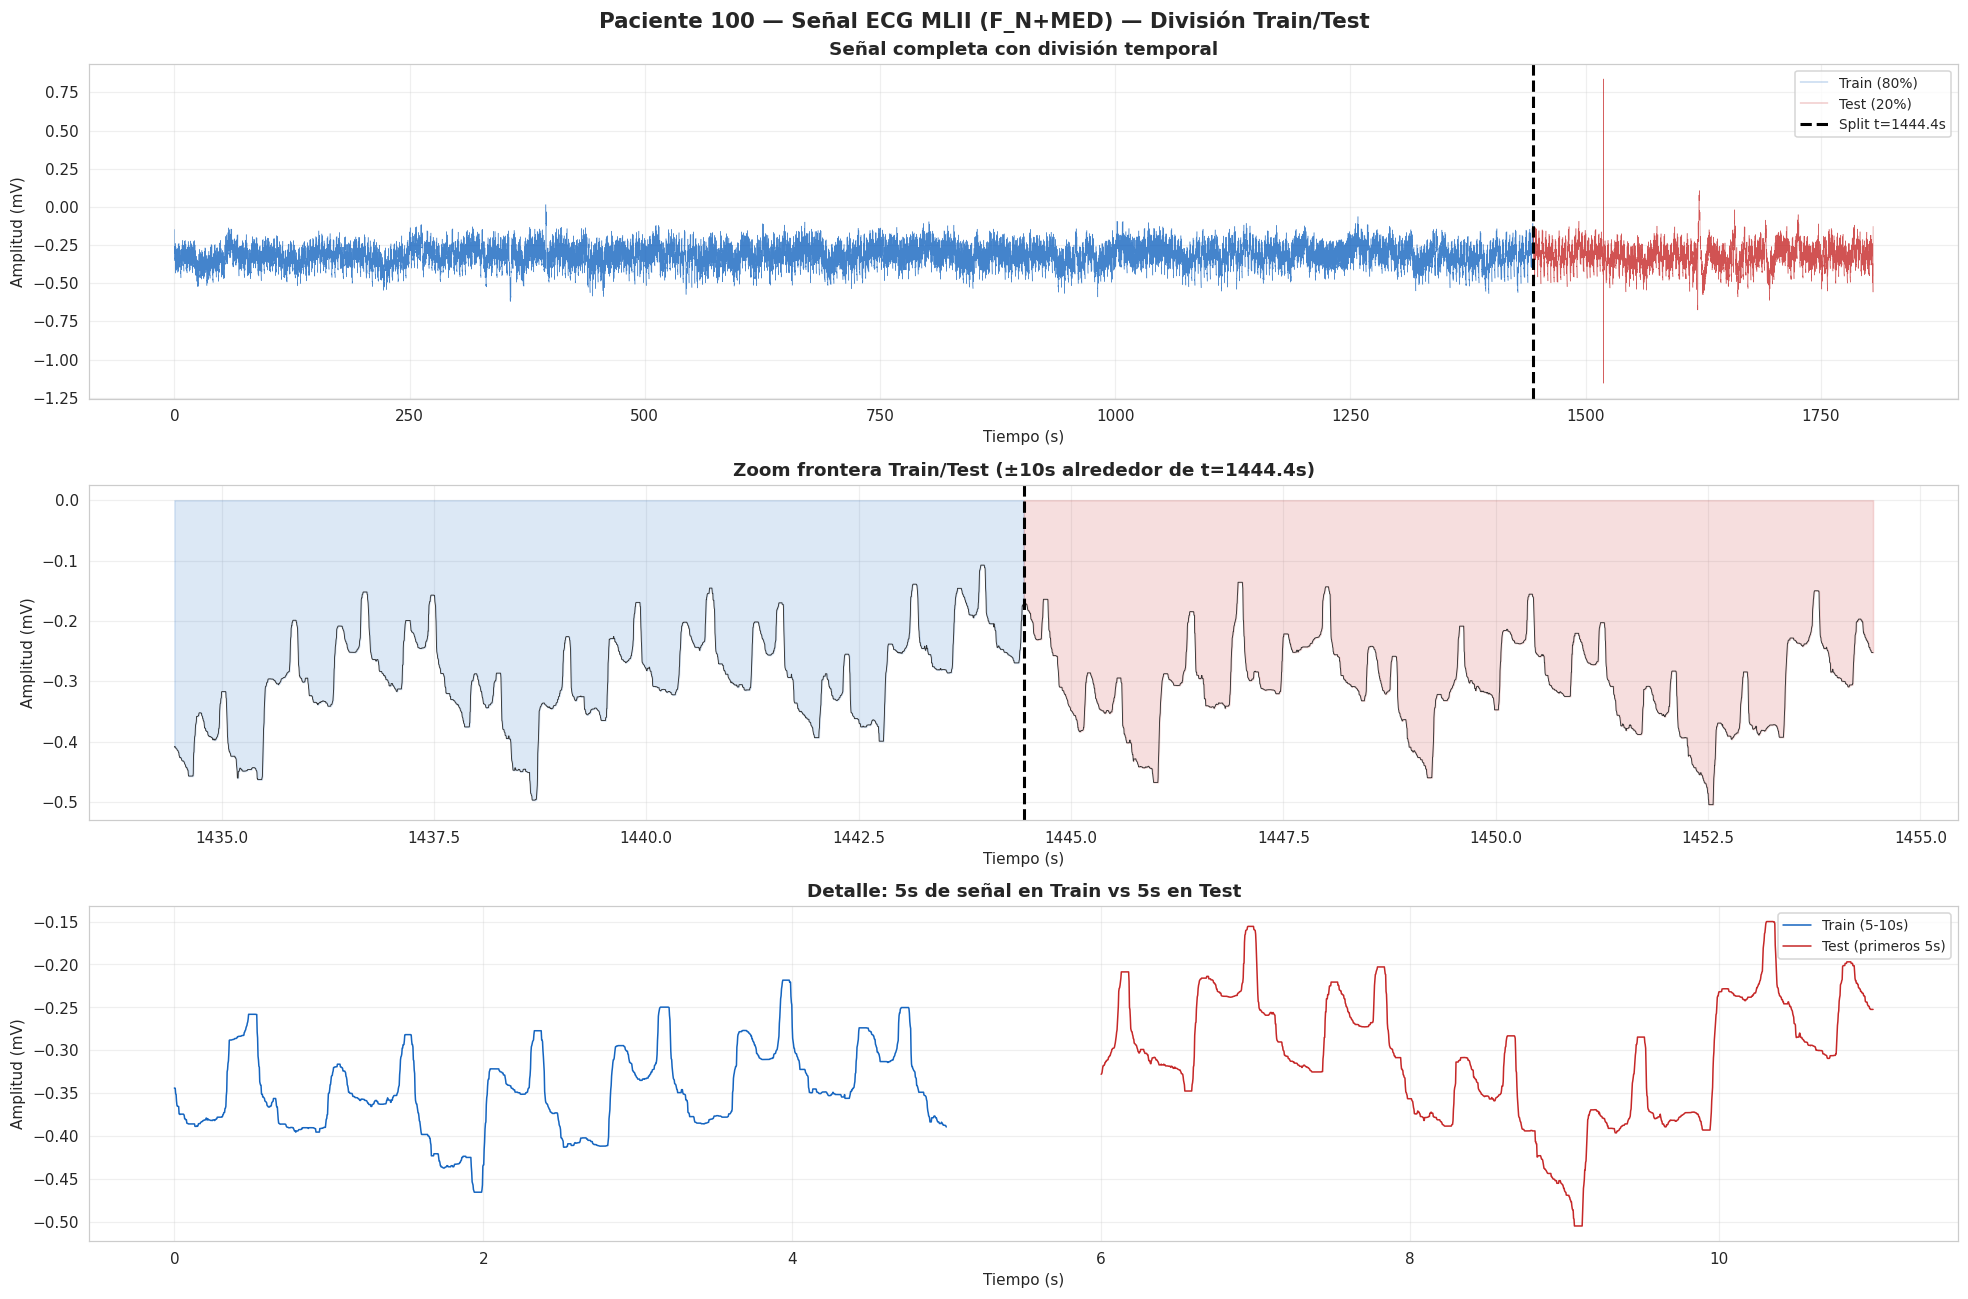


Paciente 100:
  Total muestras: 650,000 (30.1 min)
  Train: 520,000 muestras (24.1 min = 80%)
  Test:  130,000 muestras (6.0 min = 20%)


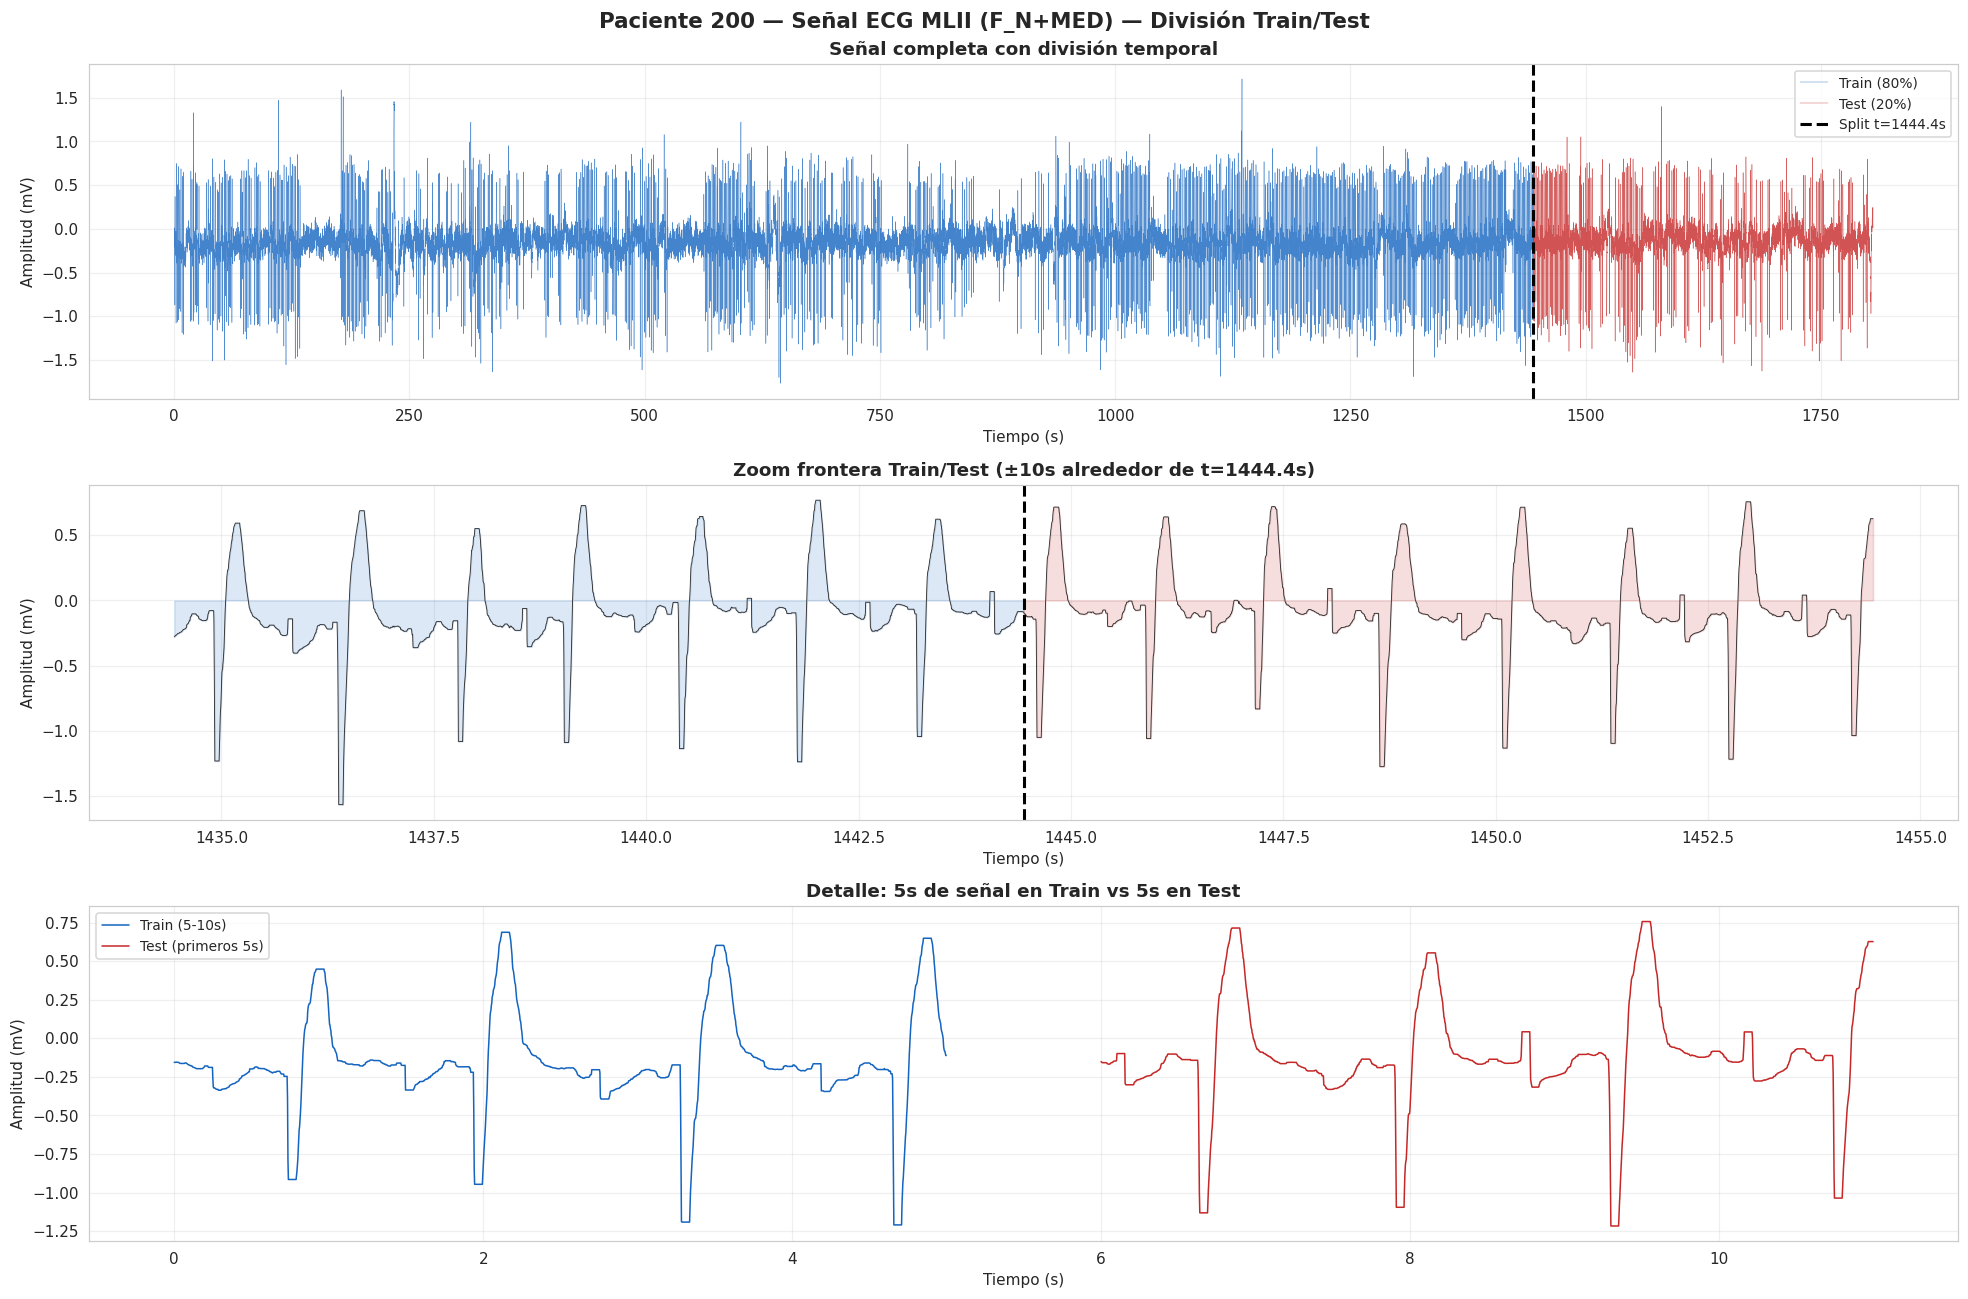


Paciente 200:
  Total muestras: 650,000 (30.1 min)
  Train: 520,000 muestras (24.1 min = 80%)
  Test:  130,000 muestras (6.0 min = 20%)


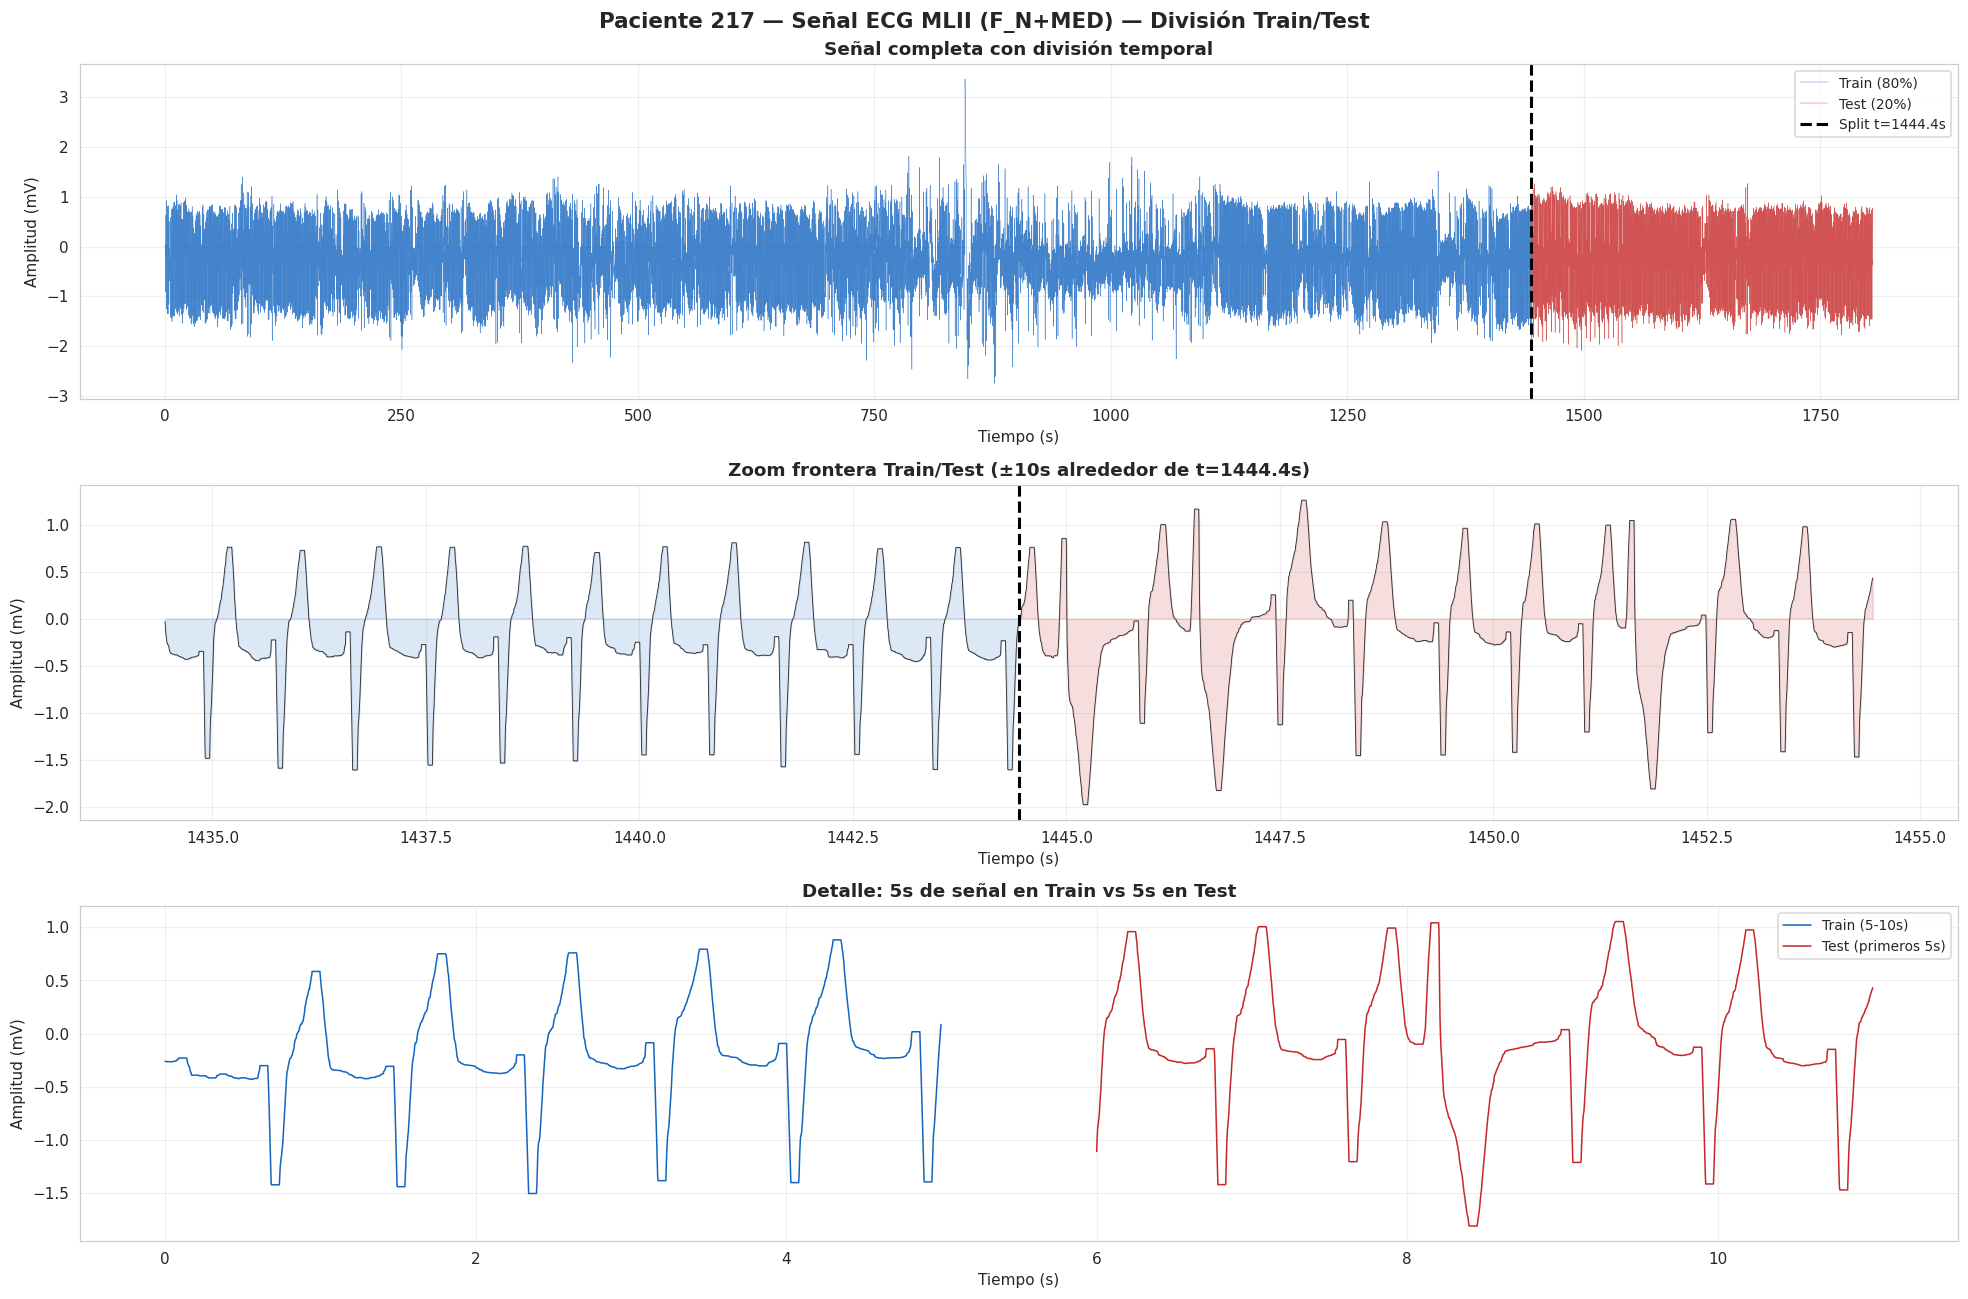


Paciente 217:
  Total muestras: 650,000 (30.1 min)
  Train: 520,000 muestras (24.1 min = 80%)
  Test:  130,000 muestras (6.0 min = 20%)


In [9]:
# Ahora ejecutamos la visualización train/test para 3 pacientes representativos
for pid_vis in ['100', '200', '217']:
    if pid_vis in REGISTROS_OK:
        visualizar_train_test(pid_vis, 'F_N+MED')

---
## BLOQUE 6 — Segmentación, normalización y modelos

### Exp A: Forecasting multi-step directo Seq-to-Seq (CORREGIDO)
-  X = L muestras históricas (5 s) → y = H muestras futuras (1–5 s)
- Formulación: dado un segmento histórico, predecir el segmento futuro completo
- Permite que DTW y MSE tengan interpretación clínica sobre morfología arrítmica
- **7 modelos:** LinReg · DT · RF · SVR_rbf · MLP · ARIMA · Persistencia

### Exp B: Segmentación por latidos (one-beat-ahead)
- X = N latidos anteriores aplanados, y = siguiente latido aplanado
- **6 modelos:** LinReg · DT · RF · SVR_rbf · MLP · Persistencia (ARIMA excluido por complejidad de segmentación)
- Permite comparación justa con los resultados de DL por latidos

### Baselines de referencia
- **Persistencia** actúa como baseline naive en ambos experimentos (Exp A: repite último valor; Exp B: repite último latido)
- **LinReg** es baseline lineal en ambos experimentos
- **ARIMA** es baseline estadístico en Exp A
- Se usa prueba de Wilcoxon para comparar cada modelo vs Persistencia

In [10]:
# ══════════════════════════════════════════════════════════════════
# FUNCIONES DE SEGMENTACIÓN
# ══════════════════════════════════════════════════════════════════

# ── Exp A: Multi-step directo Seq-to-Seq ─────────────────────────
def segmentar_tiempo(senal, tam_w, horizonte, solap=SOLAPAMIENTO):
    """X = ventana de tam_w muestras → y = horizonte muestras futuras."""
    paso = max(1, int(tam_w * (1 - solap)))
    idx  = range(0, len(senal) - tam_w - horizonte, paso)
    if not idx:
        return np.empty((0, tam_w)), np.empty((0, horizonte))
    X = np.array([senal[i : i + tam_w]                     for i in idx])
    y = np.array([senal[i + tam_w : i + tam_w + horizonte] for i in idx])
    return X, y


# ── Exp B: Segmentación por latidos ──────────────────────────────
def extraer_latidos(senal_filtrada, ann, beat_len=BEAT_LEN):
    """Segmenta latidos individuales usando R-peaks."""
    mask   = [s in BEAT_TYPES for s in ann.symbol]
    rpeaks = ann.sample[mask]
    if len(rpeaks) < 10:
        return np.empty((0, beat_len), dtype=np.float64)
    beats = []
    for i in range(1, len(rpeaks) - 1):
        start = (rpeaks[i-1] + rpeaks[i]) // 2
        end   = (rpeaks[i]   + rpeaks[i+1]) // 2
        seg   = senal_filtrada[start:end]
        if len(seg) < 50:
            continue
        beats.append(spsig.resample(seg, beat_len).astype(np.float64))
    if beats:
        return np.array(beats, dtype=np.float64)
    return np.empty((0, beat_len), dtype=np.float64)


def segmentar_latidos(beats, n_lookback):
    """X = N latidos aplanados → y = siguiente latido aplanado."""
    if len(beats) <= n_lookback:
        return np.empty((0, n_lookback * BEAT_LEN)), np.empty((0, BEAT_LEN))
    X = np.array([beats[i:i+n_lookback].flatten()
                  for i in range(len(beats) - n_lookback)])
    y = np.array([beats[i + n_lookback]
                  for i in range(len(beats) - n_lookback)])
    return X, y


# ── Utilidades comunes ────────────────────────────────────────────
def split_temporal(X, y, prop=PROP_TRAIN):
    n = int(len(X) * prop)
    return X[:n], y[:n], X[n:], y[n:]


def zscore(X_tr, X_te):
    mu  = X_tr.mean()
    std = max(X_tr.std(), 1e-8)   # evita división por cero
    return (X_tr - mu) / std, (X_te - mu) / std, mu, std


def zscore_y(y_tr, y_te, mu, std):
    return (y_tr - mu) / std, (y_te - mu) / std


def pca_svr(X_tr, X_te, n=50):
    n_comp = min(n, X_tr.shape[1], X_tr.shape[0] - 1)
    pca    = PCA(n_components=n_comp, random_state=SEED)
    return pca.fit_transform(X_tr), pca.transform(X_te)


print('Funciones de segmentación definidas.')
print(f'  Exp A: segmentar_tiempo(senal, L, H) → X={VENTANA_L}s, y=Horizonte')
print(f'  Exp B: segmentar_latidos(beats, N)   → y=siguiente latido')


Funciones de segmentación definidas.
  Exp A: segmentar_tiempo(senal, L, H) → X=5s, y=Horizonte
  Exp B: segmentar_latidos(beats, N)   → y=siguiente latido


In [11]:
# ══════════════════════════════════════════════════════════════════
# MÉTRICAS — Ahora con R² de TRAIN y TEST
# ══════════════════════════════════════════════════════════════════

def _dtw_manual(a, b):
    n, m = len(a), len(b)
    C = np.full((n+1, m+1), np.inf)
    C[0, 0] = 0.0
    for i in range(1, n+1):
        for j in range(1, m+1):
            C[i,j] = (a[i-1]-b[j-1])**2 + min(C[i-1,j], C[i,j-1], C[i-1,j-1])
    return float(np.sqrt(C[n, m]))


def dtw_score(y_real, y_pred, max_pts=500):
    try:
        yr = y_real.flatten() if y_real.ndim > 1 else y_real
        yp = y_pred.flatten() if y_pred.ndim > 1 else y_pred
        n = min(len(yr), max_pts)
        idx = np.random.default_rng(SEED).choice(len(yr), n, replace=False)
        a = yr[idx].astype(np.float64)
        b = yp[idx].astype(np.float64)
        d = dtw_lib.distance_fast(a, b) if USE_DTW_LIB else _dtw_manual(a, b)
        return round(float(d), 4) if np.isfinite(d) else np.nan
    except Exception:
        return np.nan


def calcular_metricas(y_real, y_pred, lat_ms):
    yr = np.asarray(y_real).flatten()
    yp = np.asarray(y_pred).flatten()
    m  = np.isfinite(yr) & np.isfinite(yp)
    if m.sum() < 5:
        return None
    yr, yp = yr[m], yp[m]
    mse = float(mean_squared_error(yr, yp))
    return {
        'R2'         : round(float(r2_score(yr, yp)), 4),
        'MSE'        : round(mse, 6),
        'RMSE'       : round(float(np.sqrt(mse)), 6),
        'MAE'        : round(float(mean_absolute_error(yr, yp)), 6),
        'DTW'        : dtw_score(yr, yp),
        'Latencia_ms': round(float(lat_ms), 4),
    }


print('Métricas: R² · MSE · RMSE · MAE · DTW · Latencia_ms')

Métricas: R² · MSE · RMSE · MAE · DTW · Latencia_ms


In [12]:

# ══════════════════════════════════════════════════════════════════
# MODELOS TRADICIONALES — 6 modelos + Persistencia (baseline)
# Guardado: 1 modelo por paciente (mejor filtro/horizonte/lookback)
# ══════════════════════════════════════════════════════════════════

def nuevos_modelos():
    return {
        'LinReg'  : LinearRegression(),
        'DT'      : DecisionTreeRegressor(max_depth=8, random_state=SEED),
        'RF'      : RandomForestRegressor(n_estimators=30, max_depth=10,
                                         max_features='sqrt',
                                         min_samples_leaf=2,
                                         random_state=SEED, n_jobs=-1),
        'SVR_rbf' : SVR(kernel='rbf', C=1.0, gamma='scale', epsilon=0.01),
        'MLP'     : MLPRegressor(hidden_layer_sizes=(128, 64),
                                 activation='relu', solver='adam',
                                 max_iter=300, early_stopping=True,
                                 validation_fraction=0.15,
                                 random_state=SEED),
    }


# ── Compresión LZMA nivel 3 (liviano para Drive) ─────────────────
COMPRESION_MODELOS = ('lzma', 3)

def guardar_modelo(modelo, ruta):
    """Guarda modelo sklearn con LZMA en la ruta indicada."""
    if GUARDAR_MODELOS and modelo is not None:
        os.makedirs(os.path.dirname(ruta), exist_ok=True)
        joblib.dump(modelo, ruta, compress=COMPRESION_MODELOS)
        kb = os.path.getsize(ruta) / 1024
        print(f'  [Guardado] {os.path.basename(ruta)}  ({kb:.1f} KB)')


def actualizar_mejor_global(tracker, nom, r2_test, modelo_obj, config_dict):
    """Actualiza el tracker global si r2_test supera el máximo actual."""
    if modelo_obj is None or not np.isfinite(r2_test):
        return
    if r2_test > tracker['r2']:
        tracker['r2']     = r2_test
        tracker['modelo'] = modelo_obj
        tracker['nom']    = nom
        tracker['config'] = config_dict.copy()
        print(f'  [Nuevo ganador global] {nom}  R²={r2_test:+.4f}  config={config_dict}')


# ── Por paciente: 1 mejor modelo por paciente (científicamente válido) ──
# {pid: {'r2': float, 'modelo': obj|None, 'nom': str, 'config': dict}}
mejores_por_paciente_A = {}
mejores_por_paciente_B = {}


def actualizar_mejor_paciente(tracker_dict, pid, nom, r2_test, modelo_obj, config_dict):
    """Actualiza el mejor modelo para el paciente pid basado en R² test."""
    if modelo_obj is None or not np.isfinite(r2_test):
        return
    pid = str(pid)
    if pid not in tracker_dict or r2_test > tracker_dict[pid]['r2']:
        tracker_dict[pid] = {
            'r2'    : r2_test,
            'modelo': modelo_obj,
            'nom'   : nom,
            'config': config_dict.copy(),
        }


def guardar_mejor_paciente(tracker_dict, pid, prefijo, quiet=False):
    """Guarda en disco el mejor modelo de un paciente y su metadata JSON.
    Libera el objeto modelo de memoria tras guardar."""
    pid = str(pid)
    if pid not in tracker_dict or tracker_dict[pid]['modelo'] is None:
        return
    t = tracker_dict[pid]
    ruta_mod  = os.path.join(RUTA_MODELS, f'{prefijo}_pac{pid}_NB1.joblib')
    ruta_meta = os.path.join(RUTA_MODELS, f'{prefijo}_pac{pid}_NB1_metadata.json')
    joblib.dump(t['modelo'], ruta_mod, compress=COMPRESION_MODELOS)
    meta = {
        'paciente'      : pid,
        'modelo'        : t['nom'],
        'r2_test'       : round(float(t['r2']), 6),
        'config'        : t['config'],
        'fecha_guardado': pd.Timestamp.now().isoformat(),
        'notebook'      : 'NB1_01_tradicionales',
    }
    with open(ruta_meta, 'w') as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)
    kb = os.path.getsize(ruta_mod) / 1024
    if not quiet:
        print(f'  [pac{pid}] {t["nom"]}  R²={t["r2"]:+.4f}  ({kb:.1f} KB)')
    # Liberar objeto modelo para no acumular RAM con 48 modelos
    tracker_dict[pid]['modelo'] = None
    gc.collect()


def entrenar_evaluar(nom, modelo, Xtr, ytr, Xte, yte):
    """Entrena y evalúa un modelo sklearn.
    Devuelve dict de métricas incluyendo '_modelo_temp' para el tracker."""
    t0    = time.perf_counter()
    modelo.fit(Xtr, ytr)
    t_fit = time.perf_counter() - t0

    # R² en TRAIN
    yp_train = modelo.predict(Xtr)
    r2_train = round(float(r2_score(ytr.flatten(), yp_train.flatten())), 4)

    # R² en TEST + métricas
    t0  = time.perf_counter()
    yp  = modelo.predict(Xte)
    lat = (time.perf_counter() - t0) / max(len(Xte), 1) * 1000

    met = calcular_metricas(yte, yp, lat)
    if met:
        met['R2_train']     = r2_train
        met['t_fit_s']      = round(t_fit, 3)
        met['_modelo_temp'] = modelo   # referencia para tracker externo

    del yp, yp_train; gc.collect()
    return met


def entrenar_arima(senal_train, senal_test):
    """ARIMA(1,1,1) multi-step: entrena en señal 1D, predice H pasos."""
    H = len(senal_test)
    try:
        t0    = time.perf_counter()
        serie = senal_train[-min(len(senal_train), 2000):].astype(np.float64)
        if np.std(serie) < 1e-8:
            return None
        res = ARIMA(serie, order=(1, 1, 1)).fit(
            method_kwargs={'warn_convergence': False})

        fitted = res.fittedvalues
        r2_tr  = round(float(r2_score(serie[1:len(fitted)+1],
                                      fitted[:len(serie)-1])), 4) \
                 if len(fitted) > 5 else np.nan

        fc    = np.array(res.forecast(steps=H))
        t_tot = time.perf_counter() - t0
        if H < 5:
            return None
        met = calcular_metricas(senal_test[:H], fc[:H], t_tot / max(H, 1) * 1000)
        if met:
            met['R2_train'] = r2_tr
            met['t_fit_s']  = round(t_tot, 3)
        del res, fc; gc.collect()
        return met
    except Exception:
        return None


def persistencia_expA(Xtr_n, ytr_n, Xte_n, yte_n):
    """Persistencia Exp A: predice el último valor de X como constante en todo el horizonte."""
    t0 = time.perf_counter()
    yp_tr = np.tile(Xtr_n[:, -1:], (1, ytr_n.shape[1]))
    r2_tr = round(float(r2_score(ytr_n.flatten(), yp_tr.flatten())), 4)
    yp_te = np.tile(Xte_n[:, -1:], (1, yte_n.shape[1]))
    lat   = (time.perf_counter() - t0) / max(len(Xte_n), 1) * 1000
    met   = calcular_metricas(yte_n, yp_te, lat)
    if met:
        met['R2_train'] = r2_tr
        met['t_fit_s']  = 0.0
    return met


def persistencia_expB(Xtr_n, ytr_n, Xte_n, yte_n, beat_len=BEAT_LEN):
    """Persistencia Exp B: predice el último latido del lookback como siguiente latido."""
    t0 = time.perf_counter()
    yp_tr = Xtr_n[:, -beat_len:]   # último latido del lookback (train)
    r2_tr = round(float(r2_score(ytr_n.flatten(), yp_tr.flatten())), 4)
    yp_te = Xte_n[:, -beat_len:]   # último latido del lookback (test)
    lat   = (time.perf_counter() - t0) / max(len(Xte_n), 1) * 1000
    met   = calcular_metricas(yte_n, yp_te, lat)
    if met:
        met['R2_train'] = r2_tr
        met['t_fit_s']  = 0.0
    return met


def check_ram():
    return psutil.virtual_memory().percent > MAX_RAM_PCT


MOD_NOMBRES = ['LinReg', 'DT', 'RF', 'SVR_rbf', 'MLP', 'ARIMA', 'Persistencia']
print(f'Modelos definidos ({len(MOD_NOMBRES)}): {MOD_NOMBRES}')
print('Guardado: 1 modelo por paciente (mejor R² entre filtros/horizontes/lookbacks)')
print('SVR en multi-step: envuelto en MultiOutputRegressor')
print('Persistencia: baseline naive (último valor / último latido)')


Modelos definidos (7): ['LinReg', 'DT', 'RF', 'SVR_rbf', 'MLP', 'ARIMA', 'Persistencia']
Guardado: 1 modelo por paciente (mejor R² entre filtros/horizontes/lookbacks)
SVR en multi-step: envuelto en MultiOutputRegressor
Persistencia: baseline naive (último valor / último latido)


---
## BLOQUE 7 — Experimento A: Forecasting Multi-step Directo (Seq-to-Seq)

48 pacientes × 7 filtros × 3 horizontes (1, 3, 5 s) × **6 modelos** + ARIMA

**Formulación:** X = L muestras históricas (5 s) → y = H muestras futuras (1–5 s).

**Guardado:** Al finalizar el experimento se guarda **UN SOLO modelo** — el que obtuvo el mayor R² individual en cualquier combinación paciente/filtro/horizonte.


In [13]:
# ══════════════════════════════════════════════════════════════════
#  EXPERIMENTO A — MULTI-STEP DIRECTO Seq-to-Seq
#  48 pac × 7 filtros × 3 horizontes × 6 modelos + ARIMA + Persistencia
#  Guardado: 1 modelo por paciente (mejor R² de todas las combos)
# ══════════════════════════════════════════════════════════════════

CKPT_A = _buscar_checkpoint('checkpoint_A.csv', 'exp2_checkpoint_A.csv')

def ram_gb():
    return psutil.virtual_memory().used / 1e9

filas_A, YA_A = [], set()
if os.path.exists(CKPT_A):
    _df = pd.read_csv(CKPT_A)
    filas_A = _df.to_dict('records')
    if 'Horizonte_seg' in _df.columns:
        YA_A = set(zip(_df.Paciente.astype(str), _df.Filtro,
                       _df.Horizonte_seg.astype(str), _df.Modelo))
    print(f'Checkpoint A: {len(filas_A)} filas previas.')
else:
    print('Sin checkpoint A — inicio limpio.')

TODAS_A = [
    (pid, nom_f, hs, hm)
    for pid    in REGISTROS_OK
    for nom_f  in FILTROS_EXP
    for hs, hm in zip(HORIZONTES_SEG, HORIZONTES_MUES)
]

pendientes_A = [
    c for c in TODAS_A
    if not all((str(c[0]), str(c[1]), str(c[2]), m) in YA_A for m in MOD_NOMBRES)
]

print(f'Formulación: Multi-step directo Seq-to-Seq')
print(f'Entrada fija: L = {VENTANA_L}s ({VENTANA_L_MUES} muestras)')
print(f'Horizontes: {HORIZONTES_SEG}s → {HORIZONTES_MUES} muestras')
print(f'Total combos: {len(TODAS_A) * len(MOD_NOMBRES)}')
print(f'Ya procesados: {len(filas_A)}')
print(f'Pendientes: {len(pendientes_A) * len(MOD_NOMBRES)}')
print('Guardado: 1 modelo por paciente (mejor R² — guardado al pasar al siguiente paciente)')

t0_exp = time.perf_counter()
pid_ant, s_raw, ann_cache = None, None, None

for n_combo, (pid, nom_f, hs, hm) in enumerate(pendientes_A, 1):
    if pid != pid_ant:
        # ── Guardar mejor modelo del paciente anterior antes de cargar el nuevo ──
        if pid_ant is not None and pid_ant in mejores_por_paciente_A:
            guardar_mejor_paciente(mejores_por_paciente_A, pid_ant, 'ganador_A')

        if s_raw is not None:
            del s_raw; gc.collect()
        s_raw, ann_cache = cargar_ecg(pid)
        pid_ant = pid
        if s_raw is not None:
            print(f'\n[PAC {pid}] RAM={ram_gb():.1f}GB')

    if s_raw is None:
        continue

    try:
        sf = aplica(s_raw, FILTROS[nom_f])
    except Exception as e:
        print(f'  ERR filtro {nom_f}: {e}'); continue

    # Segmentación multi-step: X = [L muestras] → y = [H muestras]
    X, y = segmentar_tiempo(sf, VENTANA_L_MUES, hm)

    # Señal 1D para ARIMA (antes de liberar sf)
    n_split_1d      = int(len(sf) * PROP_TRAIN)
    arima_train_raw = sf[:n_split_1d].copy()
    arima_test_raw  = sf[n_split_1d:n_split_1d + hm].copy()
    del sf; gc.collect()

    if len(X) < 20:
        del X, y; gc.collect(); continue

    Xtr, ytr, Xte, yte = split_temporal(X, y)
    del X, y; gc.collect()

    # Normalización Z-score (solo estadísticos de TRAIN — sin leakage)
    Xtr_n, Xte_n, mu, std = zscore(Xtr, Xte)
    ytr_n = (ytr - mu) / std
    yte_n = (yte - mu) / std
    del Xtr, Xte; gc.collect()

    # PCA para SVR y MLP (L=1800 features → 50 componentes)
    Xtr_pca, Xte_pca = pca_svr(Xtr_n, Xte_n)

    print(f'  [{n_combo:4d}] {nom_f:15s} H={hs}s '
          f'tr={len(Xtr_n)} te={len(Xte_n)} → ', end='', flush=True)

    # ── Modelos sklearn ───────────────────────────────────────────
    for nom_m, inst in nuevos_modelos().items():
        clave = (str(pid), nom_f, str(hs), nom_m)
        if clave in YA_A:
            print(f'{nom_m}=skip ', end='', flush=True); continue

        # SVR necesita MultiOutputRegressor para salida multi-step
        if nom_m == 'SVR_rbf':
            inst = MultiOutputRegressor(inst, n_jobs=-1)

        Xu = Xtr_pca if nom_m in ('SVR_rbf', 'MLP') else Xtr_n
        Xv = Xte_pca if nom_m in ('SVR_rbf', 'MLP') else Xte_n

        try:
            met = entrenar_evaluar(nom_m, inst, Xu, ytr_n, Xv, yte_n)
        except MemoryError:
            print(f'{nom_m}=MEM ', end='', flush=True); gc.collect(); continue
        except Exception:
            print(f'{nom_m}=ERR ', end='', flush=True); continue

        if met is None:
            print(f'{nom_m}=null ', end='', flush=True); continue

        modelo_temp = met.pop('_modelo_temp', None)

        # ── Actualizar tracker global (para visualización Bloque 9) ──
        actualizar_mejor_global(
            mejor_global_A, nom_m, met['R2'], modelo_temp,
            {'pid': pid, 'filtro': nom_f, 'horizonte_seg': hs}
        )
        # ── Actualizar tracker por paciente (científicamente válido) ──
        actualizar_mejor_paciente(
            mejores_por_paciente_A, pid, nom_m, met['R2'], modelo_temp,
            {'pid': pid, 'filtro': nom_f, 'horizonte_seg': hs}
        )

        # Liberar si no es referenciado por ningún tracker
        _es_global   = (modelo_temp is mejor_global_A['modelo'])
        _es_paciente = (str(pid) in mejores_por_paciente_A and
                        modelo_temp is mejores_por_paciente_A[str(pid)]['modelo'])
        if not _es_global and not _es_paciente:
            del modelo_temp

        filas_A.append({
            'Paciente': pid, 'Filtro': nom_f,
            'Ventana_seg': VENTANA_L, 'Horizonte_seg': hs,
            'Modelo': nom_m, 'Experimento': 'A_tiempo',
            'n_train': len(Xtr_n), 'n_test': len(Xte_n),
            'formulacion': 'multi-step-direct', **met
        })
        YA_A.add(clave)
        print(f'{nom_m}=Tr{met["R2_train"]:+.3f}/Te{met["R2"]:+.3f} ',
              end='', flush=True)

    # ARIMA multi-step (usa señal 1D, no ventanas)
    clave_a = (str(pid), nom_f, str(hs), 'ARIMA')
    if clave_a not in YA_A:
        try:
            ar_tr_n = (arima_train_raw - mu) / std
            ar_te_n = (arima_test_raw  - mu) / std
            met_a   = entrenar_arima(ar_tr_n, ar_te_n)
        except Exception:
            met_a = None
        if met_a:
            filas_A.append({
                'Paciente': pid, 'Filtro': nom_f,
                'Ventana_seg': VENTANA_L, 'Horizonte_seg': hs,
                'Modelo': 'ARIMA', 'Experimento': 'A_tiempo',
                'n_train': len(Xtr_n), 'n_test': len(Xte_n),
                'formulacion': 'multi-step-direct', **met_a
            })
            YA_A.add(clave_a)
            print(f'ARIMA={met_a["R2"]:+.3f}', end='', flush=True)
        else:
            print('ARIMA=null', end='', flush=True)

    # ── Persistencia — baseline naive Exp A ──────────────────────
    clave_p = (str(pid), nom_f, str(hs), 'Persistencia')
    if clave_p not in YA_A:
        try:
            met_p = persistencia_expA(Xtr_n, ytr_n, Xte_n, yte_n)
        except Exception:
            met_p = None
        if met_p:
            filas_A.append({
                'Paciente': pid, 'Filtro': nom_f,
                'Ventana_seg': VENTANA_L, 'Horizonte_seg': hs,
                'Modelo': 'Persistencia', 'Experimento': 'A_tiempo',
                'n_train': len(Xtr_n), 'n_test': len(Xte_n),
                'formulacion': 'multi-step-direct', **met_p
            })
            YA_A.add(clave_p)
            print(f'Pers={met_p["R2"]:+.3f}', end='', flush=True)
        else:
            print('Pers=null', end='', flush=True)

    print(f'  [RAM:{ram_gb():.1f}GB]')

    del Xtr_n, Xte_n, ytr_n, yte_n, ytr, yte, Xtr_pca, Xte_pca
    del arima_train_raw, arima_test_raw
    gc.collect()

    if check_ram():
        gc.collect()
        print(f'  [!] RAM alta ({psutil.virtual_memory().percent:.0f}%) — gc forzado')

    if n_combo % 5 == 0:
        pd.DataFrame(filas_A).to_csv(CKPT_A, index=False)
        n_pac_guardados = sum(
            1 for f in os.listdir(RUTA_MODELS)
            if f.startswith('ganador_A_pac') and f.endswith('.joblib')
        )
        print(f'  [Checkpoint: {len(filas_A)} filas | '
              f'{n_pac_guardados} modelos pac guardados | '
              f'mejor_A R²={mejor_global_A["r2"]:+.4f} ({mejor_global_A["nom"]})]')

if s_raw is not None:
    del s_raw; gc.collect()

# ── Guardar último paciente (no lo detectó el cambio de pid) ─────
if pid_ant is not None and pid_ant in mejores_por_paciente_A:
    guardar_mejor_paciente(mejores_por_paciente_A, pid_ant, 'ganador_A')

df_A = pd.DataFrame(filas_A)
df_A.to_csv(os.path.join(RUTA_RESULTS, 'resultados_A.csv'), index=False)

n_pac_A = sum(1 for f in os.listdir(RUTA_MODELS)
              if f.startswith('ganador_A_pac') and f.endswith('.joblib'))
t_min = (time.perf_counter() - t0_exp) / 60
print(f'\n{"=" * 65}')
print(f'  EXP A COMPLETADO (Multi-step directo Seq-to-Seq)')
print(f'  Entrada: L={VENTANA_L}s | Horizontes: {HORIZONTES_SEG}s')
print(f'  {t_min:.1f} min | {len(df_A)} filas')
print(f'  Modelos por paciente: {n_pac_A}/{len(REGISTROS_OK)} guardados')
print(f'  Ganador global: {mejor_global_A["nom"]}  R²={mejor_global_A["r2"]:+.4f}')
print(f'  Config global:  {mejor_global_A["config"]}')
print('=' * 65)

Checkpoint A: 6030 filas previas.
Formulación: Multi-step directo Seq-to-Seq
Entrada fija: L = 5s (1800 muestras)
Horizontes: [1, 3, 5]s → [360, 1080, 1800] muestras
Total combos: 7056
Ya procesados: 6030
Pendientes: 7056
Guardado: 1 modelo por paciente (mejor R² — guardado al pasar al siguiente paciente)

[PAC 100] RAM=1.9GB
  [   1] F_SIN           H=1s tr=576 te=144 → LinReg=skip DT=skip RF=skip SVR_rbf=skip MLP=skip Pers=-0.623  [RAM:1.9GB]
  [   2] F_SIN           H=3s tr=576 te=144 → LinReg=skip DT=skip RF=skip SVR_rbf=skip MLP=skip Pers=-0.770  [RAM:1.9GB]
  [   3] F_SIN           H=5s tr=575 te=144 → LinReg=skip DT=skip RF=skip SVR_rbf=skip MLP=skip Pers=-0.783  [RAM:1.9GB]
  [   4] F_N             H=1s tr=576 te=144 → LinReg=skip DT=skip RF=skip SVR_rbf=skip MLP=skip Pers=-0.624  [RAM:1.9GB]
  [   5] F_N             H=3s tr=576 te=144 → LinReg=skip DT=skip RF=skip SVR_rbf=skip MLP=skip Pers=-0.770  [RAM:1.9GB]
  [Checkpoint: 6035 filas | 47 modelos pac guardados | mejor_A R²=-

## BLOQUE 8 — Experimento B: Modelos Tradicionales por Latidos

48 pacientes × 7 filtros × 3 lookbacks × **6 modelos** (LinReg, DT, RF, SVR_rbf, MLP, Persistencia)

ARIMA excluido de Exp B: requiere señal 1D univariada, no segmentos de latidos.

**Guardado:** Al finalizar se guarda **UN SOLO modelo** — el de mayor R² global en cualquier combinación.

In [14]:
# ══════════════════════════════════════════════════════════════════
#  EXPERIMENTO B — LATIDOS (48 pac × 7 filtros × 3 lookbacks × 6 modelos)
#  ARIMA excluido: requiere señal 1D univariada, no segmentos de latidos.
#  Guardado: 1 modelo por paciente (mejor R² de todas las combos)
# ══════════════════════════════════════════════════════════════════

CKPT_B = _buscar_checkpoint('checkpoint_B.csv', 'exp2_checkpoint_B.csv')

filas_B, YA_B = [], set()
if os.path.exists(CKPT_B):
    _df = pd.read_csv(CKPT_B)
    filas_B = _df.to_dict('records')
    YA_B = set(zip(_df.Paciente.astype(str), _df.Filtro,
                   _df.Lookback.astype(str), _df.Modelo))
    print(f'Checkpoint B: {len(filas_B)} filas previas.')
else:
    print('Sin checkpoint B — inicio limpio.')

# Modelos para Exp B (sin ARIMA — requiere 1D univariada)
MOD_B = ['LinReg', 'DT', 'RF', 'SVR_rbf', 'MLP', 'Persistencia']

TODAS_B = [
    (pid, nom_f, lb)
    for pid   in REGISTROS_OK
    for nom_f in FILTROS_EXP
    for lb    in LOOKBACKS_BEAT
]

pendientes_B = [
    c for c in TODAS_B
    if not all((str(c[0]), str(c[1]), str(c[2]), m) in YA_B for m in MOD_B)
]

print(f'Total combos: {len(TODAS_B) * len(MOD_B)}')
print(f'Pendientes: {len(pendientes_B) * len(MOD_B)}')
print('Guardado: 1 modelo por paciente (mejor R² — guardado al pasar al siguiente paciente)')

t0_exp = time.perf_counter()
pid_ant, s_raw, ann_cache = None, None, None

for n_combo, (pid, nom_f, lb) in enumerate(pendientes_B, 1):
    if pid != pid_ant:
        # ── Guardar mejor modelo del paciente anterior antes de cargar el nuevo ──
        if pid_ant is not None and pid_ant in mejores_por_paciente_B:
            guardar_mejor_paciente(mejores_por_paciente_B, pid_ant, 'ganador_B')

        if s_raw is not None:
            del s_raw; gc.collect()
        s_raw, ann_cache = cargar_ecg(pid)
        pid_ant = pid
        if s_raw is not None:
            print(f'\n[PAC {pid}] RAM={ram_gb():.1f}GB')

    if s_raw is None or ann_cache is None:
        continue

    try:
        sf = aplica(s_raw, FILTROS[nom_f])
    except Exception:
        continue

    beats = extraer_latidos(sf, ann_cache)
    del sf; gc.collect()
    if len(beats) < lb + 10:
        del beats; gc.collect(); continue

    X, y = segmentar_latidos(beats, lb)
    del beats; gc.collect()
    if len(X) < 20:
        del X, y; gc.collect(); continue

    Xtr, ytr, Xte, yte = split_temporal(X, y)
    del X, y; gc.collect()

    # Normalización Z-score (solo estadísticos de TRAIN — sin leakage)
    Xtr_n, Xte_n, mu, std = zscore(Xtr, Xte)
    ytr_n = (ytr - mu) / std
    yte_n = (yte - mu) / std
    del Xtr, Xte; gc.collect()

    # PCA cuando dims > 768
    if Xtr_n.shape[1] > 768:
        Xtr_pca, Xte_pca = pca_svr(Xtr_n, Xte_n, n=50)
        _pca_separado = True
    else:
        Xtr_pca, Xte_pca = Xtr_n, Xte_n
        _pca_separado = False

    print(f'  [{n_combo:4d}] {nom_f:15s} lb={lb} '
          f'tr={len(Xtr_n)} te={len(Xte_n)} → ', end='', flush=True)

    # ── Modelos sklearn ───────────────────────────────────────────
    modelos_b = nuevos_modelos()
    for nom_m in MOD_B:
        if nom_m == 'Persistencia':
            continue  # se evalúa aparte después del loop
        clave = (str(pid), nom_f, str(lb), nom_m)
        if clave in YA_B:
            print(f'{nom_m}=skip ', end='', flush=True); continue

        inst = modelos_b[nom_m]
        Xu = Xtr_pca if nom_m in ('SVR_rbf', 'MLP') else Xtr_n
        Xv = Xte_pca if nom_m in ('SVR_rbf', 'MLP') else Xte_n

        try:
            if nom_m == 'SVR_rbf':
                # SVR es single-output; usamos solo primer valor del latido
                t0 = time.perf_counter()
                inst.fit(Xu, ytr_n[:, 0])
                t_fit = time.perf_counter() - t0
                yp_tr = inst.predict(Xu)
                r2_tr = round(float(r2_score(ytr_n[:, 0], yp_tr)), 4)
                t0  = time.perf_counter()
                yp  = inst.predict(Xv)
                lat = (time.perf_counter() - t0) / max(len(Xv), 1) * 1000
                met = calcular_metricas(yte_n[:, 0], yp, lat)
                if met:
                    met['R2_train']     = r2_tr
                    met['t_fit_s']      = round(t_fit, 3)
                    met['_modelo_temp'] = inst
            else:
                met = entrenar_evaluar(nom_m, inst, Xu, ytr_n, Xv, yte_n)
        except MemoryError:
            print(f'{nom_m}=MEM ', end='', flush=True); gc.collect(); continue
        except Exception as e:
            print(f'{nom_m}=ERR({str(e)[:20]}) ', end='', flush=True); continue

        if met is None:
            print(f'{nom_m}=null ', end='', flush=True); continue

        modelo_temp = met.pop('_modelo_temp', None)

        # ── Actualizar tracker global (para visualización Bloque 9) ──
        actualizar_mejor_global(
            mejor_global_B, nom_m, met['R2'], modelo_temp,
            {'pid': pid, 'filtro': nom_f, 'lookback': lb}
        )
        # ── Actualizar tracker por paciente (científicamente válido) ──
        actualizar_mejor_paciente(
            mejores_por_paciente_B, pid, nom_m, met['R2'], modelo_temp,
            {'pid': pid, 'filtro': nom_f, 'lookback': lb}
        )

        # Liberar si no es referenciado por ningún tracker
        _es_global   = (modelo_temp is mejor_global_B['modelo'])
        _es_paciente = (str(pid) in mejores_por_paciente_B and
                        modelo_temp is mejores_por_paciente_B[str(pid)]['modelo'])
        if not _es_global and not _es_paciente:
            del modelo_temp

        filas_B.append({
            'Paciente': pid, 'Filtro': nom_f, 'Lookback': lb,
            'Modelo': nom_m, 'Experimento': 'B_latidos',
            'n_train': len(Xtr_n), 'n_test': len(Xte_n),
            'formulacion': 'one-beat-ahead', **met
        })
        YA_B.add(clave)
        print(f'{nom_m}=Tr{met.get("R2_train", 0):+.3f}/Te{met["R2"]:+.3f} ',
              end='', flush=True)

    # ── Persistencia — baseline naive Exp B ──────────────────────
    clave_p = (str(pid), nom_f, str(lb), 'Persistencia')
    if clave_p not in YA_B:
        try:
            met_p = persistencia_expB(Xtr_n, ytr_n, Xte_n, yte_n)
        except Exception:
            met_p = None
        if met_p:
            filas_B.append({
                'Paciente': pid, 'Filtro': nom_f, 'Lookback': lb,
                'Modelo': 'Persistencia', 'Experimento': 'B_latidos',
                'n_train': len(Xtr_n), 'n_test': len(Xte_n),
                'formulacion': 'one-beat-ahead', **met_p
            })
            YA_B.add(clave_p)
            print(f'Pers=Tr{met_p["R2_train"]:+.3f}/Te{met_p["R2"]:+.3f} ',
                  end='', flush=True)
        else:
            print('Pers=null ', end='', flush=True)

    print(f'  [RAM:{ram_gb():.1f}GB]')
    del Xtr_n, Xte_n, ytr_n, yte_n, ytr, yte
    if _pca_separado:
        del Xtr_pca, Xte_pca
    gc.collect()

    if check_ram():
        gc.collect()
        print(f'  [!] RAM alta ({psutil.virtual_memory().percent:.0f}%) — gc forzado')

    if n_combo % 5 == 0:
        pd.DataFrame(filas_B).to_csv(CKPT_B, index=False)
        n_pac_guardados = sum(
            1 for f in os.listdir(RUTA_MODELS)
            if f.startswith('ganador_B_pac') and f.endswith('.joblib')
        )
        print(f'  [Checkpoint: {len(filas_B)} filas | '
              f'{n_pac_guardados} modelos pac guardados | '
              f'mejor_B R²={mejor_global_B["r2"]:+.4f} ({mejor_global_B["nom"]})]')

if s_raw is not None:
    del s_raw; gc.collect()

# ── Guardar último paciente (no lo detectó el cambio de pid) ─────
if pid_ant is not None and pid_ant in mejores_por_paciente_B:
    guardar_mejor_paciente(mejores_por_paciente_B, pid_ant, 'ganador_B')

df_B = pd.DataFrame(filas_B)
df_B.to_csv(os.path.join(RUTA_RESULTS, 'resultados_B.csv'), index=False)

n_pac_B = sum(1 for f in os.listdir(RUTA_MODELS)
              if f.startswith('ganador_B_pac') and f.endswith('.joblib'))
t_min = (time.perf_counter() - t0_exp) / 60
print(f'\n{"=" * 65}')
print(f'  EXP B COMPLETADO — {t_min:.1f} min | {len(df_B)} filas')
print(f'  Modelos por paciente: {n_pac_B}/{len(REGISTROS_OK)} guardados')
print(f'  Ganador global: {mejor_global_B["nom"]}  R²={mejor_global_B["r2"]:+.4f}')
print(f'  Config global:  {mejor_global_B["config"]}')
print('=' * 65)

Checkpoint B: 5025 filas previas.
Total combos: 6048
Pendientes: 6048
Guardado: 1 modelo por paciente (mejor R² — guardado al pasar al siguiente paciente)

[PAC 100] RAM=2.7GB
  [   1] F_SIN           lb=3 tr=1814 te=454 → LinReg=skip DT=skip RF=skip SVR_rbf=skip MLP=skip Pers=Tr+0.283/Te+0.232   [RAM:2.7GB]
  [   2] F_SIN           lb=5 tr=1812 te=454 → LinReg=skip DT=skip RF=skip SVR_rbf=skip MLP=skip Pers=Tr+0.283/Te+0.232   [RAM:2.7GB]
  [   3] F_SIN           lb=10 tr=1808 te=453 → LinReg=skip DT=skip RF=skip SVR_rbf=skip MLP=skip Pers=Tr+0.284/Te+0.234   [RAM:2.7GB]
  [   4] F_N             lb=3 tr=1814 te=454 → LinReg=skip DT=skip RF=skip SVR_rbf=skip MLP=skip Pers=Tr+0.285/Te+0.234   [RAM:2.7GB]
  [   5] F_N             lb=5 tr=1812 te=454 → LinReg=skip DT=skip RF=skip SVR_rbf=skip MLP=skip Pers=Tr+0.285/Te+0.234   [RAM:2.7GB]
  [Checkpoint: 5030 filas | 48 modelos pac guardados | mejor_B R²=-inf ()]
  [   6] F_N             lb=10 tr=1808 te=453 → LinReg=skip DT=skip RF=skip SV

---
## RECONSTRUCCIÓN — Guardar modelo ganador por paciente desde CSV

Los experimentos ya completaron pero los modelos
por paciente no quedaron en disco (el loop se saltó porque el checkpoint ya tenía
todos los combos). Lee `resultados_A.csv` / `resultados_B.csv`, encuentra la mejor
combinación por paciente y re-entrena **solo ese modelo** (48 entrenamientos por
experimento).


In [15]:

# ══════════════════════════════════════════════════════════════════
# RECONSTRUCCIÓN: modelos por paciente desde CSV de resultados
# ══════════════════════════════════════════════════════════════════
# Ejecutar solo si los modelos por paciente NO existen en disco.
# Lee los CSV, identifica la mejor combo por paciente y re-entrena
# solo ese modelo (1 entreno × paciente, NO re-corre todo).
# ══════════════════════════════════════════════════════════════════

import os, gc, time
import numpy as np
import pandas as pd

os.makedirs(RUTA_MODELS, exist_ok=True)

def _contar_modelos_pac(prefijo):
    return sum(1 for f in os.listdir(RUTA_MODELS)
               if f.startswith(f'{prefijo}_pac') and f.endswith('.joblib'))

n_A = _contar_modelos_pac('ganador_A')
n_B = _contar_modelos_pac('ganador_B')
print(f'Modelos por paciente ya en disco: Exp A={n_A}/{len(REGISTROS_OK)}  '
      f'Exp B={n_B}/{len(REGISTROS_OK)}')

# ── Verificar si hace falta reconstruir ──────────────────────────
necesita_A = n_A < len(REGISTROS_OK)
necesita_B = n_B < len(REGISTROS_OK)
if not necesita_A and not necesita_B:
    print('Todos los modelos por paciente ya existen. Nada que hacer.')
else:
    print(f'Necesita reconstruir: A={necesita_A}  B={necesita_B}')


def reconstruir_modelos_pac(csv_path, exp_tag, prefijo,
                            excluir_baselines=('LinReg', 'ARIMA')):
    """Lee el CSV de resultados, identifica la mejor combinación (filtro/
    horizonte-lookback/modelo) por paciente y re-entrena solo ese modelo.
    Guarda el .joblib y metadata JSON. Excluye SVR_rbf en Exp B (escalar)."""
    if not os.path.exists(csv_path):
        print(f'No encontrado: {csv_path}'); return

    df_res = pd.read_csv(csv_path)
    df_res['Paciente'] = df_res['Paciente'].astype(str)

    # Excluir baselines y SVR_rbf en Exp B (predice escalar, no vector)
    excluir = list(excluir_baselines)
    if exp_tag == 'B':
        excluir.append('SVR_rbf')
    df_validos = df_res[~df_res['Modelo'].isin(excluir)].copy()

    if df_validos.empty:
        print(f'Exp {exp_tag}: sin filas válidas en {csv_path}'); return

    # Detectar columna de parámetro secundario (horizonte o lookback)
    param_col = 'Horizonte_seg' if 'Horizonte_seg' in df_validos.columns else 'Lookback'

    # Mejor combo por paciente según R² test
    idx_best = df_validos.groupby('Paciente')['R2'].idxmax()
    ganadores = df_validos.loc[idx_best]

    ya_existen = {f.split('_pac')[1].split('_NB1')[0]
                  for f in os.listdir(RUTA_MODELS)
                  if f.startswith(f'{prefijo}_pac') and f.endswith('.joblib')}

    pendientes_pids = [row for _, row in ganadores.iterrows()
                       if str(row['Paciente']) not in ya_existen]

    print(f'\nExp {exp_tag}: {len(ganadores)} pacientes en CSV | '
          f'{len(ya_existen)} ya en disco | {len(pendientes_pids)} a reconstruir')

    if not pendientes_pids:
        print(f'  Exp {exp_tag}: todos los modelos ya existen. Saltando.'); return

    t0_total = time.perf_counter()
    guardados = 0

    for i, row in enumerate(pendientes_pids, 1):
        pid     = str(row['Paciente'])
        nom_f   = row['Filtro']
        nom_m   = row['Modelo']
        param_v = row[param_col]
        r2_ref  = row['R2']

        print(f'  [{i:3d}/{len(pendientes_pids)}] pac{pid}  {nom_m:8s}  '
              f'{param_col}={param_v}  filtro={nom_f}  '
              f'R²_ref={r2_ref:+.4f} ... ', end='', flush=True)

        # ── Cargar señal ECG ──────────────────────────────────────
        try:
            s_raw, ann_cache = cargar_ecg(pid)
        except Exception as e:
            print(f'ERR_cargar({e})'); continue
        if s_raw is None:
            print('SIN_SEÑAL'); continue

        # ── Aplicar filtro ────────────────────────────────────────
        try:
            sf = aplica(s_raw, FILTROS[nom_f])
        except Exception as e:
            print(f'ERR_filtro({e})'); del s_raw; gc.collect(); continue

        # ── Construir X, y según experimento ─────────────────────
        try:
            if exp_tag == 'A':
                hm = int(round(float(param_v) * FS))  # horizonte en muestras
                X, y = segmentar_tiempo(sf, VENTANA_L_MUES, hm)
            else:  # exp_tag == 'B'
                lb = int(param_v)
                beats = extraer_latidos(sf, ann_cache)
                X, y = segmentar_latidos(beats, lb)
                del beats
        except Exception as e:
            print(f'ERR_segm({e})'); del s_raw, sf; gc.collect(); continue

        del sf; gc.collect()

        if len(X) < 20:
            print('POCOS_EJEMPLOS'); del s_raw, X, y; gc.collect(); continue

        # ── Split temporal + normalización ────────────────────────
        Xtr, ytr, Xte, yte = split_temporal(X, y)
        del X, y; gc.collect()
        Xtr_n, Xte_n, mu, std = zscore(Xtr, Xte)
        ytr_n = (ytr - mu) / std
        yte_n = (yte - mu) / std
        del Xtr, Xte; gc.collect()

        # ── PCA si es necesario ───────────────────────────────────
        if nom_m in ('SVR_rbf', 'MLP') or Xtr_n.shape[1] > 768:
            Xtr_e, Xte_e = pca_svr(Xtr_n, Xte_n)
        else:
            Xtr_e, Xte_e = Xtr_n, Xte_n

        # ── Obtener instancia de modelo ───────────────────────────
        modelos_inst = nuevos_modelos()
        inst = modelos_inst[nom_m]
        if exp_tag == 'A' and nom_m == 'SVR_rbf':
            from sklearn.multioutput import MultiOutputRegressor
            inst = MultiOutputRegressor(inst, n_jobs=-1)

        # ── Entrenar ──────────────────────────────────────────────
        try:
            t0 = time.perf_counter()
            inst.fit(Xtr_e, ytr_n)
            t_fit = time.perf_counter() - t0
        except Exception as e:
            print(f'ERR_fit({e})')
            del s_raw, Xtr_n, Xte_n, ytr_n, yte_n; gc.collect(); continue

        # ── Verificar R² re-entrenado ─────────────────────────────
        yp   = inst.predict(Xte_e)
        r2_v = float(r2_score(yte_n.flatten(), yp.flatten()))
        delta = r2_v - r2_ref
        print(f'R²_new={r2_v:+.4f} (Δ={delta:+.4f})  fit={t_fit:.1f}s', end='')

        # ── Guardar ───────────────────────────────────────────────
        ruta_mod  = os.path.join(RUTA_MODELS, f'{prefijo}_pac{pid}_NB1.joblib')
        ruta_meta = os.path.join(RUTA_MODELS, f'{prefijo}_pac{pid}_NB1_metadata.json')
        joblib.dump(inst, ruta_mod, compress=COMPRESION_MODELOS)
        kb = os.path.getsize(ruta_mod) / 1024
        meta = {
            'paciente'      : pid,
            'modelo'        : nom_m,
            'r2_test'       : round(r2_v, 6),
            'r2_test_csv'   : round(float(r2_ref), 6),
            'config'        : {param_col.lower(): str(param_v), 'filtro': nom_f},
            'fecha_guardado': pd.Timestamp.now().isoformat(),
            'notebook'      : 'NB1_01_tradicionales',
            'origen'        : 'reconstruido_desde_csv',
        }
        with open(ruta_meta, 'w') as f:
            import json as _json
            _json.dump(meta, f, indent=2, ensure_ascii=False)
        print(f'  → guardado ({kb:.1f} KB)')
        guardados += 1

        del s_raw, Xtr_n, Xte_n, ytr_n, yte_n, inst, yp
        gc.collect()

    t_min = (time.perf_counter() - t0_total) / 60
    print(f'\nExp {exp_tag}: {guardados}/{len(pendientes_pids)} modelos guardados '
          f'en {t_min:.1f} min')


# ── Ejecutar reconstrucción ───────────────────────────────────────
if necesita_A:
    reconstruir_modelos_pac(
        os.path.join(RUTA_RESULTS, 'resultados_A.csv'), 'A', 'ganador_A')

if necesita_B:
    reconstruir_modelos_pac(
        os.path.join(RUTA_RESULTS, 'resultados_B.csv'), 'B', 'ganador_B')

# ── Resumen final ─────────────────────────────────────────────────
print(f'\n{"=" * 60}')
for prefijo, etiqueta in [('ganador_A', 'Exp A'), ('ganador_B', 'Exp B')]:
    n = _contar_modelos_pac(prefijo)
    kb = sum(os.path.getsize(os.path.join(RUTA_MODELS, f)) / 1024
             for f in os.listdir(RUTA_MODELS)
             if f.startswith(f'{prefijo}_pac') and f.endswith('.joblib'))
    print(f'  {etiqueta}: {n}/{len(REGISTROS_OK)} modelos  ({kb:.0f} KB ≈ {kb/1024:.1f} MB)')
print('=' * 60)


Modelos por paciente ya en disco: Exp A=48/48  Exp B=48/48
Todos los modelos por paciente ya existen. Nada que hacer.

  Exp A: 48/48 modelos  (554963 KB ≈ 542.0 MB)
  Exp B: 48/48 modelos  (470633 KB ≈ 459.6 MB)


---
## BLOQUE 9 — Análisis de Resultados y Tablas

1. **R² train vs R² test** por modelo
2. **Media ± desviación estándar** por configuración
3. **Boxplots** por modelo
4. **Tabla maestra** Filtro × Horizonte × Modelo
5. **Heatmaps** por filtro y horizonte/lookback
6. **Pruebas estadísticas** (Friedman, Wilcoxon vs LinReg, IC 95%)
7. **Visualización de predicción** multi-step


In [16]:
# ══════════════════════════════════════════════════════════════════
# Cargar resultados (permite re-ejecución sin repetir experimento)
# ══════════════════════════════════════════════════════════════════

ruta_csv_A = os.path.join(RUTA_RESULTS, 'resultados_A.csv')
ruta_csv_B = os.path.join(RUTA_RESULTS, 'resultados_B.csv')

df_A = pd.read_csv(ruta_csv_A) if os.path.exists(ruta_csv_A) else pd.DataFrame()
df_B = pd.read_csv(ruta_csv_B) if os.path.exists(ruta_csv_B) else pd.DataFrame()

print(f'Exp A (tiempo): {len(df_A)} filas | {df_A["Modelo"].nunique() if not df_A.empty else 0} modelos')
print(f'Exp B (latidos): {len(df_B)} filas | {df_B["Modelo"].nunique() if not df_B.empty else 0} modelos')

Exp A (tiempo): 7056 filas | 7 modelos
Exp B (latidos): 6048 filas | 6 modelos


In [17]:
# ══════════════════════════════════════════════════════════════════
# TABLA 1: R² de Entrenamiento vs R² de Test por Modelo
# ══════════════════════════════════════════════════════════════════

for tag, df_exp in [('Exp A — Multi-step Directo', df_A),
                    ('Exp B — Latidos', df_B)]:
    if df_exp.empty:
        continue

    print(f'\n{"=" * 70}')
    print(f'  TABLA R² TRAIN vs TEST — {tag}')
    print('=' * 70)

    tabla_r2 = df_exp.groupby('Modelo').agg(
        R2_train_media = ('R2_train', 'mean'),
        R2_train_std   = ('R2_train', 'std'),
        R2_test_media  = ('R2', 'mean'),
        R2_test_std    = ('R2', 'std'),
    ).round(4).sort_values('R2_test_media', ascending=False)

    tabla_r2['R2_train'] = tabla_r2.apply(
        lambda r: f"{r['R2_train_media']:.4f} ± {r['R2_train_std']:.4f}", axis=1)
    tabla_r2['R2_test'] = tabla_r2.apply(
        lambda r: f"{r['R2_test_media']:.4f} ± {r['R2_test_std']:.4f}", axis=1)
    tabla_r2['Diferencia'] = (tabla_r2['R2_train_media'] - tabla_r2['R2_test_media']).round(4)

    df_display = tabla_r2[['R2_train', 'R2_test', 'Diferencia']].copy()
    try:
        styled = (tabla_r2[['R2_train_media', 'R2_test_media', 'Diferencia']]
                  .style
                  .background_gradient(subset=['R2_test_media'], cmap='RdYlGn', vmin=-0.5, vmax=1)
                  .background_gradient(subset=['Diferencia'], cmap='RdYlGn_r', vmin=0, vmax=0.3)
                  .format({'R2_train_media': '{:.4f}', 'R2_test_media': '{:.4f}',
                           'Diferencia': '{:.4f}'})
                  .set_caption(f'{tag} — Verde = bueno, Rojo = alerta'))
        display(styled)
    except Exception:
        display(df_display)

    # Fix nombre de archivo: 'Exp A' → 'ExpA', 'Exp B' → 'ExpB'
    tag_id = tag[:5].replace(' ', '')
    tabla_r2.to_csv(os.path.join(RUTA_RESULTS, f'tabla_r2_train_test_{tag_id}.csv'))

    print('\nInterpretacion:')
    print('  - Diferencia ≈ 0 (verde)  → modelo generaliza bien')
    print('  - Diferencia >> 0 (rojo)  → posible overfitting')



  TABLA R² TRAIN vs TEST — Exp A — Multi-step Directo


,R2_train_media,R2_test_media,Diferencia
Modelo,,,
RF,0.5583,0.1603,0.3980
SVR_rbf,0.4625,0.1197,0.3428
MLP,0.2778,0.0878,0.1900
DT,0.5450,-0.1989,0.7439
Persistencia,-0.8138,-0.8443,0.0305
ARIMA,0.9639,-4.4684,5.4323
LinReg,1.0000,-9.5198,10.5198



Interpretacion:
  - Diferencia ≈ 0 (verde)  → modelo generaliza bien
  - Diferencia >> 0 (rojo)  → posible overfitting

  TABLA R² TRAIN vs TEST — Exp B — Latidos


,R2_train_media,R2_test_media,Diferencia
Modelo,,,
SVR_rbf,0.8722,0.6454,0.2268
RF,0.8495,0.6264,0.2231
MLP,0.7595,0.5829,0.1766
DT,0.8257,0.4520,0.3737
Persistencia,0.0893,0.0740,0.0153
LinReg,0.9299,-2963811249.6389,2963811250.5688



Interpretacion:
  - Diferencia ≈ 0 (verde)  → modelo generaliza bien
  - Diferencia >> 0 (rojo)  → posible overfitting


In [18]:
# ══════════════════════════════════════════════════════════════════
# TABLA 2: Resumen con Media ± Desviación Estándar
# ══════════════════════════════════════════════════════════════════

METRICAS_COLS = ['R2', 'MSE', 'RMSE', 'MAE']

for tag, df_exp in [('Exp A — Multi-step Directo', df_A),
                    ('Exp B — Latidos', df_B)]:
    if df_exp.empty:
        continue

    print(f'\n{"=" * 70}')
    print(f'  RESUMEN μ ± σ POR MODELO — {tag}')
    print('=' * 70)

    resumen = []
    for modelo in df_exp['Modelo'].unique():
        sub = df_exp[df_exp['Modelo'] == modelo]
        row = {'Modelo': modelo, 'N': len(sub)}
        for col in METRICAS_COLS:
            if col in sub.columns:
                mu  = sub[col].mean()
                std = sub[col].std()
                row[f'{col}_media'] = round(mu, 4)
                row[f'{col}_std']   = round(std, 4)
                row[col] = f'{mu:.4f} ± {std:.4f}'
        resumen.append(row)

    df_resumen = pd.DataFrame(resumen).sort_values('R2_media', ascending=False)
    try:
        styled = (df_resumen[['Modelo', 'N', 'R2_media', 'MSE_media', 'RMSE_media', 'MAE_media']]
                  .style
                  .background_gradient(subset=['R2_media'], cmap='RdYlGn', vmin=-0.5, vmax=1)
                  .background_gradient(subset=['MSE_media', 'RMSE_media', 'MAE_media'],
                                       cmap='RdYlGn_r')
                  .format({'R2_media': '{:.4f}', 'MSE_media': '{:.6f}',
                           'RMSE_media': '{:.6f}', 'MAE_media': '{:.6f}'})
                  .set_caption(f'{tag} — Resumen μ ± σ'))
        display(styled)
    except Exception:
        display(df_resumen[['Modelo', 'N'] + METRICAS_COLS])

    # Fix nombre de archivo: 'Exp A' → 'ExpA'
    tag_id = tag[:5].replace(' ', '')
    df_resumen.to_csv(os.path.join(RUTA_RESULTS, f'resumen_{tag_id}.csv'), index=False)

# ── Resumen por Filtro ────────────────────────────────────────────
if not df_A.empty:
    print(f'\n{"=" * 70}')
    print('  RESUMEN μ ± σ POR FILTRO — Exp A')
    print('=' * 70)
    rk_f = df_A.groupby('Filtro')['R2'].agg(['mean', 'std']).round(4)
    rk_f.columns = ['R2_media', 'R2_std']
    rk_f['R2'] = rk_f.apply(lambda r: f"{r['R2_media']:.4f} ± {r['R2_std']:.4f}", axis=1)
    rk_f = rk_f.sort_values('R2_media', ascending=False)
    display(rk_f)
    rk_f.to_csv(os.path.join(RUTA_RESULTS, 'ranking_filtros.csv'))

# ── Resumen por Horizonte — Exp A ─────────────────────────────────
if not df_A.empty:
    print(f'\n{"=" * 70}')
    print('  RESUMEN μ ± σ POR HORIZONTE — Exp A')
    print('=' * 70)
    rk_h = df_A.groupby('Horizonte_seg')['R2'].agg(['mean', 'std']).round(4)
    rk_h.columns = ['R2_media', 'R2_std']
    rk_h['R2'] = rk_h.apply(lambda r: f"{r['R2_media']:.4f} ± {r['R2_std']:.4f}", axis=1)
    rk_h = rk_h.sort_values('R2_media', ascending=False)
    display(rk_h)
    rk_h.to_csv(os.path.join(RUTA_RESULTS, 'ranking_horizontes.csv'))



  RESUMEN μ ± σ POR MODELO — Exp A — Multi-step Directo


,Modelo,N,R2_media,MSE_media,RMSE_media,MAE_media
2,RF,1008,0.1603,0.913900,0.924100,0.568100
3,SVR_rbf,1008,0.1197,0.972400,0.948500,0.564000
4,MLP,1008,0.0878,0.987000,0.962400,0.612000
1,DT,1008,-0.1989,1.282200,1.100600,0.673200
6,Persistencia,1008,-0.8443,1.957400,1.365000,0.882700
5,ARIMA,1008,-4.4684,5.304000,1.390300,1.082500
0,LinReg,1008,-9.5198,10.914800,2.816300,2.128800



  RESUMEN μ ± σ POR MODELO — Exp B — Latidos


,Modelo,N,R2_media,MSE_media,RMSE_media,MAE_media
3,SVR_rbf,1008,0.6454,0.158500,0.265100,0.147300
2,RF,1008,0.6264,0.418500,0.601200,0.328400
4,MLP,1008,0.5829,0.454300,0.627700,0.353400
1,DT,1008,0.4520,0.599800,0.725900,0.379900
5,Persistencia,1008,0.0740,0.974400,0.924400,0.511900
0,LinReg,1008,-2963811249.6389,2971726133.369700,6100.860100,407.002800



  RESUMEN μ ± σ POR FILTRO — Exp A


,R2_media,R2_std,R2
Filtro,,,
F_MED,-0.5073,1.5850,-0.5073 ± 1.5850
F_N+MED,-0.5136,1.5905,-0.5136 ± 1.5905
F_N+PB+MED,-0.5595,1.3322,-0.5595 ± 1.3322
F_SIN,-0.9287,4.9056,-0.9287 ± 4.9056
F_N,-0.9457,5.0049,-0.9457 ± 5.0049
F_PB,-5.1726,25.5426,-5.1726 ± 25.5426
F_N+PB,-6.0363,26.3791,-6.0363 ± 26.3791



  RESUMEN μ ± σ POR HORIZONTE — Exp A


,R2_media,R2_std,R2
Horizonte_seg,,,
1,-1.8658,13.4657,-1.8658 ± 13.4657
3,-2.1541,14.4985,-2.1541 ± 14.4985
5,-2.2646,14.9960,-2.2646 ± 14.9960


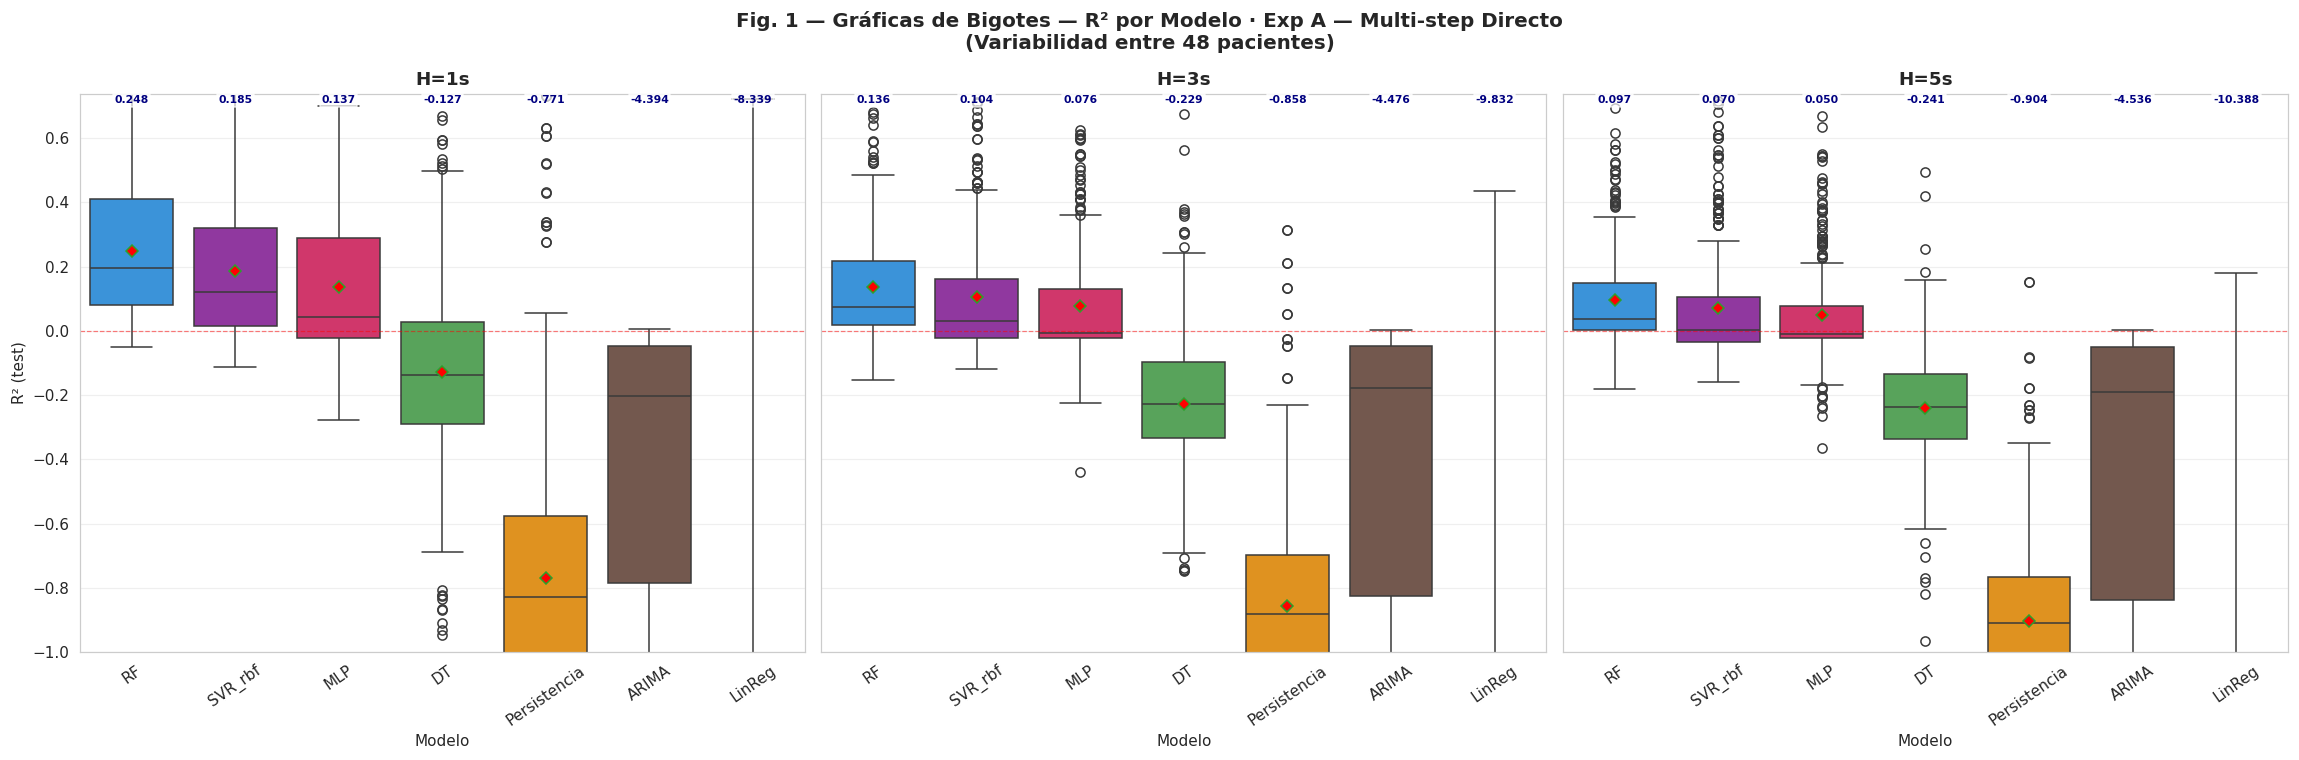

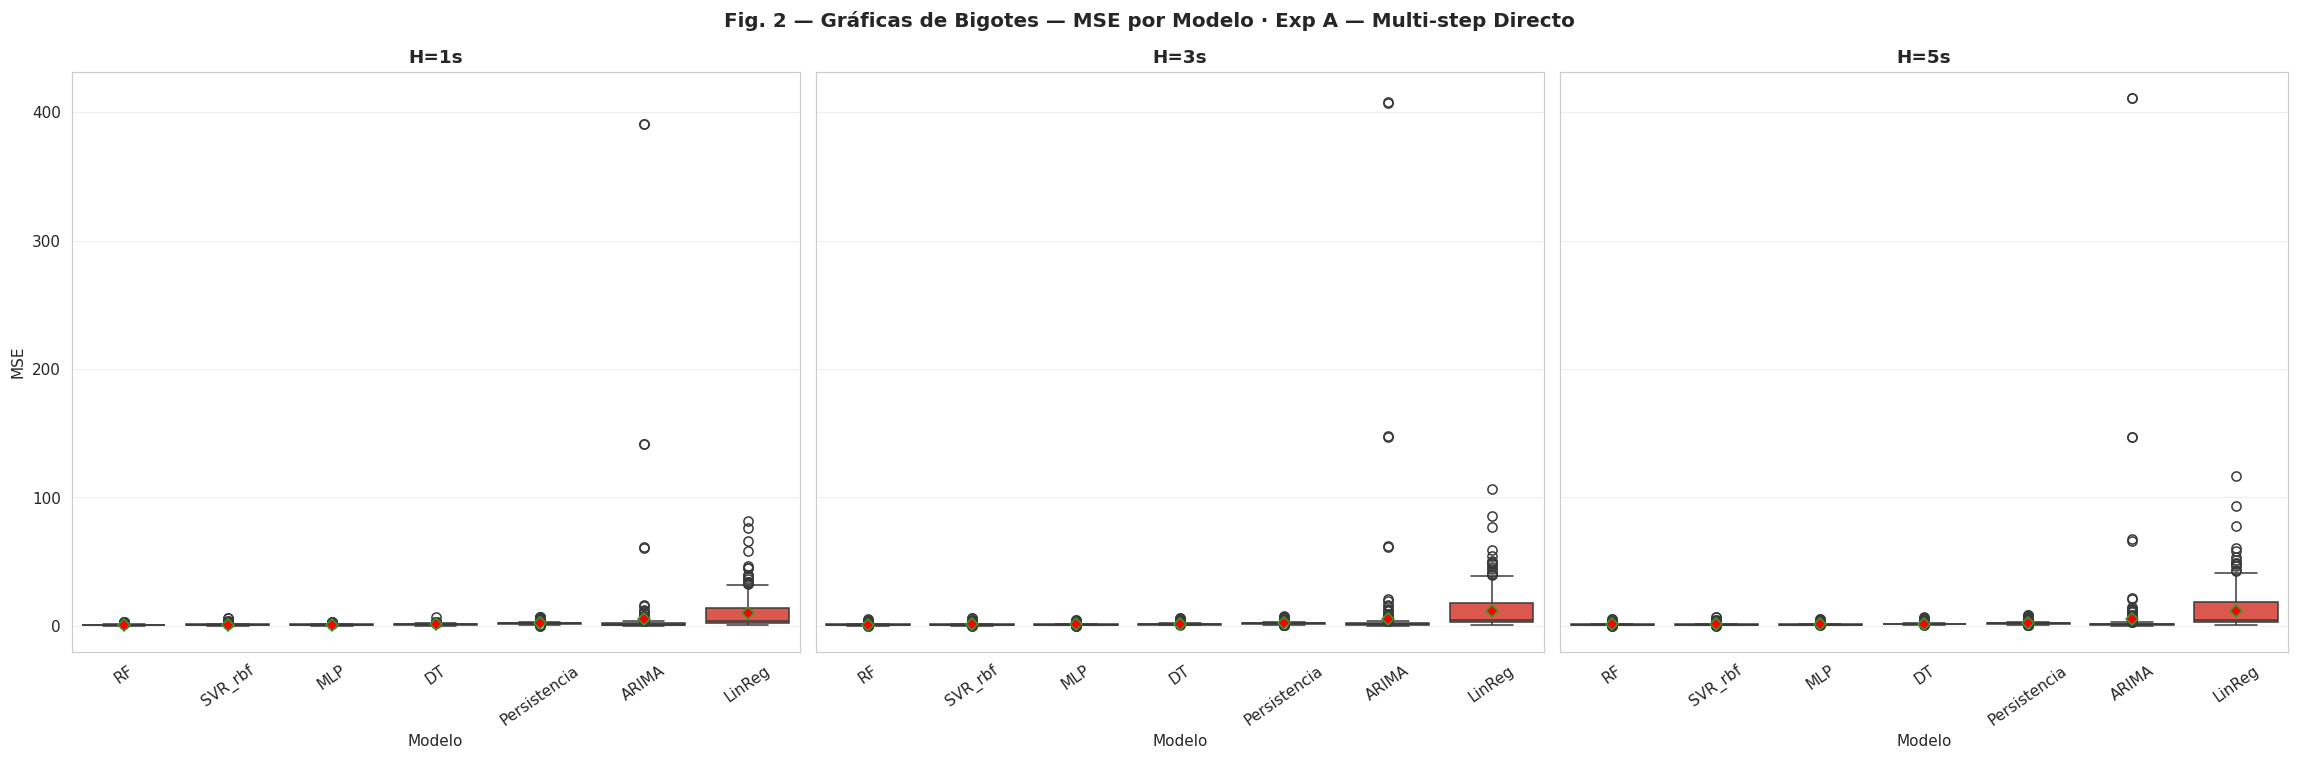

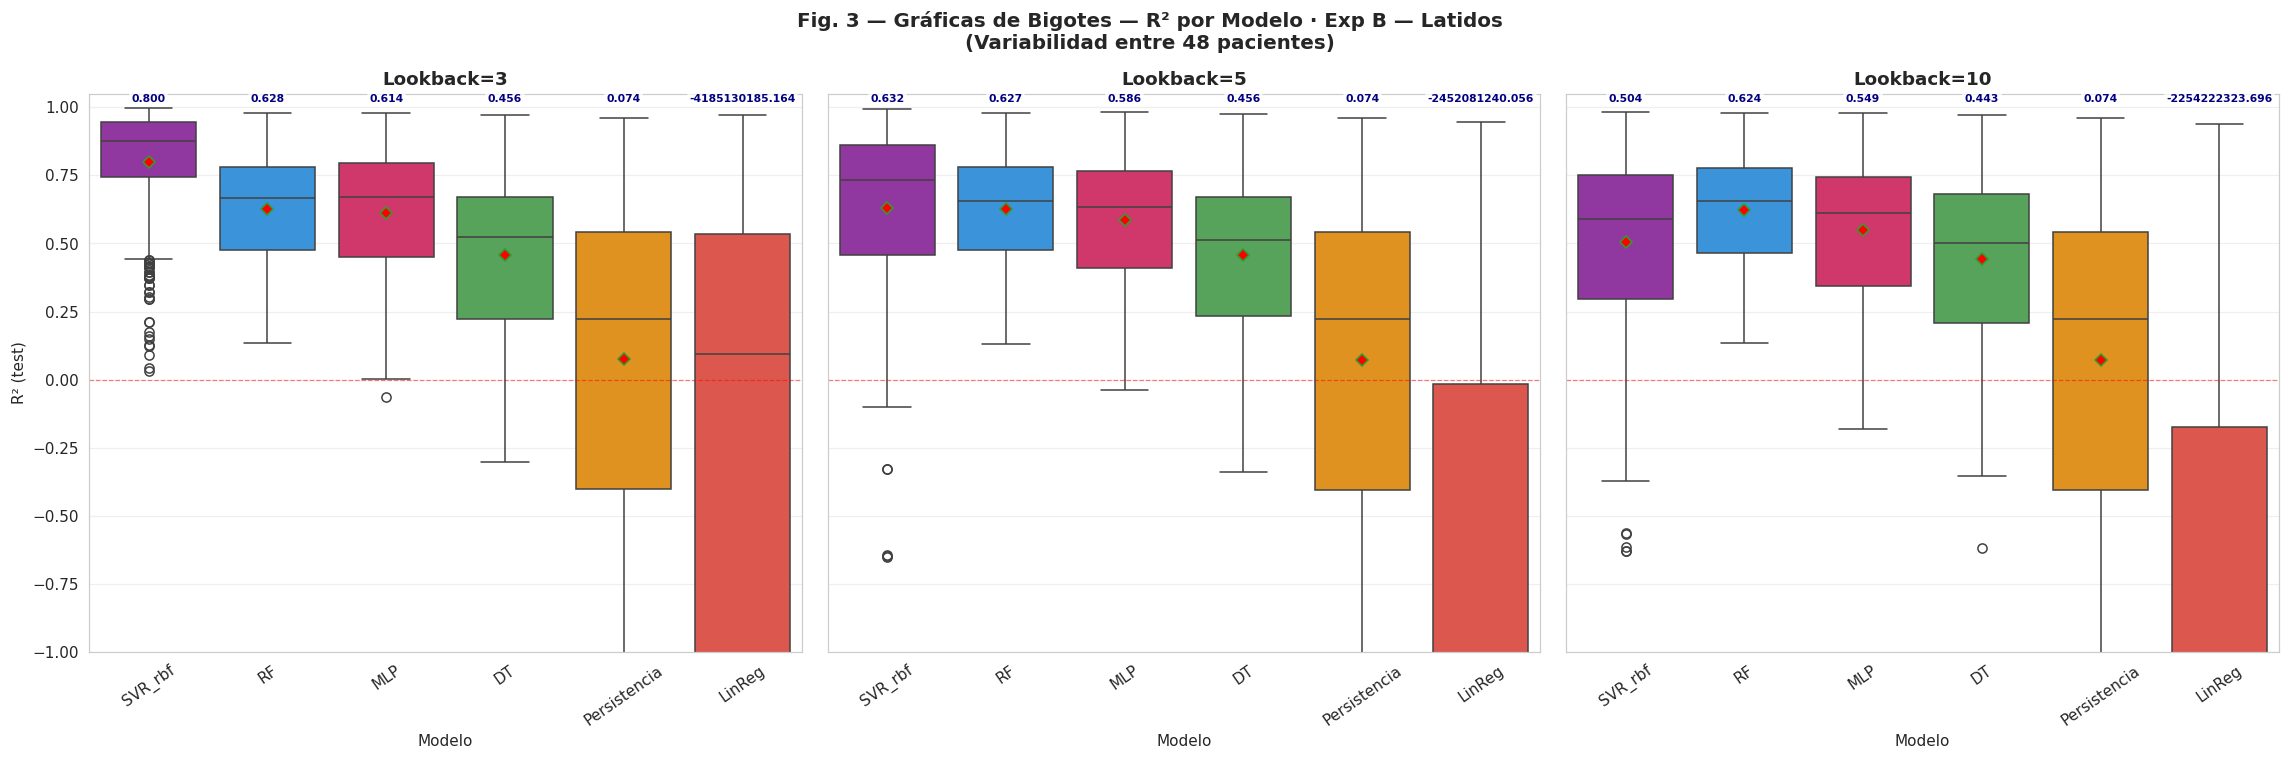

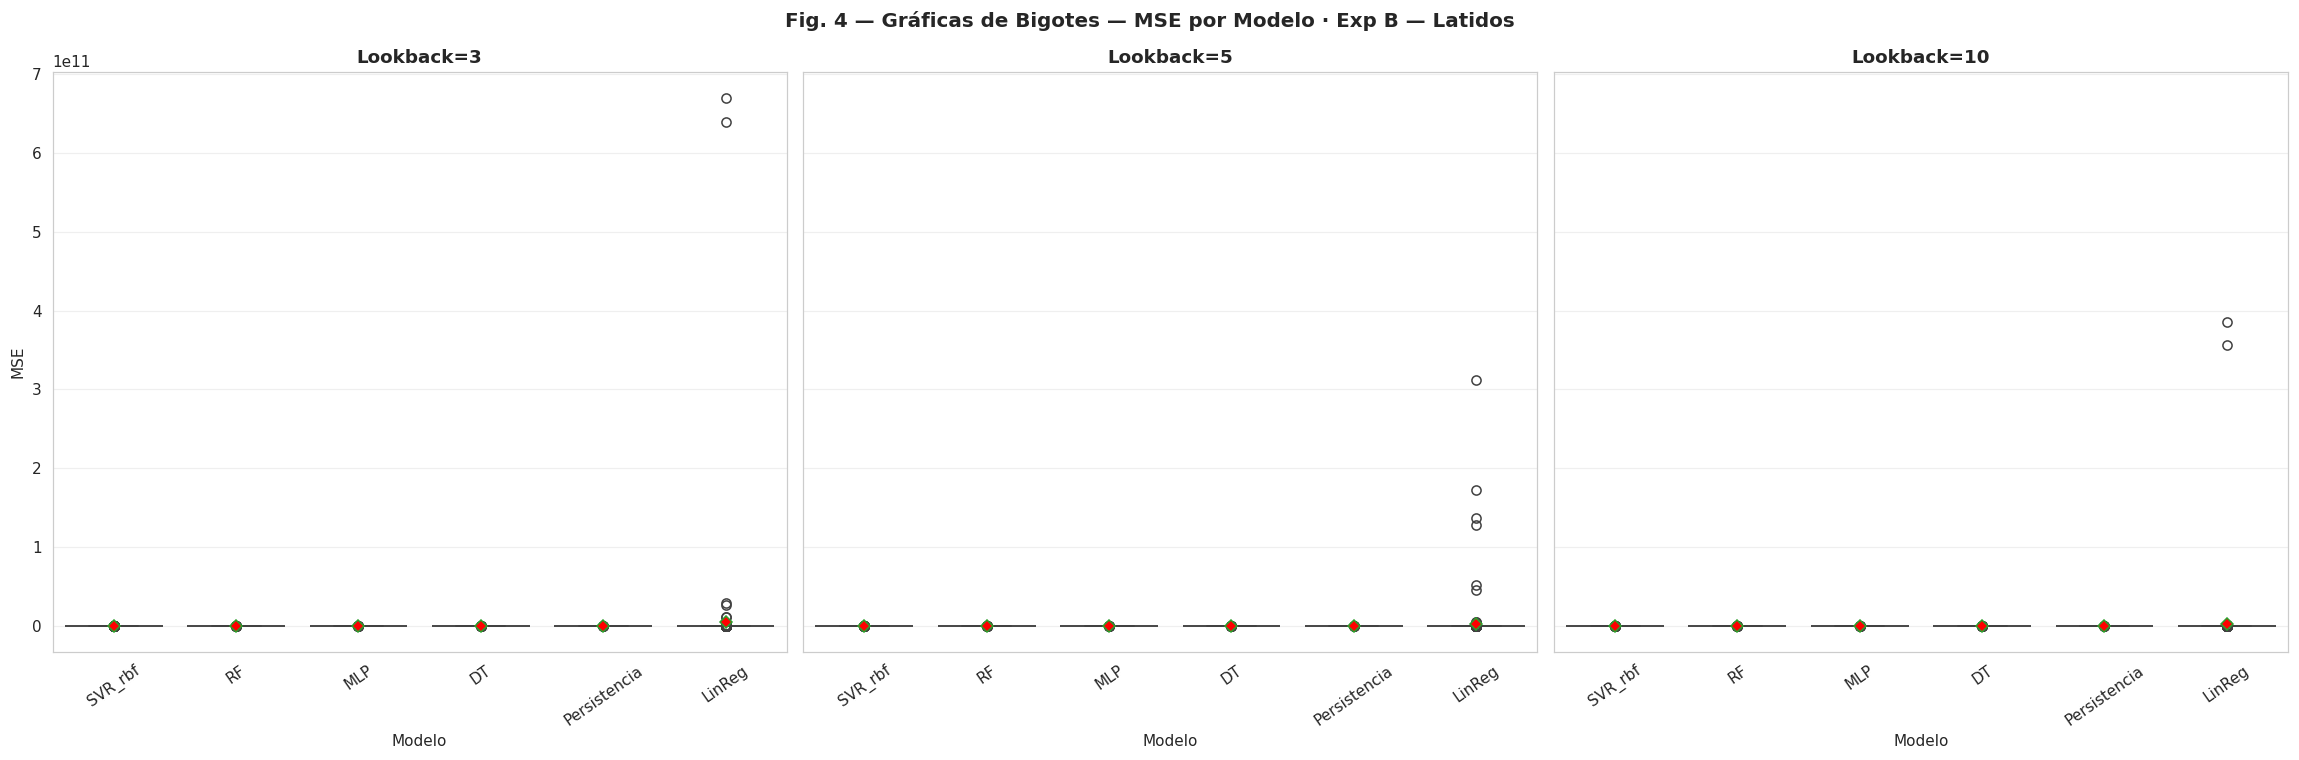

In [19]:
# ══════════════════════════════════════════════════════════════════
# GRÁFICAS DE BIGOTES (BOXPLOTS) POR MODELO
# ══════════════════════════════════════════════════════════════════

for tag, df_exp, grp_col in [
    ('Exp A — Multi-step Directo', df_A, 'Horizonte_seg'),
    ('Exp B — Latidos', df_B, 'Lookback')]:

    if df_exp.empty:
        continue

    grp_vals = sorted(df_exp[grp_col].unique())
    n_grp    = len(grp_vals)
    FIG_NUM  = 1 if 'Horizonte' in grp_col else 3
    tag_id   = tag[:5].replace(' ', '')   # 'Exp A' → 'ExpA'

    # ── Paleta consistente por modelo ────────────────────────────
    PALETA_MODELOS = {
        'LinReg'      : '#F44336', 'DT'          : '#4CAF50',
        'RF'          : '#2196F3', 'SVR_rbf'     : '#9C27B0',
        'MLP'         : '#E91E63', 'ARIMA'       : '#795548',
        'Persistencia': '#FF9800',
    }
    orden    = df_exp.groupby('Modelo')['R2'].mean().sort_values(ascending=False).index.tolist()
    pal_ord  = [PALETA_MODELOS.get(m, '#888888') for m in orden]

    y_min = max(df_exp['R2'].quantile(0.01), -1.0)
    y_max = min(df_exp['R2'].quantile(0.99) + 0.1, 1.05)

    # ── Boxplot R² ────────────────────────────────────────────────
    fig, axes = plt.subplots(1, n_grp, figsize=(7 * n_grp, 7), sharey=True)
    if n_grp == 1:
        axes = [axes]
    fig.suptitle(f'Fig. {FIG_NUM} — Gráficas de Bigotes — R² por Modelo · {tag}\n'
                 f'(Variabilidad entre {len(df_exp.Paciente.unique())} pacientes)',
                 fontsize=13, fontweight='bold')

    for ax, gv in zip(axes, grp_vals):
        sub = df_exp[df_exp[grp_col] == gv]
        sns.boxplot(data=sub, x='Modelo', y='R2', order=orden,
                    palette=pal_ord, ax=ax, showmeans=True,
                    meanprops={'marker': 'D', 'markerfacecolor': 'red', 'markersize': 6})
        ax.axhline(0, color='red', ls='--', lw=0.8, alpha=0.5)
        lbl = f'H={gv}s' if 'Horizonte' in grp_col else f'Lookback={gv}'
        ax.set_title(lbl, fontweight='bold')
        ax.set_ylabel('R² (test)')
        ax.set_ylim(y_min, y_max)
        ax.tick_params(axis='x', rotation=35)
        ax.grid(True, alpha=0.3, axis='y')

        medias = sub.groupby('Modelo')['R2'].mean().reindex(orden)
        for i, mu in enumerate(medias):
            if not np.isnan(mu):
                ax.text(i, y_max - 0.03, f'{mu:.3f}', ha='center', fontsize=7,
                        color='navy', fontweight='bold',
                        bbox=dict(facecolor='white', alpha=0.7, pad=1))

    plt.tight_layout()
    plt.savefig(os.path.join(RUTA_RESULTS, f'boxplot_{tag_id}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    # ── Boxplot MSE ───────────────────────────────────────────────
    fig, axes = plt.subplots(1, n_grp, figsize=(7 * n_grp, 7), sharey=True)
    if n_grp == 1:
        axes = [axes]
    fig.suptitle(f'Fig. {FIG_NUM+1} — Gráficas de Bigotes — MSE por Modelo · {tag}',
                 fontsize=13, fontweight='bold')

    for ax, gv in zip(axes, grp_vals):
        sub = df_exp[df_exp[grp_col] == gv]
        sns.boxplot(data=sub, x='Modelo', y='MSE', order=orden,
                    palette=pal_ord, ax=ax, showmeans=True,
                    meanprops={'marker': 'D', 'markerfacecolor': 'red', 'markersize': 6})
        lbl = f'H={gv}s' if 'Horizonte' in grp_col else f'Lookback={gv}'
        ax.set_title(lbl, fontweight='bold')
        ax.set_ylabel('MSE')
        ax.tick_params(axis='x', rotation=35)
        ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(os.path.join(RUTA_RESULTS, f'boxplot_mse_{tag_id}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

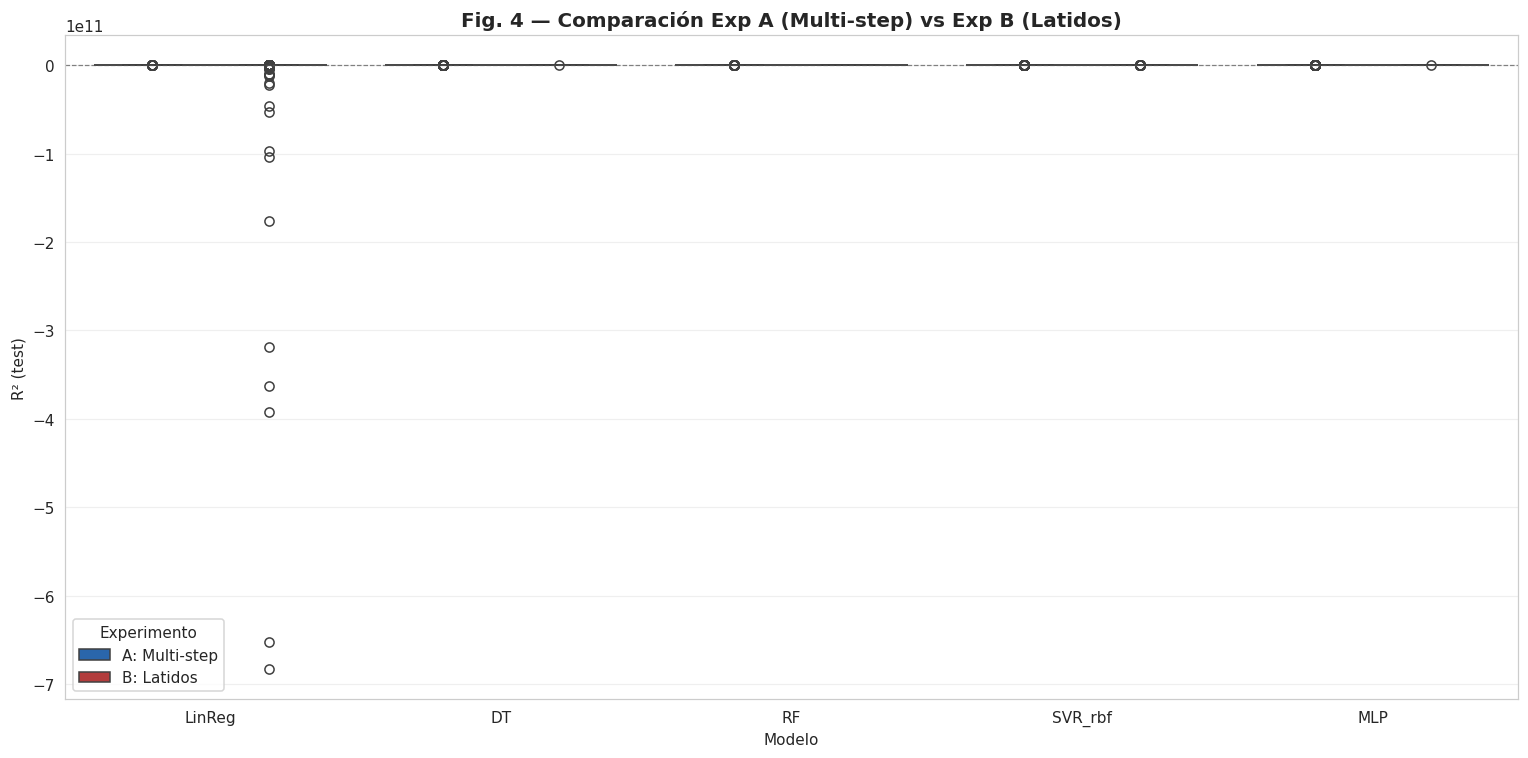

In [20]:
# ══════════════════════════════════════════════════════════════════
# BOXPLOT COMPARATIVO: Mismo Modelo en Exp A vs Exp B
# ══════════════════════════════════════════════════════════════════

if not df_A.empty and not df_B.empty:
    modelos_comunes = list(set(df_A.Modelo.unique()) & set(df_B.Modelo.unique()))
    modelos_comunes = [m for m in ['LinReg', 'DT', 'RF', 'SVR_rbf', 'MLP']
                       if m in modelos_comunes]

    if modelos_comunes:
        df_cmp = pd.concat([
            df_A[df_A.Modelo.isin(modelos_comunes)][['Modelo', 'R2', 'Paciente']]
                .assign(Experimento='A: Multi-step'),
            df_B[df_B.Modelo.isin(modelos_comunes)][['Modelo', 'R2', 'Paciente']]
                .assign(Experimento='B: Latidos'),
        ])

        fig, ax = plt.subplots(figsize=(14, 7))
        sns.boxplot(data=df_cmp, x='Modelo', y='R2', hue='Experimento',
                    palette=['#1565C0', '#C62828'], ax=ax, order=modelos_comunes)
        ax.axhline(0, color='gray', ls='--', lw=0.8)
        ax.set_title('Fig. 4 — Comparación Exp A (Multi-step) vs Exp B (Latidos)',
                     fontweight='bold', fontsize=13)
        ax.set_ylabel('R² (test)')
        ax.legend(title='Experimento')
        ax.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.savefig(os.path.join(RUTA_RESULTS, 'boxplot_A_vs_B.png'),
                    dpi=150, bbox_inches='tight')
        plt.show()


In [21]:
# ══════════════════════════════════════════════════════════════════
# TABLA MAESTRA: Filtro × Horizonte × Modelo con μ ± σ
# ══════════════════════════════════════════════════════════════════

if not df_A.empty:
    print('TABLA MAESTRA — Exp A: Filtro × Horizonte × Modelo')
    tabla = (df_A.groupby(['Filtro', 'Horizonte_seg', 'Modelo'])
             [['R2_train', 'R2', 'MSE', 'RMSE', 'MAE']]
             .agg(['mean', 'std']).round(4))
    tabla.to_csv(os.path.join(RUTA_RESULTS, 'tabla_maestra_A.csv'))
    # Mostrar versión pivoteada: R² test por Modelo × Horizonte (mejores filtros)
    top_filtros = df_A.groupby('Filtro')['R2'].mean().nlargest(5).index
    piv_A = (df_A[df_A.Filtro.isin(top_filtros)]
             .groupby(['Modelo', 'Horizonte_seg'])['R2'].mean()
             .unstack().round(4))
    try:
        display(piv_A.style
                .background_gradient(cmap='RdYlGn', vmin=-0.5, vmax=1)
                .set_caption('Tabla Maestra (top 5 filtros) — R² test: Modelo x Horizonte'))
    except Exception:
        display(piv_A)
    print(f'  (Tabla completa CSV: {len(tabla)} filas guardada)')

if not df_B.empty:
    print('\nTABLA MAESTRA — Exp B: Filtro × Lookback × Modelo')
    tabla_b = (df_B.groupby(['Filtro', 'Lookback', 'Modelo'])
               [['R2_train', 'R2', 'MSE', 'RMSE', 'MAE']]
               .agg(['mean', 'std']).round(4))
    tabla_b.to_csv(os.path.join(RUTA_RESULTS, 'tabla_maestra_B.csv'))
    top_filtros_b = df_B.groupby('Filtro')['R2'].mean().nlargest(5).index
    piv_B = (df_B[df_B.Filtro.isin(top_filtros_b)]
             .groupby(['Modelo', 'Lookback'])['R2'].mean()
             .unstack().round(4))
    try:
        display(piv_B.style
                .background_gradient(cmap='RdYlGn', vmin=-0.5, vmax=1)
                .set_caption('Tabla Maestra (top 5 filtros) — R² test: Modelo x Lookback'))
    except Exception:
        display(piv_B)
    print(f'  (Tabla completa CSV: {len(tabla_b)} filas guardada)')

TABLA MAESTRA — Exp A: Filtro × Horizonte × Modelo


Horizonte_seg,1,3,5
Modelo,,,
ARIMA,-1.777300,-1.606500,-1.515000
DT,-0.087000,-0.202600,-0.221300
LinReg,-2.103400,-2.828900,-3.134300
MLP,0.169600,0.091300,0.058400
Persistencia,-0.673000,-0.798500,-0.863800
RF,0.279500,0.155200,0.109700
SVR_rbf,0.224100,0.127300,0.086500


  (Tabla completa CSV: 147 filas guardada)

TABLA MAESTRA — Exp B: Filtro × Lookback × Modelo


Lookback,3,5,10
Modelo,,,
DT,0.469000,0.471200,0.453400
LinReg,-91.423800,-331.204700,-5906.813100
MLP,0.627500,0.602200,0.558100
Persistencia,0.105200,0.104900,0.104700
RF,0.636700,0.634900,0.629300
SVR_rbf,0.827400,0.714300,0.610200


  (Tabla completa CSV: 126 filas guardada)


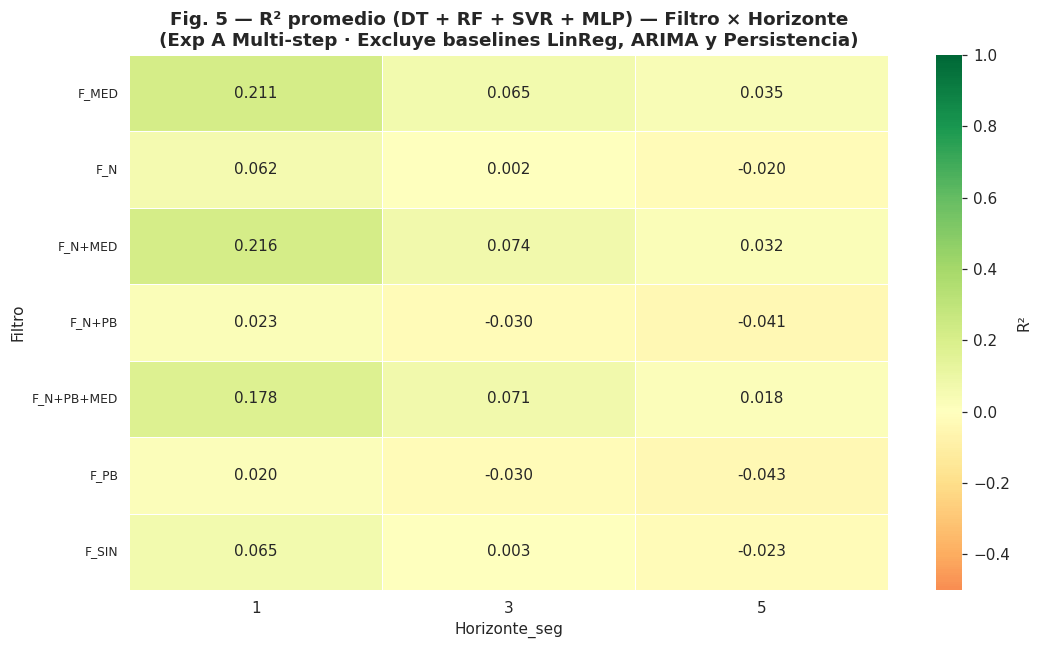

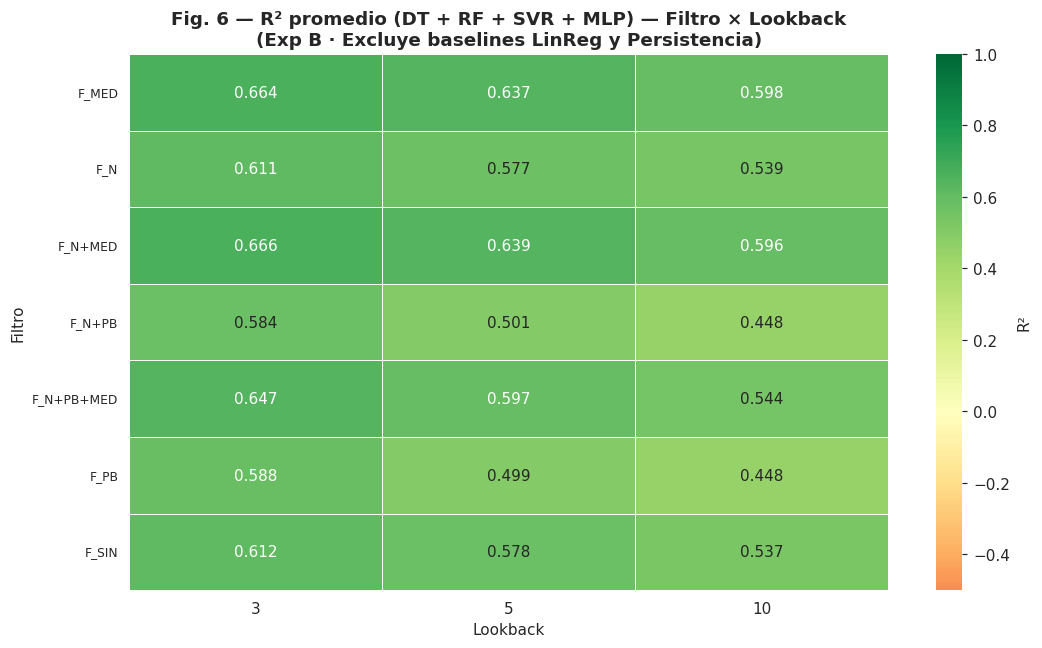

In [22]:
# ══════════════════════════════════════════════════════════════════
# HEATMAPS — R² por Filtro × Horizonte (Exp A) + Filtro × Lookback (Exp B)
# Se excluyen LinReg, ARIMA y Persistencia como baselines del heatmap principal
# ══════════════════════════════════════════════════════════════════

if not df_A.empty:
    df_real = df_A[~df_A.Modelo.isin(['LinReg', 'ARIMA', 'Persistencia'])]

    if not df_real.empty:
        piv_r2 = df_real.groupby(['Filtro', 'Horizonte_seg'])['R2'].mean().unstack()

        fig, ax = plt.subplots(figsize=(10, max(6, len(piv_r2) * 0.45 + 2)))
        sns.heatmap(piv_r2, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
                    vmin=-0.5, vmax=1.0, linewidths=0.5, ax=ax,
                    cbar_kws={'label': 'R²'})
        ax.set_title('Fig. 5 — R² promedio (DT + RF + SVR + MLP) — Filtro × Horizonte\n'
                     '(Exp A Multi-step · Excluye baselines LinReg, ARIMA y Persistencia)',
                     fontweight='bold')
        ax.tick_params(axis='y', labelsize=8)
        plt.tight_layout()
        plt.savefig(os.path.join(RUTA_RESULTS, 'heatmap_filtro_horizonte.png'),
                    dpi=150, bbox_inches='tight')
        plt.show()

if not df_B.empty:
    df_real_b = df_B[~df_B.Modelo.isin(['LinReg', 'ARIMA', 'Persistencia'])]

    if not df_real_b.empty:
        piv_r2_b = df_real_b.groupby(['Filtro', 'Lookback'])['R2'].mean().unstack()

        fig, ax = plt.subplots(figsize=(10, max(6, len(piv_r2_b) * 0.45 + 2)))
        sns.heatmap(piv_r2_b, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
                    vmin=-0.5, vmax=1.0, linewidths=0.5, ax=ax,
                    cbar_kws={'label': 'R²'})
        ax.set_title('Fig. 6 — R² promedio (DT + RF + SVR + MLP) — Filtro × Lookback\n'
                     '(Exp B · Excluye baselines LinReg y Persistencia)',
                     fontweight='bold')
        ax.tick_params(axis='y', labelsize=8)
        plt.tight_layout()
        plt.savefig(os.path.join(RUTA_RESULTS, 'heatmap_filtro_lookback.png'),
                    dpi=150, bbox_inches='tight')
        plt.show()


  PRUEBAS ESTADÍSTICAS — Exp A

  ANOVA no paramétrica (Friedman) sobre R² por modelo:
    χ² = 269.2321   p-valor = 0.000000
    → Diferencia significativa entre modelos (p < 0.05)

  T-tests pareados (Wilcoxon) — cada modelo vs Persistencia:


,Modelo,ΔR²_vs_Persistencia,W_stat,p_valor,Significativo
1,DT,0.6454,11.0,0.000000,✓
2,LinReg,-8.6755,0.0,0.000000,✓
3,MLP,0.9320,0.0,0.000000,✓
4,RF,1.0046,0.0,0.000000,✓
5,SVR_rbf,0.9640,0.0,0.000000,✓
0,ARIMA,-3.6241,442.0,0.136582,—



  Intervalos de confianza 95% — R² test:


,Modelo,R2_media,IC_95_inf,IC_95_sup,N
5,RF,0.1603,0.1488,0.1717,1008
6,SVR_rbf,0.1197,0.1076,0.1318,1008
3,MLP,0.0878,0.0760,0.0995,1008
1,DT,-0.1989,-0.2164,-0.1814,1008
4,Persistencia,-0.8443,-0.8665,-0.8221,1008
0,ARIMA,-4.4684,-6.6163,-2.3206,1008
2,LinReg,-9.5198,-10.2702,-8.7694,1008


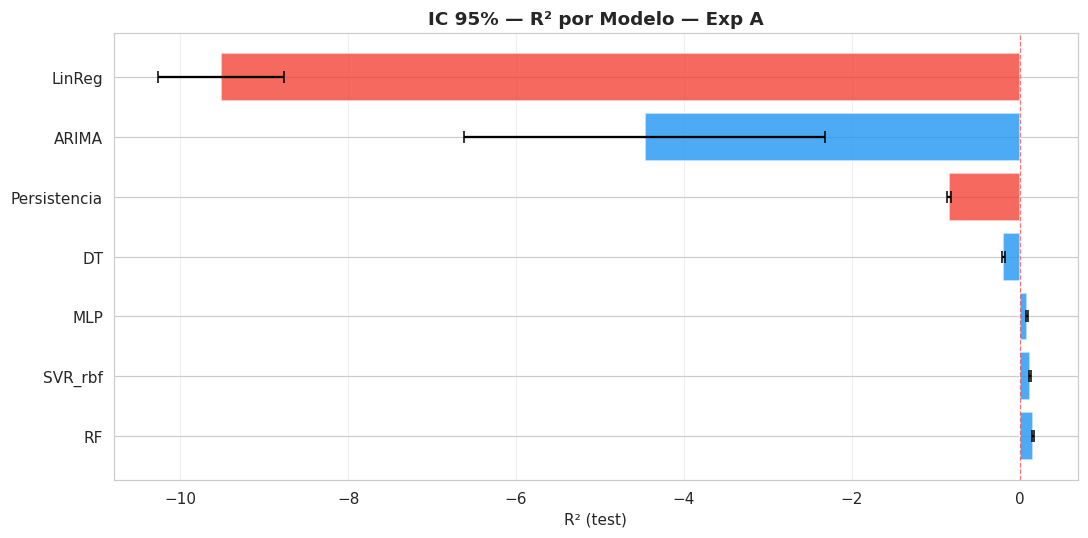


  PRUEBAS ESTADÍSTICAS — Exp B

  ANOVA no paramétrica (Friedman) sobre R² por modelo:
    χ² = 185.3214   p-valor = 0.000000
    → Diferencia significativa entre modelos (p < 0.05)

  T-tests pareados (Wilcoxon) — cada modelo vs Persistencia:


,Modelo,ΔR²_vs_Persistencia,W_stat,p_valor,Significativo
0,DT,3.780000e-01,49.0,0.0,✓
1,LinReg,-2.963811e+09,0.0,0.0,✓
2,MLP,5.089000e-01,9.0,0.0,✓
3,RF,5.524000e-01,5.0,0.0,✓
4,SVR_rbf,5.714000e-01,72.0,0.0,✓



  Intervalos de confianza 95% — R² test:


,Modelo,R2_media,IC_95_inf,IC_95_sup,N
5,SVR_rbf,6.454000e-01,6.262000e-01,6.646000e-01,1008
4,RF,6.264000e-01,6.140000e-01,6.389000e-01,1008
2,MLP,5.829000e-01,5.678000e-01,5.980000e-01,1008
0,DT,4.520000e-01,4.341000e-01,4.699000e-01,1008
3,Persistencia,7.400000e-02,3.910000e-02,1.089000e-01,1008
1,LinReg,-2.963811e+09,-5.205748e+09,-7.218742e+08,1008


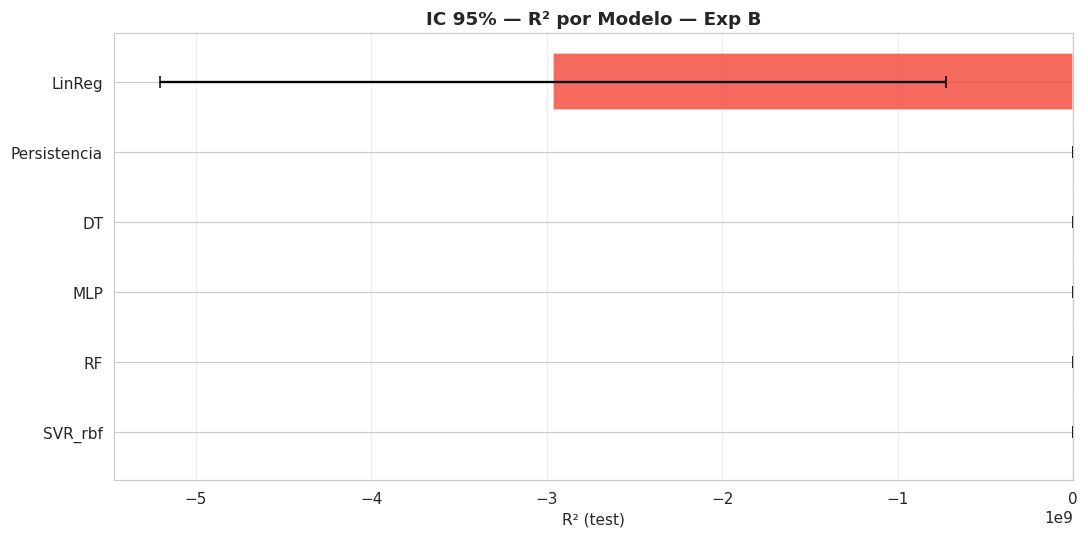


Pruebas estadísticas completadas.


In [23]:
# ══════════════════════════════════════════════════════════════════
# PRUEBAS ESTADÍSTICAS: Friedman + Wilcoxon (vs Persistencia) + IC 95%
# ══════════════════════════════════════════════════════════════════
from scipy import stats

for tag, df_exp, grp_col in [
    ('Exp A', df_A, 'Horizonte_seg'),
    ('Exp B', df_B, 'Lookback')]:

    if df_exp.empty:
        continue

    print(f'\n{"=" * 70}')
    print(f'  PRUEBAS ESTADÍSTICAS — {tag}')
    print('=' * 70)

    tag_id = tag[:5].replace(' ', '')   # 'Exp A' → 'ExpA'

    modelos_uniq = sorted(df_exp['Modelo'].unique())
    piv = df_exp.pivot_table(index='Paciente', columns='Modelo',
                             values='R2', aggfunc='mean').dropna()

    # ── 1. ANOVA no paramétrica (Friedman) ───────────────────────
    if piv.shape[1] >= 3 and piv.shape[0] >= 5:
        grupos = [piv[m].values for m in piv.columns]
        stat_f, p_f = stats.friedmanchisquare(*grupos)
        print(f'\n  ANOVA no paramétrica (Friedman) sobre R² por modelo:')
        print(f'    χ² = {stat_f:.4f}   p-valor = {p_f:.6f}')
        if p_f < 0.05:
            print(f'    → Diferencia significativa entre modelos (p < 0.05)')
        else:
            print(f'    → Sin diferencia significativa (p ≥ 0.05)')

    # ── 2. Wilcoxon — cada modelo vs Persistencia (baseline naive) ──
    print(f'\n  T-tests pareados (Wilcoxon) — cada modelo vs Persistencia:')
    ref_mod = 'Persistencia' if 'Persistencia' in piv.columns else 'LinReg'
    if ref_mod in piv.columns:
        ref = piv[ref_mod].values
        filas_ttest = []
        for mod in piv.columns:
            if mod == ref_mod:
                continue
            vals = piv[mod].values
            if len(vals) < 5:
                continue
            try:
                stat_w, p_w = stats.wilcoxon(vals, ref, alternative='two-sided')
                diff_media   = np.mean(vals - ref)
                filas_ttest.append({
                    'Modelo'        : mod,
                    f'ΔR²_vs_{ref_mod}': round(diff_media, 4),
                    'W_stat'        : round(stat_w, 2),
                    'p_valor'       : round(p_w, 6),
                    'Significativo' : '✓' if p_w < 0.05 else '—',
                })
            except Exception:
                pass
        if filas_ttest:
            df_tt = pd.DataFrame(filas_ttest).sort_values('p_valor')
            display(df_tt)
            df_tt.to_csv(os.path.join(RUTA_RESULTS,
                         f'wilcoxon_vs_persistencia_{tag_id}.csv'), index=False)
    else:
        print(f'  {ref_mod} no disponible como referencia.')

    # ── 3. Intervalos de confianza 95% ────────────────────────────
    print(f'\n  Intervalos de confianza 95% — R² test:')
    filas_ic = []
    for mod in modelos_uniq:
        vals = df_exp[df_exp['Modelo'] == mod]['R2'].dropna().values
        if len(vals) < 3:
            continue
        mu   = vals.mean()
        se   = vals.std(ddof=1) / np.sqrt(len(vals))
        ci_lo = mu - 1.96 * se
        ci_hi = mu + 1.96 * se
        filas_ic.append({
            'Modelo'   : mod,
            'R2_media' : round(mu, 4),
            'IC_95_inf': round(ci_lo, 4),
            'IC_95_sup': round(ci_hi, 4),
            'N'        : len(vals),
        })
    if filas_ic:
        df_ic = pd.DataFrame(filas_ic).sort_values('R2_media', ascending=False)
        display(df_ic)
        df_ic.to_csv(os.path.join(RUTA_RESULTS, f'ic95_r2_{tag_id}.csv'), index=False)

        fig, ax = plt.subplots(figsize=(10, max(5, len(df_ic) * 0.5)))
        y_pos = range(len(df_ic))
        ax.barh(y_pos, df_ic['R2_media'],
                xerr=[df_ic['R2_media'] - df_ic['IC_95_inf'],
                      df_ic['IC_95_sup'] - df_ic['R2_media']],
                color=['#2196F3' if m not in ('LinReg', 'Persistencia') else '#F44336'
                       for m in df_ic['Modelo']],
                capsize=4, alpha=0.8)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(df_ic['Modelo'])
        ax.set_xlabel('R² (test)')
        ax.set_title(f'IC 95% — R² por Modelo — {tag}', fontweight='bold')
        ax.axvline(0, color='red', ls='--', lw=0.8, alpha=0.5)
        ax.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.savefig(os.path.join(RUTA_RESULTS, f'ic95_{tag_id}.png'),
                    dpi=150, bbox_inches='tight')
        plt.show()

print('\nPruebas estadísticas completadas.')

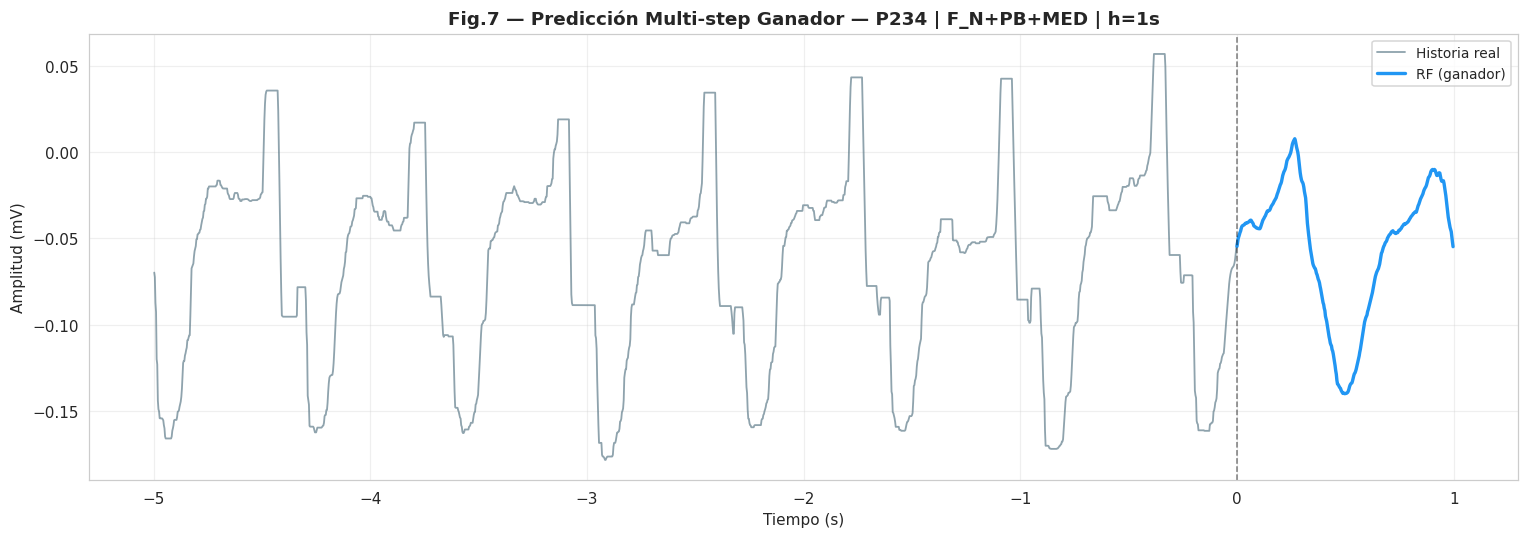

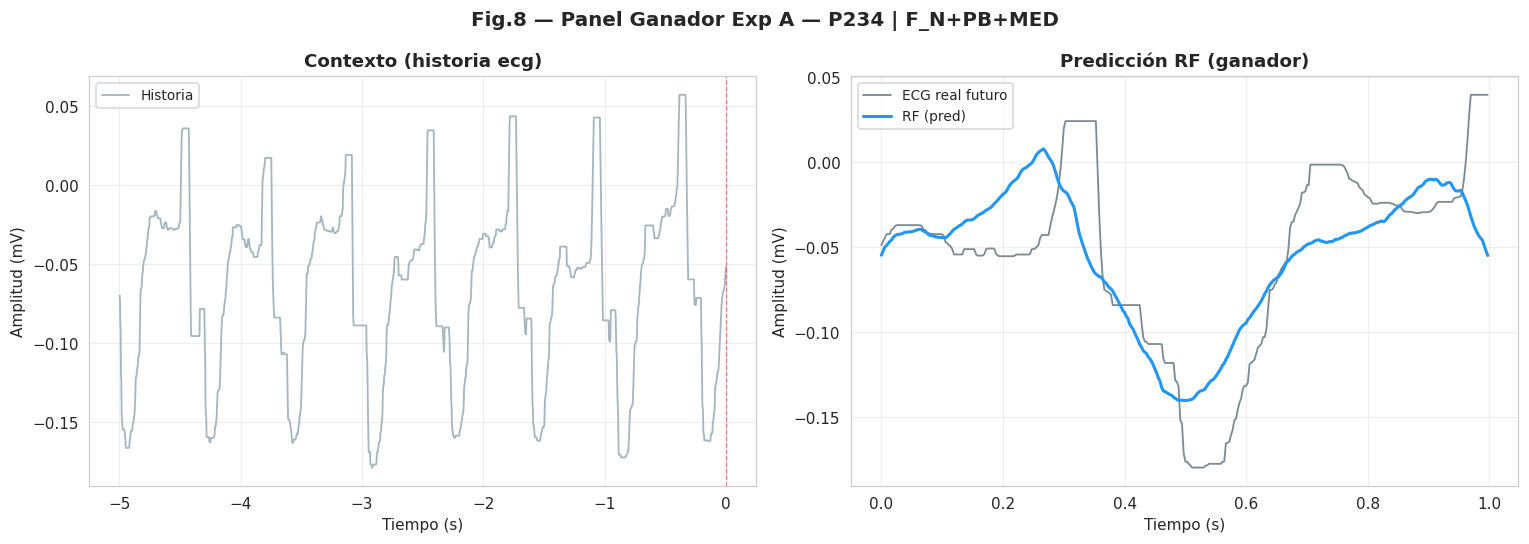

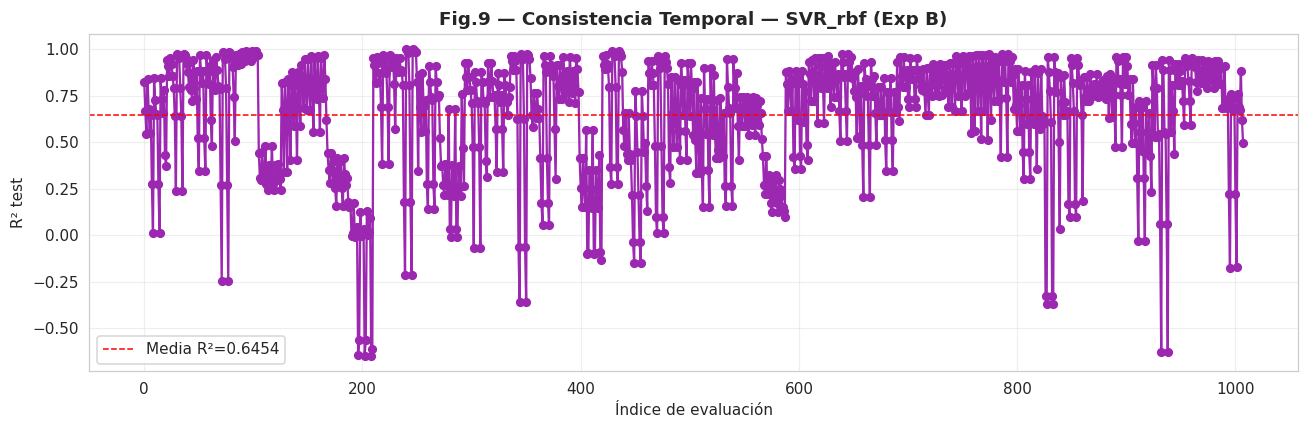


Visualizaciones de predicción completadas.


In [24]:
COLORES_VIS = {
    'LinReg' : '#F44336',
    'DT'     : '#4CAF50',
    'RF'     : '#2196F3',
    'SVR_rbf': '#9C27B0',
    'MLP'    : '#E91E63',
    'ARIMA'  : '#795548',
}

# ── Helper para normalización/desnormalización ────────────────
def _zscore_transform_single(arr, mu, std):
    """Aplica normalización Z-score a una única serie/array."""
    return (arr - mu) / std

def _zscore_inverse_transform_single(arr_n, mu, std):
    """Deshace normalización Z-score de una única serie/array."""
    return (arr_n * std) + mu

def _get_normalization_and_pca_params_for_winner(winner_config, L_mues, H_mues, model_name):
    """Re-deriva mu, std y objeto PCA para la configuración del modelo ganador."""
    pid = winner_config['pid']
    filtro_name = winner_config['filtro']

    s_raw, _ = cargar_ecg(pid)
    if s_raw is None: return None, None, None

    try:
        sf = aplica(s_raw, FILTROS[filtro_name])
    except KeyError:
        sf = s_raw.copy()

    X, y = segmentar_tiempo(sf, L_mues, H_mues)
    if len(X) < 20: return None, None, None

    Xtr, _, _, _ = split_temporal(X, y)

    mu = Xtr.mean()
    std = max(Xtr.std(), 1e-8)

    pca_obj = None
    if model_name in ('SVR_rbf', 'MLP'):
        Xtr_norm = _zscore_transform_single(Xtr, mu, std)
        n_comp = min(50, Xtr_norm.shape[1], Xtr_norm.shape[0] - 1)
        if n_comp > 0:
            pca_obj = PCA(n_components=n_comp, random_state=SEED)
            pca_obj.fit(Xtr_norm)

    del s_raw, sf, X, y, Xtr; gc.collect()
    return mu, std, pca_obj

# ── Helpers for prediction ────────────────────────────────────────
def _predecir_ganador(tracker, Xte_v_raw, hm, mu, std, pca_obj):
    """Genera predicción con el modelo ganador almacenado en tracker."""
    if tracker['modelo'] is None: return None
    mod = tracker['modelo']
    nom = tracker['nom']

    if nom == 'ARIMA':
        return None

    try:
        Xte_v_norm = _zscore_transform_single(Xte_v_raw, mu, std)
        if pca_obj and nom in ('SVR_rbf', 'MLP'):
            Xte_v_norm = pca_obj.transform(Xte_v_norm)

        yp_norm = np.array(mod.predict(Xte_v_norm)).flatten()[:hm]
        yp = _zscore_inverse_transform_single(yp_norm, mu, std)
        return yp
    except Exception as e:
        print(f'  _predecir_ganador error: {e}')
        return None

# ── FIG. 7 & 8 — Exp A: modelo ganador ────────────────────────────
if not mejor_global_A['modelo']:
    print('El mejor modelo global de Exp A no está disponible. Ejecutar Experimento A primero.')
else:
    pid_vis = mejor_global_A['config']['pid']
    filtro_vis_key = mejor_global_A['config']['filtro']
    hv_vis = mejor_global_A['config']['horizonte_seg']
    hm_vis = int(hv_vis * FS)
    model_winner_name = mejor_global_A['nom']

    mu_winner, std_winner, pca_winner = _get_normalization_and_pca_params_for_winner(
        mejor_global_A['config'], VENTANA_L_MUES, hm_vis, model_winner_name)

    if mu_winner is None or std_winner is None:
        print(f'No se pudieron obtener parámetros de normalización para el ganador {model_winner_name}.')
    else:
        s_raw_vis, _ = cargar_ecg(pid_vis)
        if s_raw_vis is None:
            print(f'No se pudo cargar paciente {pid_vis} para visualización.')
        else:
            try:
                ecg_full_filtered = aplica(s_raw_vis, FILTROS[filtro_vis_key])
            except KeyError:
                ecg_full_filtered = s_raw_vis.copy()

            N_SEG = VENTANA_L_MUES
            n_total_filtered = len(ecg_full_filtered)
            n_train_filtered = int(n_total_filtered * PROP_TRAIN)

            start_idx_test_segment = n_train_filtered + 5 * FS
            idx_ini = start_idx_test_segment

            if (idx_ini + N_SEG + hm_vis) > n_total_filtered:
                idx_ini = n_total_filtered - N_SEG - hm_vis - 1
                if idx_ini < n_train_filtered:
                     idx_ini = n_train_filtered - N_SEG - 1
                if idx_ini < 0: idx_ini = 0

            Xte_v_raw_window = ecg_full_filtered[idx_ini : idx_ini + N_SEG].reshape(1, -1)

            yp_g = _predecir_ganador(mejor_global_A, Xte_v_raw_window, hm_vis, mu_winner, std_winner, pca_winner)

            # Fig. 7 — predicción del ganador sobre la señal real
            fig, ax = plt.subplots(figsize=(14, 5))
            t_hist   = np.arange(Xte_v_raw_window.shape[1]) / FS
            t_future = np.arange(hm_vis) / FS
            ax.plot(t_hist - t_hist[-1], Xte_v_raw_window.flatten(),
                    color='#607D8B', lw=1.2, alpha=0.7, label='Historia real')
            if yp_g is not None:
                nom_g  = mejor_global_A['nom']
                color_g = COLORES_VIS.get(nom_g, '#333')
                ax.plot(t_future[:len(yp_g)], yp_g,
                        color=color_g, lw=2.2, label=f'{nom_g} (ganador)')
            ax.axvline(0, color='black', ls='--', lw=1, alpha=0.5)
            ax.set_xlabel('Tiempo (s)');  ax.set_ylabel('Amplitud (mV)')
            ax.set_title(f'Fig.7 — Predicción Multi-step Ganador — P{pid_vis} | {filtro_vis_key} | h={hv_vis}s',
                         fontweight='bold')
            ax.legend(loc='upper right', fontsize=9)
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(os.path.join(RUTA_RESULTS, 'prediccion_multistep_todos.png'),
                        dpi=150, bbox_inches='tight')
            plt.show()

            # Fig. 8 — Panel comparativo de la señal: historia + predicción ganador
            if yp_g is not None:
                fig, axes = plt.subplots(1, 2, figsize=(14, 5))
                t_hist   = np.arange(Xte_v_raw_window.shape[1]) / FS
                t_future = np.arange(len(yp_g)) / FS
                nom_g    = mejor_global_A['nom']
                color_g  = COLORES_VIS.get(nom_g, '#2196F3')

                axes[0].plot(t_hist - t_hist[-1], Xte_v_raw_window.flatten(),
                            color='#90A4AE', lw=1.2, alpha=0.8, label='Historia')
                axes[0].axvline(0, color='red', ls='--', lw=0.8, alpha=0.5)
                axes[0].set_title('Contexto (historia ecg)', fontweight='bold')
                axes[0].set_xlabel('Tiempo (s)');  axes[0].set_ylabel('Amplitud (mV)')
                axes[0].legend(fontsize=9);  axes[0].grid(True, alpha=0.3)

                ecg_fut = ecg_full_filtered[idx_ini + N_SEG : idx_ini + N_SEG + hm_vis]
                if len(ecg_fut) > 0:
                    axes[1].plot(t_future[:len(ecg_fut)], ecg_fut,
                                color='#455A64', lw=1.2, alpha=0.7, label='ECG real futuro')
                axes[1].plot(t_future, yp_g,
                            color=color_g, lw=2, label=f'{nom_g} (pred)')
                axes[1].set_title(f'Predicción {nom_g} (ganador)', fontweight='bold')
                axes[1].set_xlabel('Tiempo (s)');  axes[1].set_ylabel('Amplitud (mV)')
                axes[1].legend(fontsize=9);  axes[1].grid(True, alpha=0.3)

                fig.suptitle(f'Fig.8 — Panel Ganador Exp A — P{pid_vis} | {filtro_vis_key}',
                             fontweight='bold', fontsize=13)
                plt.tight_layout()
                plt.savefig(os.path.join(RUTA_RESULTS, 'prediccion_vs_real.png'),
                            dpi=150, bbox_inches='tight')
                plt.show()
            del s_raw_vis, ecg_full_filtered; gc.collect()

# ── FIG. 9 — Consistencia temporal Exp B ──────────────────────────
if not df_B.empty:
    grp_b     = df_B.groupby('Modelo')['R2'].mean().sort_values(ascending=False)
    mejor_m_b = grp_b.index[0] if len(grp_b) else 'RF'
    vals_b    = df_B[df_B['Modelo'] == mejor_m_b]['R2'].values
    if len(vals_b) > 0:
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(vals_b, 'o-', color=COLORES_VIS.get(mejor_m_b, '#2196F3'), lw=1.5, ms=5)
        ax.axhline(vals_b.mean(), color='red', ls='--', lw=1,
                   label=f'Media R²={vals_b.mean():.4f}')
        ax.set_xlabel('Índice de evaluación');  ax.set_ylabel('R² test')
        ax.set_title(f'Fig.9 — Consistencia Temporal — {mejor_m_b} (Exp B)',
                     fontweight='bold')
        ax.legend();  ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(RUTA_RESULTS, 'prediccion_consistencia.png'),
                    dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print(f'No hay datos para el modelo {mejor_m_b} en df_B para visualizar.')
else:
    print('df_B vacío — ejecutar Exp B primero para Fig.9')

print('\nVisualizaciones de predicción completadas.')

---
## BLOQUE 10 — Conclusiones y exportación config_NB2.json

In [25]:

# ══════════════════════════════════════════════════════════════════
# CONCLUSIONES EXP1 — NB1 Modelos Tradicionales (Multi-step Directo)
# ══════════════════════════════════════════════════════════════════

print('=' * 70)
print('  CONCLUSIONES EXP1 — NB1 Modelos Tradicionales')
print('  6 modelos: LinReg · DT · RF · SVR_rbf · MLP · ARIMA')
print('=' * 70)

for tag, df_exp in [('Exp A (Multi-step)', df_A), ('Exp B (Latidos)', df_B)]:
    if df_exp.empty:
        continue

    print(f'\n── {tag} ──')

    for mod in df_exp.Modelo.unique():
        sub = df_exp[df_exp.Modelo == mod]
        r2_tr = sub['R2_train'].mean() if 'R2_train' in sub.columns else np.nan
        r2_te = sub['R2'].mean()
        r2_std = sub['R2'].std()
        print(f'  {mod:15s}: R²_train={r2_tr:+.4f}  R²_test={r2_te:+.4f} ± {r2_std:.4f}')

# ══════════════════════════════════════════════════════════════════
# DIAGNÓSTICO FINAL: Formulación
# ══════════════════════════════════════════════════════════════════
print(f'\n{"=" * 70}')
print('  FORMULACIÓN APLICADA')
print('=' * 70)
print(f'''
  Exp A — Multi-step Directo Seq-to-Seq:
  ───────────────────────────────────────
  • Entrada:  L = {VENTANA_L}s ({VENTANA_L_MUES} muestras de historia)
  • Salida:   H = {HORIZONTES_SEG}s ({HORIZONTES_MUES} muestras a predecir)
  • Objetivo: anticipar el segmento futuro completo de la señal ECG
  • Corrección: la formulación anterior (one-step-ahead) predecía solo
    2.8 ms (1 muestra), trivial por autocorrelación. Ahora se predicen
    1–5 segundos hacia el futuro → reto clínico real.

  Exp B — One-beat-ahead:
  ───────────────────────
  • Entrada:  N latidos aplanados (N = {LOOKBACKS_BEAT})
  • Salida:   Siguiente latido completo ({BEAT_LEN} muestras)
  • Esta formulación ya era correcta desde el inicio.
''')

# ── Tabla resumen final ──────────────────────────────────────────
print(f'\n{"=" * 70}')
print('  TABLA RESUMEN FINAL — 4 modelos genuinos (DT, RF, SVR_rbf, MLP)')
print('  (Excluye LinReg y ARIMA que actúan como baselines lineales)')
print('=' * 70)
resumen_final = []
for tag, df_exp in [('Exp A', df_A), ('Exp B', df_B)]:
    if df_exp.empty:
        continue
    df_real = df_exp[~df_exp.Modelo.isin(['LinReg', 'ARIMA'])]
    if df_real.empty:
        continue

    for mod in df_real.Modelo.unique():
        sub = df_real[df_real.Modelo == mod]
        r2_media = sub['R2'].mean()
        r2_linreg = df_exp[df_exp.Modelo == 'LinReg']['R2'].mean()
        mejora_vs_linreg = r2_media - r2_linreg if not np.isnan(r2_linreg) else np.nan
        resumen_final.append({
            'Exp'            : tag,
            'Modelo'         : mod,
            'R²_test_μ'      : r2_media,
            'R²_test_σ'      : sub['R2'].std(),
            'MSE_μ'          : sub['MSE'].mean(),
            'Mejora_vs_LinReg': mejora_vs_linreg,
            'N_evals'        : len(sub),
        })
if resumen_final:
    df_final = pd.DataFrame(resumen_final).sort_values('R²_test_μ', ascending=False)
    try:
        display(df_final.style
                .background_gradient(subset=['R²_test_μ'], cmap='RdYlGn', vmin=-0.5, vmax=1)
                .background_gradient(subset=['MSE_μ'], cmap='RdYlGn_r')
                .background_gradient(subset=['Mejora_vs_LinReg'], cmap='RdYlGn', vmin=-0.1, vmax=0.1)
                .format({'R²_test_μ': '{:.4f}', 'R²_test_σ': '{:.4f}',
                         'MSE_μ': '{:.6f}', 'Mejora_vs_LinReg': '{:+.4f}'})
                .set_caption('Ranking final — Modelos genuinos (DT, RF, SVR_rbf, MLP)\n'
                             'NOTA: SVR_rbf en Exp B predice solo 1 muestra (escalar), '
                             'no el latido completo de 256 muestras. No comparar directamente con RF/DT/MLP.\n'
                             'Mejora_vs_LinReg: diferencia respecto al baseline LinReg'))
    except Exception:
        display(df_final)

# ══════════════════════════════════════════════════════════════════
# ESTADO DE MODELOS POR PACIENTE
# ══════════════════════════════════════════════════════════════════
print(f'\n{"=" * 70}')
print('  MODELOS POR PACIENTE (guardados durante experimentos)')
print('=' * 70)
for prefijo, etiqueta in [('ganador_A', 'Exp A'), ('ganador_B', 'Exp B')]:
    archivos_jl = [f for f in os.listdir(RUTA_MODELS)
                   if f.startswith(f'{prefijo}_pac') and f.endswith('.joblib')]
    n = len(archivos_jl)
    kb_total = sum(os.path.getsize(os.path.join(RUTA_MODELS, f))
                   for f in archivos_jl) / 1024
    print(f'  {etiqueta}: {n}/{len(REGISTROS_OK)} pacientes guardados  '
          f'({kb_total:.0f} KB ≈ {kb_total/1024:.1f} MB total)')
    if n < len(REGISTROS_OK):
        pids_guardados = {f.split('_pac')[1].split('_NB1')[0] for f in archivos_jl}
        pids_faltantes = set(map(str, REGISTROS_OK)) - pids_guardados
        if pids_faltantes:
            print(f'    Faltantes: {sorted(pids_faltantes)}')

# ══════════════════════════════════════════════════════════════════
# GUARDAR EL GANADOR GLOBAL (para visualizaciones del Bloque 9)
# ══════════════════════════════════════════════════════════════════
print(f'\n{"=" * 70}')
print('  GANADORES GLOBALES (para visualización Bloque 9)')
print('=' * 70)

# ── FIX: Recuperar trackers desde disco si la sesión se reinició ──
for tag_exp, tracker, prefijo in [
    ('Exp A — Multi-step', mejor_global_A, 'ganador_ExpA'),
    ('Exp B — Latidos',    mejor_global_B, 'ganador_ExpB'),
]:
    if tracker['modelo'] is not None:
        continue  # tracker aún en memoria, no necesita recarga
    ruta_mod  = os.path.join(RUTA_MODELS, f'{prefijo}_NB1.joblib')
    ruta_meta = os.path.join(RUTA_MODELS, f'{prefijo}_NB1_metadata.json')
    if os.path.exists(ruta_mod) and os.path.exists(ruta_meta):
        try:
            with open(ruta_meta) as fm:
                meta_prev = json.load(fm)
            tracker['modelo'] = joblib.load(ruta_mod)
            tracker['nom']    = meta_prev.get('modelo', '')
            tracker['r2']     = float(meta_prev.get('r2_test', -np.inf))
            tracker['config'] = meta_prev.get('config', {})
            print(f'  {tag_exp}: tracker recuperado desde disco '
                  f'({tracker["nom"]} R²={tracker["r2"]:+.4f})')
        except Exception as e:
            print(f'  {tag_exp}: error al recuperar tracker desde disco: {e}')

# ── Guardar ganadores globales ────────────────────────────────────
for tag_exp, tracker, prefijo in [
    ('Exp A — Multi-step', mejor_global_A, 'ganador_ExpA'),
    ('Exp B — Latidos',    mejor_global_B, 'ganador_ExpB'),
]:
    if tracker['modelo'] is None:
        print(f'  {tag_exp}: tracker vacío — ejecutar experimento primero.')
        continue
    ruta_mod  = os.path.join(RUTA_MODELS, f'{prefijo}_NB1.joblib')
    ruta_meta = os.path.join(RUTA_MODELS, f'{prefijo}_NB1_metadata.json')
    guardar_modelo(tracker['modelo'], ruta_mod)
    meta = {
        'experimento'   : tag_exp,
        'modelo'        : tracker['nom'],
        'r2_test'       : round(float(tracker['r2']), 6),
        'config'        : tracker['config'],
        'fecha_guardado': pd.Timestamp.now().isoformat(),
        'notebook'      : 'NB1_01_tradicionales',
        'nota'          : 'Ganador global (1 paciente específico). Para análisis por paciente usar ganador_{A|B}_pac{pid}_NB1.joblib',
    }
    with open(ruta_meta, 'w') as fmeta:
        json.dump(meta, fmeta, indent=2, ensure_ascii=False)
    kb = os.path.getsize(ruta_mod) / 1024
    print(f'  {tag_exp}: {os.path.basename(ruta_mod)} ({kb:.1f} KB)')
    print(f'    Ganador: {tracker["nom"]}  R²={tracker["r2"]:+.6f}  config={tracker["config"]}')

# Exportar config para NB2
config = {
    'version': '2.3',
    'fecha': pd.Timestamp.now().isoformat(),
    'notebook': 'NB1_Tradicionales',
    'formulacion_ExpA': {
        'tipo': 'multi-step-direct (Seq-to-Seq)',
        'entrada_L_seg': VENTANA_L,
        'entrada_L_muestras': VENTANA_L_MUES,
        'horizontes_seg': HORIZONTES_SEG,
        'horizontes_muestras': HORIZONTES_MUES,
        'nota': 'Corregido de one-step-ahead (trivial) a multi-step (clínicamente útil)',
    },
    'formulacion_ExpB': {
        'tipo': 'one-beat-ahead',
        'lookbacks': LOOKBACKS_BEAT,
        'beat_len': BEAT_LEN,
    },
    'guardado_modelos': {
        'estrategia': '1 modelo por paciente (mejor R² entre filtros/horizontes/lookbacks)',
        'formato': 'joblib LZMA-3',
        'patron_A': 'ganador_A_pac{pid}_NB1.joblib',
        'patron_B': 'ganador_B_pac{pid}_NB1.joblib',
        'patron_global': 'ganador_ExpA_NB1.joblib / ganador_ExpB_NB1.joblib (para visualización)',
    },
    'correcciones': [
        'Formulación multi-step directo Seq-to-Seq (corrige one-step-ahead)',
        'R2_train y R2_test reportados',
        '6 modelos: LinReg, DT, RF, SVR_rbf, MLP, ARIMA (sin Persistencia)',
        'Media ± std en todas las tablas',
        'Graficas de bigotes por modelo',
        'Exp A (multi-step) + Exp B (latidos)',
        'Visualizacion predicción multi-step: historia → futuro',
        '48 pacientes MIT-BIH',
        '1 modelo por paciente (científicamente válido) + 1 global (para visualización)',
        'SVR envuelto en MultiOutputRegressor para multi-step',
        'ARIMA multi-step: forecast H pasos directamente',
        'zscore: std = max(std, 1e-8) para evitar división por cero',
        'SVR_rbf en Exp B predice escalar (1 muestra), no vector 256 — no comparar con RF/DT/MLP',
    ],
}

if not df_A.empty:
    df_real_A = df_A[~df_A.Modelo.isin(['LinReg', 'ARIMA'])]
    if not df_real_A.empty:
        best_A = df_real_A.groupby(['Filtro', 'Horizonte_seg', 'Modelo'])['R2'].mean()
        idx_best = best_A.idxmax()
        config['ExpA'] = {
            'mejor_filtro': idx_best[0],
            'mejor_horizonte': int(idx_best[1]),
            'mejor_modelo': idx_best[2],
            'r2_test': round(float(best_A.max()), 4),
        }
        config['para_NB2'] = {
            'filtros_a_usar': list(df_real_A.groupby('Filtro')['R2'].mean()
                                  .nlargest(3).index),
            'horizontes_a_usar': HORIZONTES_SEG,
            'lookbacks_a_usar': LOOKBACKS_BEAT,
            'beat_len': BEAT_LEN,
        }

# ── FIX: Exportar también info de Exp B al config ────────────────
if not df_B.empty:
    df_real_B = df_B[~df_B.Modelo.isin(['LinReg', 'ARIMA'])]
    if not df_real_B.empty:
        best_B = df_real_B.groupby(['Filtro', 'Lookback', 'Modelo'])['R2'].mean()
        idx_best_B = best_B.idxmax()
        config['ExpB'] = {
            'mejor_filtro': idx_best_B[0],
            'mejor_lookback': int(idx_best_B[1]),
            'mejor_modelo': idx_best_B[2],
            'r2_test': round(float(best_B.max()), 4),
            'nota': 'SVR_rbf predice escalar (1 muestra); RF predice vector 256 — comparación justa solo entre RF/DT/MLP',
        }

ruta_cfg = _buscar_checkpoint('config_NB2.json', 'exp2_config_NB2.json')
with open(ruta_cfg, 'w') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print(f'\nconfig exportado: {ruta_cfg}')
print(json.dumps(config, indent=2, ensure_ascii=False))


  CONCLUSIONES EXP1 — NB1 Modelos Tradicionales
  6 modelos: LinReg · DT · RF · SVR_rbf · MLP · ARIMA

── Exp A (Multi-step) ──
  LinReg         : R²_train=+1.0000  R²_test=-9.5198 ± 12.1553
  DT             : R²_train=+0.5450  R²_test=-0.1989 ± 0.2837
  RF             : R²_train=+0.5583  R²_test=+0.1603 ± 0.1859
  SVR_rbf        : R²_train=+0.4625  R²_test=+0.1197 ± 0.1959
  MLP            : R²_train=+0.2778  R²_test=+0.0878 ± 0.1906
  ARIMA          : R²_train=+0.9639  R²_test=-4.4684 ± 34.7920
  Persistencia   : R²_train=-0.8138  R²_test=-0.8443 ± 0.3592

── Exp B (Latidos) ──
  LinReg         : R²_train=+0.9299  R²_test=-2963811249.6389 ± 36315966911.4480
  DT             : R²_train=+0.8257  R²_test=+0.4520 ± 0.2899
  RF             : R²_train=+0.8495  R²_test=+0.6264 ± 0.2019
  SVR_rbf        : R²_train=+0.8722  R²_test=+0.6454 ± 0.3110
  MLP            : R²_train=+0.7595  R²_test=+0.5829 ± 0.2449
  Persistencia   : R²_train=+0.0893  R²_test=+0.0740 ± 0.5654

  FORMULACIÓN APLICAD

,Exp,Modelo,R²_test_μ,R²_test_σ,MSE_μ,Mejora_vs_LinReg,N_evals
7,Exp B,SVR_rbf,0.6454,0.3110,0.158466,+2963811250.2843,1008
6,Exp B,RF,0.6264,0.2019,0.418494,+2963811250.2653,1008
8,Exp B,MLP,0.5829,0.2449,0.454277,+2963811250.2218,1008
5,Exp B,DT,0.4520,0.2899,0.599798,+2963811250.0909,1008
1,Exp A,RF,0.1603,0.1859,0.913861,+9.6801,1008
2,Exp A,SVR_rbf,0.1197,0.1959,0.972421,+9.6396,1008
3,Exp A,MLP,0.0878,0.1906,0.986973,+9.6076,1008
9,Exp B,Persistencia,0.0740,0.5654,0.974388,+2963811249.7129,1008
0,Exp A,DT,-0.1989,0.2837,1.282244,+9.3209,1008
4,Exp A,Persistencia,-0.8443,0.3592,1.957366,+8.6755,1008



  MODELOS POR PACIENTE (guardados durante experimentos)
  Exp A: 48/48 pacientes guardados  (554963 KB ≈ 542.0 MB total)
  Exp B: 48/48 pacientes guardados  (470633 KB ≈ 459.6 MB total)

  GANADORES GLOBALES (para visualización Bloque 9)
  [Guardado] ganador_ExpA_NB1.joblib  (19391.8 KB)
  Exp A — Multi-step: ganador_ExpA_NB1.joblib (19391.8 KB)
    Ganador: RF  R²=+0.777800  config={'pid': '234', 'filtro': 'F_N+PB+MED', 'horizonte_seg': 1}
  [Guardado] ganador_ExpB_NB1.joblib  (699.1 KB)
  Exp B — Latidos: ganador_ExpB_NB1.joblib (699.1 KB)
    Ganador: MLP  R²=+0.889700  config={'pid': '234', 'filtro': 'F_N+PB+MED', 'lookback': 5}

config exportado: /content/drive/MyDrive/FORECASTING ECG/results/NB1/config_NB2.json
{
  "version": "2.3",
  "fecha": "2026-03-28T19:44:35.141734",
  "notebook": "NB1_Tradicionales",
  "formulacion_ExpA": {
    "tipo": "multi-step-direct (Seq-to-Seq)",
    "entrada_L_seg": 5,
    "entrada_L_muestras": 1800,
    "horizontes_seg": [
      1,
      3,
      

In [26]:

# ══════════════════════════════════════════════════════════════════
# VERIFICACIÓN FINAL DE ARTEFACTOS
# ══════════════════════════════════════════════════════════════════

artefactos = [
    'resultados_A.csv',
    'resultados_B.csv',
    'tabla_r2_train_test_ExpA.csv',
    'tabla_r2_train_test_ExpB.csv',
    'resumen_ExpA.csv',
    'resumen_ExpB.csv',
    'ranking_filtros.csv',
    'ranking_horizontes.csv',
    'tabla_maestra_A.csv',
    'tabla_maestra_B.csv',
    'config_NB2.json',
    'boxplot_ExpA.png',
    'boxplot_ExpB.png',
    'boxplot_mse_ExpA.png',
    'boxplot_mse_ExpB.png',
    'boxplot_A_vs_B.png',
    'heatmap_filtro_horizonte.png',
    'heatmap_filtro_lookback.png',
    'prediccion_multistep_todos.png',
    'prediccion_vs_real.png',
    'prediccion_consistencia.png',
    'ecg_train_test_100.png',
    'ecg_train_test_200.png',
    'ecg_train_test_217.png',
    'wilcoxon_vs_linreg_ExpA.csv',
    'wilcoxon_vs_linreg_ExpB.csv',
    'ic95_ExpA.csv',
    'ic95_ExpB.csv',
    'ic95_ExpA.png',
    'ic95_ExpB.png',
]

print(f'ARTEFACTOS EN {RUTA_RESULTS}:\n')
ok = 0
for a in artefactos:
    ruta = os.path.join(RUTA_RESULTS, a)
    if os.path.exists(ruta):
        kb = os.path.getsize(ruta) / 1024
        print(f'  OK   {a:55s} {kb:8.1f} KB'); ok += 1
    else:
        print(f'  ---  {a:55s} PENDIENTE')

print(f'\n{ok}/{len(artefactos)} artefactos de resultados generados')

# ── Modelos ganadores globales en RUTA_MODELS ─────────────────────
if os.path.exists(RUTA_MODELS):
    artefactos_globales = [
        'ganador_ExpA_NB1.joblib',
        'ganador_ExpB_NB1.joblib',
        'ganador_ExpA_NB1_metadata.json',
        'ganador_ExpB_NB1_metadata.json',
    ]
    print(f'\nMODELOS GLOBALES EN {RUTA_MODELS}:\n')
    ok_m = 0
    for a in artefactos_globales:
        ruta = os.path.join(RUTA_MODELS, a)
        if os.path.exists(ruta):
            kb = os.path.getsize(ruta) / 1024
            print(f'  OK   {a:50s} {kb:8.1f} KB'); ok_m += 1
            if a.endswith('.json'):
                with open(ruta) as fj:
                    m = json.load(fj)
                print(f'         → {m.get("modelo","")} | R²={m.get("r2_test","?")}'
                      f' | {m.get("config",{})}')
        else:
            print(f'  ---  {a:50s} PENDIENTE')
    print(f'\n{ok_m}/{len(artefactos_globales)} modelos globales guardados')

    # ── Modelos por paciente ──────────────────────────────────────
    print(f'\nMODELOS POR PACIENTE EN {RUTA_MODELS}:\n')
    for prefijo, etiqueta in [('ganador_A', 'Exp A'), ('ganador_B', 'Exp B')]:
        archivos_jl = sorted([f for f in os.listdir(RUTA_MODELS)
                               if f.startswith(f'{prefijo}_pac') and f.endswith('.joblib')])
        n = len(archivos_jl)
        kb_total = sum(os.path.getsize(os.path.join(RUTA_MODELS, f))
                       for f in archivos_jl) / 1024
        status = 'OK' if n == len(REGISTROS_OK) else f'PARCIAL ({n}/{len(REGISTROS_OK)})'
        print(f'  [{status}]  {etiqueta}: {n} archivos  ({kb_total:.0f} KB ≈ {kb_total/1024:.1f} MB)')
        if archivos_jl:
            # Mostrar el mejor del lote por metadatos
            mejores = []
            for a in archivos_jl[:5]:  # primeros 5 como muestra
                ruta_meta = os.path.join(RUTA_MODELS, a.replace('.joblib', '_metadata.json'))
                if os.path.exists(ruta_meta):
                    with open(ruta_meta) as fj:
                        m = json.load(fj)
                    mejores.append(f'pac{m["paciente"]}={m["modelo"]}(R²={m["r2_test"]:.3f})')
            if mejores:
                print(f'    Muestra: {", ".join(mejores)}{"..." if n > 5 else ""}')

print('\nCORRECCIONES APLICADAS (auditoria NB1):')
checks = [
    'Formulación multi-step directo Seq-to-Seq (corrige one-step-ahead)',
    'R2 train + R2 test reportados por separado',
    'Tablas con media ± desviacion estandar',
    '6 modelos: LinReg, DT, RF, SVR_rbf, MLP, ARIMA (sin Persistencia)',
    'Exp A: multi-step directo L=5s → H=1,3,5s',
    'Exp B: segmentacion por latidos (3, 5, 10 lookback)',
    'Graficas de bigotes (boxplot) por modelo',
    'Visualizacion predicción multi-step: historia → segmento futuro',
    '48 pacientes MIT-BIH',
    'Comparacion Exp A vs Exp B en boxplot',
    'Heatmap filtro × horizonte (modelos sin Persistencia)',
    'Wilcoxon vs LinReg (baseline) con IC 95%',
    'config exportado para NB2 DL',
    '1 modelo por paciente (científicamente válido) guardado durante experimento',
    '1 modelo global ganador (para visualización Bloque 9)',
    'MLP Regressor (recomendación asesor)',
    'SVR envuelto en MultiOutputRegressor para multi-step',
    'ARIMA multi-step: forecast H pasos desde señal 1D',
    'zscore: std = max(std, 1e-8) para evitar división por cero',
]
for c in checks:
    print(f'  [OK]  {c}')


ARTEFACTOS EN /content/drive/MyDrive/FORECASTING ECG/results/NB1:

  OK   resultados_A.csv                                           811.9 KB
  OK   resultados_B.csv                                           676.6 KB
  OK   tabla_r2_train_test_ExpA.csv                                 0.6 KB
  OK   tabla_r2_train_test_ExpB.csv                                 0.6 KB
  OK   resumen_ExpA.csv                                             1.0 KB
  OK   resumen_ExpB.csv                                             1.0 KB
  OK   ranking_filtros.csv                                          0.3 KB
  OK   ranking_horizontes.csv                                       0.1 KB
  OK   tabla_maestra_A.csv                                         12.2 KB
  OK   tabla_maestra_B.csv                                         10.9 KB
  OK   config_NB2.json                                              2.3 KB
  OK   boxplot_ExpA.png                                           151.2 KB
  OK   boxplot_ExpB.png          

In [27]:
# ══════════════════════════════════════════════════════════════════
#  COMPRIMIR MODELOS GANADORES → tar.gz (archiva los artefactos)
#  Solo comprime los archivos ganador_* (joblib + json).
#  Esto mantiene un único archivo comprimido transferible.
# ══════════════════════════════════════════════════════════════════
import tarfile

if os.path.isdir(RUTA_MODELS):
    archivos_ganadores = [
        f for f in os.listdir(RUTA_MODELS)
        if f.startswith('ganador_') and
           (f.endswith('.joblib') or f.endswith('.json'))
    ]
    if archivos_ganadores:
        destino_tar = os.path.join(RUTA_RESULTS, 'ganadores_NB1.tar.gz')
        print(f'Comprimiendo {len(archivos_ganadores)} archivos de modelos ganadores ...')
        with tarfile.open(destino_tar, 'w:gz') as tar:
            for f in sorted(archivos_ganadores):
                tar.add(os.path.join(RUTA_MODELS, f), arcname=f)
        mb_tar = os.path.getsize(destino_tar) / 1e6
        mb_sueltos = sum(os.path.getsize(os.path.join(RUTA_MODELS, f))
                         for f in archivos_ganadores) / 1e6
        print(f'✓ {destino_tar}')
        print(f'  {len(archivos_ganadores)} archivos: {mb_sueltos:.2f} MB → {mb_tar:.2f} MB (comprimido)')
        print(f'  Para extraer: tar -xzf ganadores_NB1.tar.gz')
        print('\nArchivos incluidos:')
        for f in sorted(archivos_ganadores):
            kb = os.path.getsize(os.path.join(RUTA_MODELS, f)) / 1024
            print(f'  {f:50s} {kb:8.1f} KB')
    else:
        print('No hay archivos ganador_* para comprimir. Ejecutar celda de conclusiones primero.')
else:
    print(f'No se encontró carpeta de modelos: {RUTA_MODELS}')


Comprimiendo 196 archivos de modelos ganadores ...
✓ /content/drive/MyDrive/FORECASTING ECG/results/NB1/ganadores_NB1.tar.gz
  196 archivos: 1070.81 MB → 1071.16 MB (comprimido)
  Para extraer: tar -xzf ganadores_NB1.tar.gz

Archivos incluidos:
  ganador_A_pac100_NB1.joblib                         17999.3 KB
  ganador_A_pac100_NB1_metadata.json                      0.3 KB
  ganador_A_pac101_NB1.joblib                         13750.3 KB
  ganador_A_pac101_NB1_metadata.json                      0.3 KB
  ganador_A_pac102_NB1.joblib                          4570.7 KB
  ganador_A_pac102_NB1_metadata.json                      0.3 KB
  ganador_A_pac103_NB1.joblib                         16781.1 KB
  ganador_A_pac103_NB1_metadata.json                      0.3 KB
  ganador_A_pac104_NB1.joblib                         19932.4 KB
  ganador_A_pac104_NB1_metadata.json                      0.3 KB
  ganador_A_pac105_NB1.joblib                          6564.0 KB
  ganador_A_pac105_NB1_metadata.json    